In [2]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from Quad_tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import lambertw
from scipy.special import voigt_profile
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import FancyArrowPatch

# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' else  f"dim={d}/") + ( '' if model == 'RP' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/Quadratic/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/


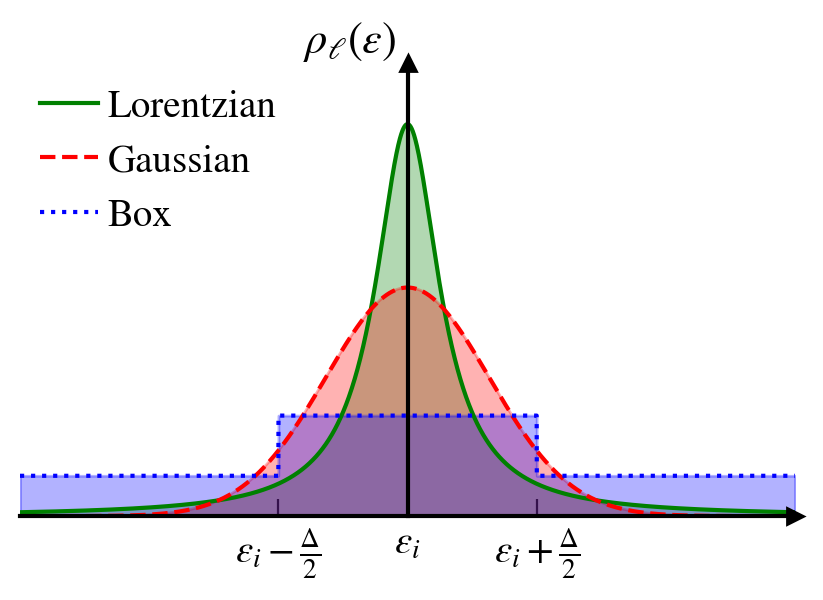

In [654]:
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)

Gamma = 0.03
sigma = 0.002
x0 = 0.0

x = np.linspace(-1, 1, 10000)
# x = np.linspace(-0.3, 0.3, 10000)
curve1 = 1 / np.pi * Gamma / ((x-x0)**2 + Gamma**2)
curve1 = curve1 / np.trapz(curve1, x)
axis.plot(x, curve1, color='green', label=r"Lorentzian")
axis.fill_between(x, 0, curve1, color='green', alpha=0.3)

x0 = -0.0
curve2 = 1 / np.sqrt(2*np.pi*sigma**2) * np.exp(-(x-x0)**2 / (2*sigma*2))
curve2 = curve2 / np.trapz(curve2, x)
axis.plot(x, curve2, color='red', ls='--', label=r"Gaussian")
axis.fill_between(x, 0, curve2, color='red', alpha=0.3)

x = np.linspace(-0.3, 0.3, 10000)
Gamma = 0.1
sig2 = 0.67
curve3 = (np.heaviside(Gamma - x,0) + np.heaviside(Gamma + x,0)) - 1 + sig2
curve3 = curve3 / np.trapz(curve3, x)
axis.plot(x, curve3, color='blue', ls=':', label=r"Box")
axis.fill_between(x, 0, curve3, color='blue', alpha=0.3)

fig_help.set_plot_elements(axis, ylabel=r"", xlabel=r"", font_size=14, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_legend(axis, loc='upper left', fontsize=14)
axis.set_ylim(1e-6, 12.5)
axis.set_ylabel(r'$\rho_\ell(\epsilon)$', loc='top', rotation=0)
# axis.set_ylabel(r'$\left|c_\alpha(\epsilon_i)\right|^2$', loc='top', rotation=0)
axis.xaxis.set_label_coords(1, 0.15)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['left'].set_position('zero')
axis.spines['bottom'].set_visible(True)
axis.xaxis.set_ticks_position('bottom')
axis.yaxis.set_ticks_position('left')
axis.set_xticks([-Gamma, 0, Gamma])
axis.set_xticklabels([r"$\epsilon_i-\frac{\Delta}{2}$", r"$\epsilon_i$", r"$\epsilon_i+\frac{\Delta}{2}$"])
axis.set_yticks([])
axis.spines['left'].set_linewidth(1.5)  # Thicker y-axis
axis.spines['bottom'].set_linewidth(1.5)  # Thicker x-axis

axis.set_xlim(-0.3, 0.3)
# axis.set_ylim(1e-1, 20)

# Add arrows at the ends of the axes
axis.plot(1, 0, ">k", transform=axis.get_yaxis_transform(), clip_on=False)  # Arrow for x-axis
axis.plot(0, 1, "^k", transform=axis.get_xaxis_transform(), clip_on=False)  # Arrow for y-axis
fig.savefig("figure.pdf", bbox_inches = 'tight', pad_inches=0.02)


In [550]:
alfac = 1/np.sqrt(2)
gammas = np.arange(1.2, 2.1, 0.1)
alfas = np.sqrt( np.exp( (gammas - 1) * np.log(alfac**2) ) )

print(gammas, alfas)

[1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ] [0.93303299 0.90125046 0.87055056 0.84089642 0.8122524  0.7845841
 0.75785828 0.73204285 0.70710678]


No handles with labels found to put in legend.


No handles with labels found to put in legend.
No handles with labels found to put in legend.


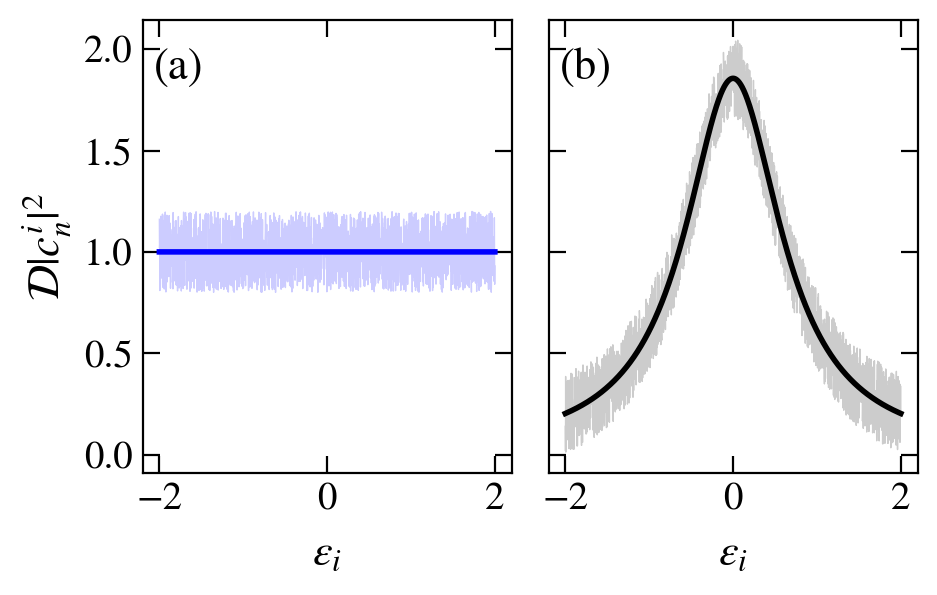

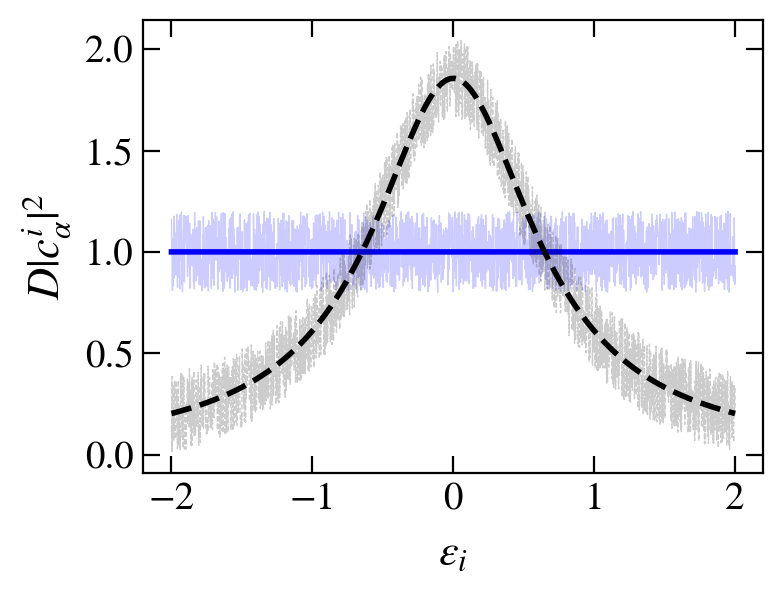

In [7]:
fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(5,3), dpi = 200, sharey = True)
fig2, ax = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharey = True)

Gamma = 0.7
sigma = 0.02
x0 = 0.
noise = 0.2

dim = 2**11

x = np.linspace(-2, 2, dim)

curve = np.ones(x.shape)
curve = curve / np.trapz(curve / (max(x) - min(x)), x)
axis[0].plot(x, curve, color='blue', ls='-', lw=2)
ax.plot(x, curve, color='blue', ls='-', lw=2)
fluct = curve + noise * (np.random.random(curve.size)-0.5)*2
# axis[0].scatter(x, fluct, s=1, color='blue', alpha=0.1)
axis[0].plot(x, fluct, lw=0.5, color='blue', alpha=0.2)
ax.plot(x, fluct, lw=0.5, color='blue', alpha=0.2)


curve = 1 / np.pi * Gamma / ((x-x0)**2 + Gamma**2)
curve = curve / np.trapz(curve * np.exp(-x**2 / 2) / np.sqrt(2*np.pi), x)
axis[1].plot(x, curve, color='k', lw=2)
ax.plot(x, curve, color='k', lw=2, ls='--')
fluct = curve + noise * (np.random.random(curve.size)-0.5)*2
# axis[1].scatter(x, fluct, s=1, color='k', alpha=0.1)
axis[1].plot(x, fluct, lw=0.5, color='k', alpha=0.2)
ax.plot(x, fluct, lw=0.5, color='k', ls='--', alpha=0.2)

fig_help.set_plot_elements(axis[0], ylabel=r"$\mathcal{D}|c_n^i|^2$", xlabel=r"$\epsilon_i$", font_size=14, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_plot_elements(axis[1], ylabel=r"", xlabel=r"$\epsilon_i$", font_size=14, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_plot_elements(ax, ylabel=r"$D|c_\alpha^i|^2$", xlabel=r"$\epsilon_i$", font_size=14, set_legend=1, xscale='linear', yscale='linear')

# axis.set_xlim(-0.3, 0.3)
# axis[0].set_ylim(0, 2)

fig.subplots_adjust(wspace = 0.1, hspace=0.05)
axis[0].annotate(r"(a)", fontsize=16, xy=(0.03, 0.87), xycoords='axes fraction')
axis[1].annotate(r"(b)", fontsize=16, xy=(0.03, 0.87), xycoords='axes fraction')

fig.savefig("PLOTS_FADING/BEYOND_RMT/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)


No handles with labels found to put in legend.


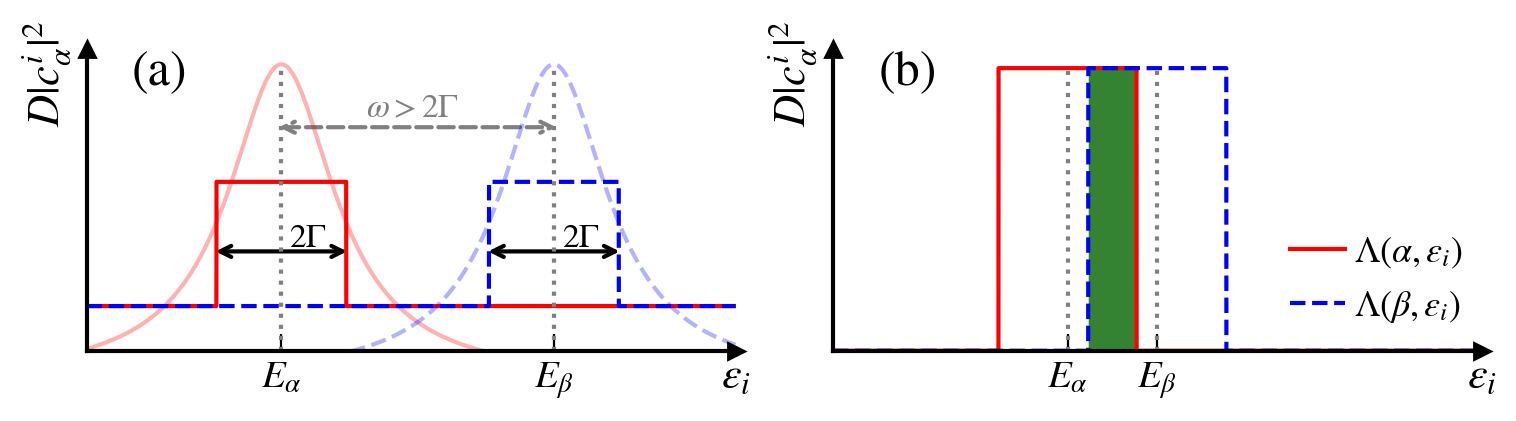

In [16]:
# fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,5), dpi = 200, sharex=False)
fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(9,2), dpi = 200, sharex=False)


x = np.linspace(-0.3, 0.2, 10000)
Gamma = 0.05
sigma = 1
x1 = -0.15
x2 = 0.06

sig2 = 0.6
curve1 = (np.heaviside(Gamma - (x-x1),0) + np.heaviside(Gamma + (x-x1),0)) - 1 + sig2
curve1_lor = 1 / np.pi * Gamma / ((x-x1)**2 + Gamma**2)

axis[0].plot(x, curve1_lor, color='red', alpha=0.3);    curve1 = curve1 / np.trapz(curve1, x)
axis[0].plot(x, curve1, color='red')

curve2 = (np.heaviside(Gamma - (x-x2),0) + np.heaviside(Gamma + (x-x2),0)) - 1 + sig2
curve2_lor = 1 / np.pi * Gamma / ((x-x2)**2 + Gamma**2)

axis[0].plot(x, curve2_lor, color='blue', ls='--', alpha=0.3);    curve2 = curve2 / np.trapz(curve2, x)
axis[0].plot(x, curve2, color='blue', ls='--')

# ADD ARROWS FOR WIDTH OF BOX
shift = sig2 + 0.7
shift = sig2 + 2.
arrow = FancyArrowPatch((x1-Gamma*1.1, shift), (x1+Gamma*1.1, shift),
    arrowstyle='<->', mutation_scale=10, color='black',linewidth=1.5
)
axis[0].add_patch(arrow)
arrow = FancyArrowPatch((x2-Gamma*1.1, shift), (x2+Gamma*1.1, shift),
    arrowstyle='<->', mutation_scale=10, color='black',linewidth=1.5
)
axis[0].add_patch(arrow)
axis[0].annotate(r"$2\Gamma$", fontsize=12, xy=(x1+Gamma/8, shift + 0.1))
axis[0].annotate(r"$2\Gamma$", fontsize=12, xy=(x2+Gamma/8, shift + 0.1))

# ADD ARROWS FOR OMEGA
shift = sig2 + 0.2
shift = sig2 + 4.5
arrow = FancyArrowPatch((x1-0.006, shift), (x2+0.006, shift),
    arrowstyle='<->', mutation_scale=10, color='gray',linewidth=1.5, ls='--'
)
axis[0].add_patch(arrow)
axis[0].axvline(x=x1, ymax=0.95, ls=':', color='gray')
axis[0].axvline(x=x2, ymax=0.95, ls=':', color='gray')
axis[0].annotate(r"$\omega>2\Gamma$", fontsize=12, xy=((x1+x2)/2-0.04, shift + 0.2), color='gray')

fig_help.set_plot_elements(axis[0], ylabel=r"$D|c_\alpha^i|^2$", xlabel=r"$\epsilon_i$", font_size=14, set_legend=1, xscale='linear', yscale='linear')
axis[0].set_xticks([x1, x2])
axis[0].set_xticklabels([r"$E_\alpha$", r"$E_\beta$"])
axis[0].set_yticks([])
axis[0].set_xlim(min(x), max(x))
axis[0].set_ylim(sig2, None)
axis[0].plot(1, sig2, ">k", transform=axis[0].get_yaxis_transform(), clip_on=False)  # Arrow for x-axis
axis[0].plot(min(x), 1, "^k", transform=axis[0].get_xaxis_transform(), clip_on=False)  # Arrow for y-axis
axis[0].spines['left'].set_linewidth(1.5)  # Thicker y-axis
axis[0].spines['bottom'].set_linewidth(1.5)
axis[0].spines['top'].set_visible(False)
axis[0].spines['right'].set_visible(False)
axis[0].xaxis.set_ticks_position('bottom')
axis[0].yaxis.set_ticks_position('left')
axis[0].yaxis.set_label_coords(-0.02,0.92)
axis[0].xaxis.set_label_coords(1, -0.02)

x = np.linspace(-0.2, 0.27, 10000)
x1 = -0.03
x2 = 0.035
sig2 = 0.37
curve1 = (np.heaviside(Gamma - (x-x1),0) + np.heaviside(Gamma + (x-x1),0)) - 1 + sig2
# curve1 = curve1 / np.trapz(curve1, x)

curve2 = (np.heaviside(Gamma - (x-x2),0) + np.heaviside(Gamma + (x-x2),0)) - 1 + sig2
# curve2 = curve2 / np.trapz(curve2, x)
axis[1].plot(x, curve1, color='red',  label=r"$\Lambda(\alpha,\epsilon_i)$")
axis[1].plot(x, curve2, color='blue', label=r"$\Lambda(\beta,\epsilon_i)$",ls='--')
# axis[1].fill_between(x, curve1, curve2, color='green', lw=0, alpha=0.4)
curve_overlap = curve2 = (np.heaviside(Gamma + (x-x2),0) + np.heaviside(Gamma - (x-x1),0)) - 1 + sig2
axis[1].fill_between(x, 0, curve_overlap, color='darkgreen', lw=0, alpha=0.8)

# print(sig2, curve1[-1], curve2[-1], max(curve1))

fig_help.set_plot_elements(axis[1], ylabel=r"$D|c_\alpha^i|^2$", xlabel=r"$\epsilon_i$", font_size=14, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_legend(axis[1], loc='lower right', fontsize=13)
axis[1].set_xlim(min(x), max(x))
axis[1].set_ylim(sig2, None)

axis[1].set_yticks([])
axis[1].set_xticks([x1, x2])
axis[1].set_xticklabels([r"$E_\alpha$", r"$E_\beta$"])

axis[1].plot(1, sig2, ">k", transform=axis[1].get_yaxis_transform(), clip_on=False)  # Arrow for x-axis
axis[1].plot(min(x), 1, "^k", transform=axis[1].get_xaxis_transform(), clip_on=False)  # Arrow for y-axis
axis[1].spines['left'].set_linewidth(1.5)  # Thicker y-axis
axis[1].spines['bottom'].set_linewidth(1.5) 
axis[1].spines['top'].set_visible(False)
axis[1].spines['right'].set_visible(False)
axis[1].xaxis.set_ticks_position('bottom')
axis[1].yaxis.set_ticks_position('left')

axis[1].yaxis.set_label_coords(-0.02,0.92)
axis[1].xaxis.set_label_coords(1, -0.02)

axis[1].axvline(x=x1, ymax=0.93, ls=':', color='gray')
axis[1].axvline(x=x2, ymax=0.93, ls=':', color='gray')

axis[0].annotate(r"(a)", fontsize=18, xy=(0.07, 0.88), xycoords='axes fraction')
axis[1].annotate(r"(b)", fontsize=18, xy=(0.07, 0.88), xycoords='axes fraction')
fig.subplots_adjust(wspace = 0.15, hspace=0.15)
# fig.savefig("PLOTS_FADING/BEYOND_RMT/FigS1.pdf", bbox_inches = 'tight', pad_inches=0.02)

## COMPARING UM AND RP

No handles with labels found to put in legend.


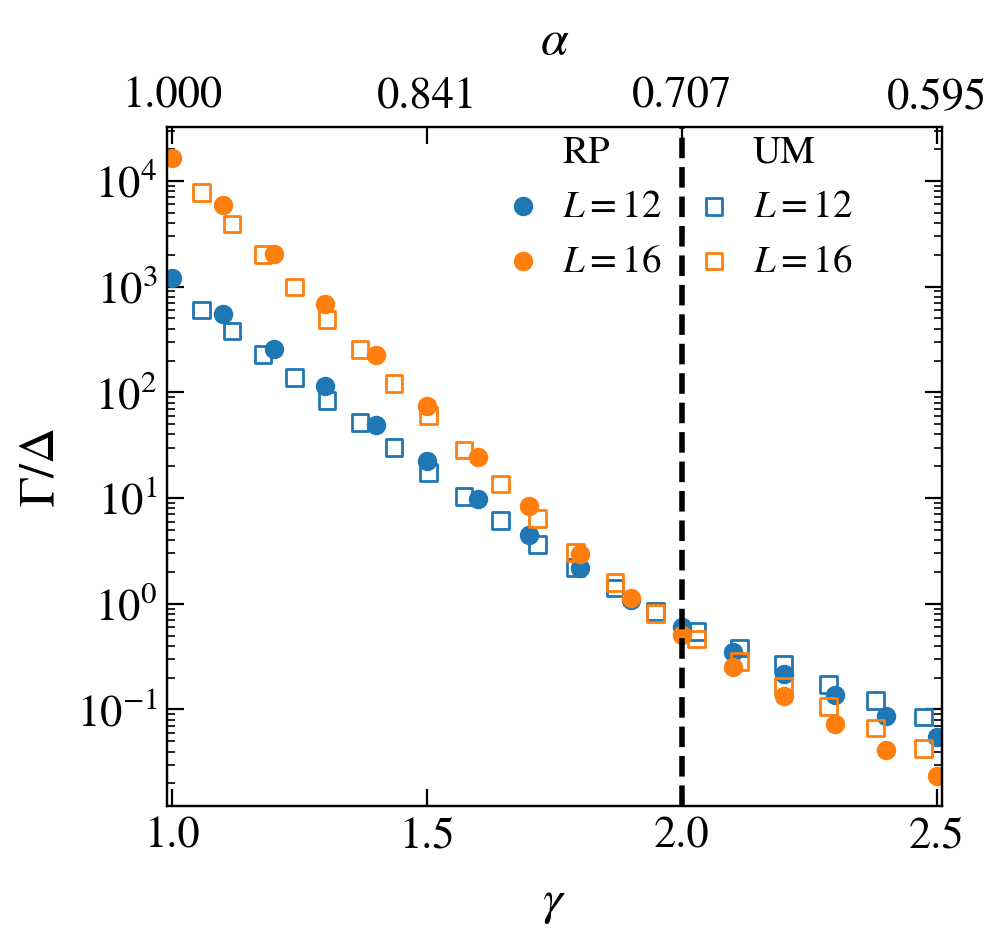

In [1436]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(9, 17, 1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4.5), dpi = 200, sharex=False, sharey=False)

# fig = plt.figure(figsize=(5,6), dpi = 300)
# gs = GridSpec(nrows=2, ncols=2, height_ratios=[2, 3])
# axis = fig.add_subplot(gs[1, :])
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
gx = 1.5
window = 100

L = 15
eps = 0.5
alfac = 1/np.sqrt(2)

dim = 2**L

gammas = np.arange(1.0, 2.6, 0.1)

ymin = 1e6
axis2 = axis.twiny()

handles = []
for L in [12, 16]:
    dim = 2**L
    col = next(colors_ls_cyc)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    E_th = np.zeros(gammas.shape)
    for iig, gx in enumerate(gammas):
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

        if exists(name):
            with h5py.File(name, "r") as file:
                wH = np.array(file.get('wH'))[-1]
                # dE  = np.sqrt(1 + dim**(1-gx))#np.mean( np.array(file.get('bandwidth')) )
                # tH = 2 * np.pi / wH
                # wH = 2 * np.pi / ( dim / (np.sqrt(1 + dim**(1-gx))) * 2 )
                # wH = dE / dim / 2 * np.pi
                
                sigma = np.mean( np.array(file.get('bandwidth')) )
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                omegax = np.array(file.get('omegas'))
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                        
                yy0 = spec_fun * 2**L
                
                omegax = omegax[~np.isnan(yy0)]
                spec_fun = spec_fun[~np.isnan(yy0)]
                spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                
                # xx = omegax#[indices]
                # yy = yy0#[indices]
                # pars, pconv= fit(lorenz,
                #             xdata = omegax,
                #             ydata = yy0,
                #             maxfev = 20000)
                # G = np.abs(pars[-1])
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                G = xx[1:][idxG]
                
                E_th[iig] = G / wH * np.sqrt(1 + dim**(1-gx))
        else:
            print(name)
    line = axis.scatter(gammas, E_th, color = col, label=r"$L=%d$"%L)
    handles.append(line)
    # ------------------------------------------------------------ ULTRAMETRIC MODEL
    bandwidth_ = np.transpose(np.array([[14.15529694,14.18783681,13.79809073,14.70243885,14.15699668,14.09174666,13.97159135,14.54182027,14.56108004,14.94075512,14.72489892,14.26014434,15.08897824,15.21879211,15.08696013,14.82103569,15.16009597,15.44983645,15.46168321,16.42984215]]))
    name_out = "./UM results/SpectralFun/Ns=%d.h5"%(L)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            alfas = np.array(file.get('Sz/0/alphas/mean'))
            # indices = np.argwhere( np.logical_and(alfas >= 0.591, alfas < 1) )
            # alfas = alfas[indices]
            
            _alfas_ = []
            _gammas_ = []
            E_th2 = []
            iicons = 0
            for iia, alfa in enumerate(alfas):
                if alfa >= 0.591 and alfa < 1:
                    idxa = np.argmin( np.abs(alfas - alfa) )
                    omegas      = np.array(file.get('Sz/0/omegas/mean/%.3f'%(alfa) ))
                    spec_fun    = np.array(file.get('Sz/0/f_fun/mean/%.3f'%(alfa) ))
                    
                    name_out2 = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
                    if exists(name_out2):
                        with h5py.File(name_out2, "r") as fileee:
                            alfasdasdas = np.array(fileee.get('alphas'))
                            idxa2 = np.argmin( np.abs(alfasdasdas - alfa) )
                            wH = np.array(fileee.get('mean_lvl/1.00/mean'))[idxa2]
                            dE = np.array(fileee.get('bandwidth/mean'))[idxa2]
                            dE = np.array(fileee.get('variance/1.00/mean'))[idxa2]
                            # wH = dE / dim
                            # print(L, alfa, sig)
                    else:
                        print(name_out2)
                         
                    # wH = np.array(file.get('Sz/0/heisenberg/mean'))[idxa]
                    xx = omegas
                    yy = integrate.cumulative_trapezoid(spec_fun, omegas)
                    yy = (yy - yy[0]) / (yy[-1] - yy[0])
                    idxG = np.argmin( np.abs(yy - 0.5) )
                    E_th2.append( omegas[1:][idxG] / wH * dE)
                    _gammas_.append(1 + np.log(alfa**2) / np.log(alfac**2))
                    _alfas_.append(alfa)
                    
                
            # E_th2 = np.array(file.get('Sz/0/gamma/mean'))[indices]# / dim**(1 - _gammas_)
            line = axis.scatter(_gammas_, E_th2, color=col, facecolor='None', marker='s', label=r"$L=%d$"%L)
            handles.append(line)
    else:
        print(name_out)
        
    _alfas_ = np.array(_alfas_) 
    # axis.plot(gammas, dim**(1-gammas) )
axis.set_xlim(0.99, 2.51)
# axis.set_ylim(1e-3, 3e4)

line, = axis.plot(np.nan, np.nan, color='k', ls=':', lw=0,label = r"UM")
handles.append(line)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RP")
handles.append(line)
indices = np.array([5,0,2, 4,1,3])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )
axis.axvline(x=2, ls='--', color='k', lw=2)
fig_help.set_plot_elements(axis, ylabel=r"$\Gamma/\Delta$", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis2, ylabel=r"", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis.tick_params(axis='both', which='major', direction="in",length=6, labelsize=16, bottom=True, top=False, left=True, right=True)
axis2.tick_params(axis='both', which='major', direction="in", length=6, labelsize=16, bottom=False, top=True, left=True, right=True)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')

fig_help.set_legend(axis, fontsize=14, loc='upper right', anchor=(0.93, 1.04), ncol = 2, handles = _handle_shit, columnspacing=0.6)

ax1Ticks = axis.get_xticks()   
ax2Ticks = ax1Ticks

def tick_function(X):
    V = np.sqrt( np.exp( (X - 1) * np.log(alfac**2) ) )
    return ["%.3f" % z for z in V]

axis2.set_xticks(ax2Ticks)
axis2.set_xbound(axis.get_xbound())
axis2.set_xticklabels(tick_function(ax2Ticks))

fig.subplots_adjust(wspace = 0.1, hspace=0.34)


No handles with labels found to put in legend.


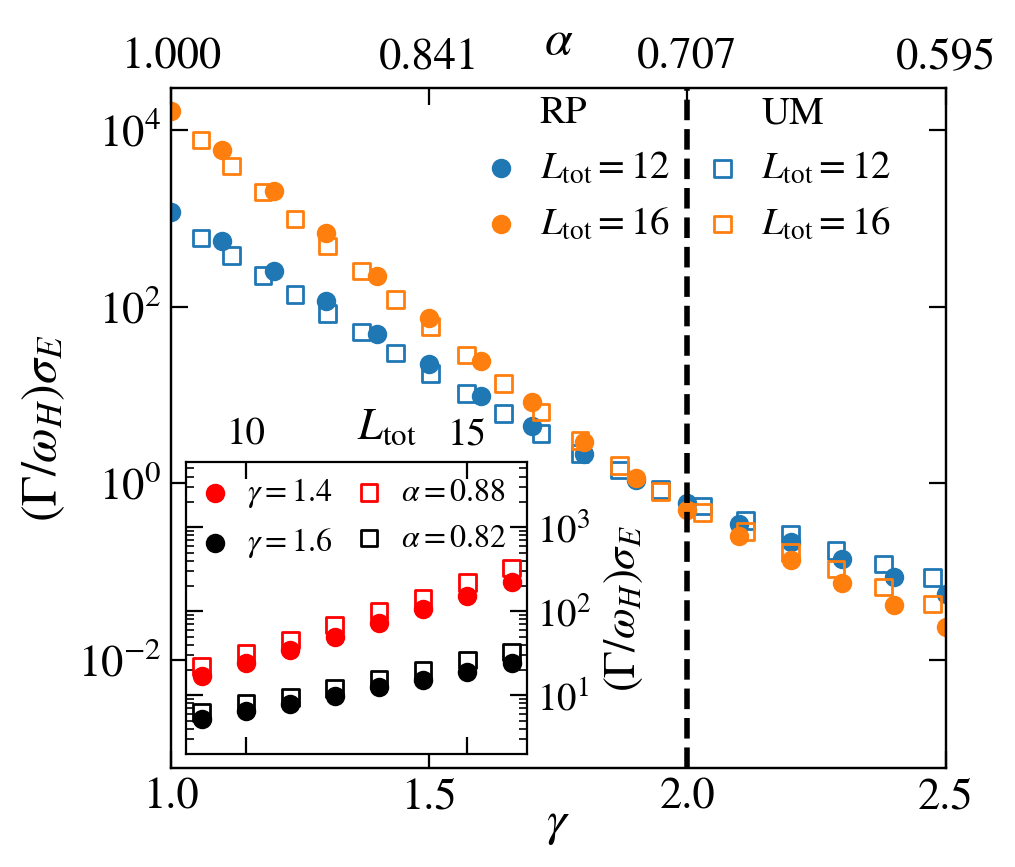

In [2]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(9, 17, 1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4.5), dpi = 200, sharex=False, sharey=False)
inset = axis.inset_axes([0.02, 0.02, 0.44, 0.43])
# fig = plt.figure(figsize=(5,6), dpi = 300)
# gs = GridSpec(nrows=2, ncols=2, height_ratios=[2, 3])
# axis = fig.add_subplot(gs[1, :])
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
gx = 1.5
window = 100

L = 15
eps = 0.5
alfac = 1/np.sqrt(2)

dim = 2**L

gammas = np.arange(1.0, 2.6, 0.1)

ymin = 1e6
axis2 = axis.twiny()

handles = []
for L in [12, 16]:
    dim = 2**L
    col = next(colors_ls_cyc)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    E_th = np.zeros(gammas.shape)
    for iig, gx in enumerate(gammas):
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

        if exists(name):
            with h5py.File(name, "r") as file:
                wH = np.array(file.get('wH'))[-1]
                dE  = np.mean(np.array(file.get('stddev')))#np.sqrt(1 + dim**(1-gx))#np.mean( np.array(file.get('bandwidth')) )
                # tH = 2 * np.pi / wH
                # wH = 2 * np.pi / ( dim / (np.sqrt(1 + dim**(1-gx))) * 2 )
                # wH = dE / dim / 2 * np.pi
                
                dE  = np.mean(np.array(file.get('bandwidth')))
                sig  = np.mean(np.array(file.get('stddev')))
                
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                omegax = np.array(file.get('omegas'))
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                        
                yy0 = spec_fun * 2**L
                
                omegax = omegax[~np.isnan(yy0)]
                spec_fun = spec_fun[~np.isnan(yy0)]
                spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                
                # xx = omegax#[indices]
                # yy = yy0#[indices]
                # pars, pconv= fit(lorenz,
                #             xdata = omegax,
                #             ydata = yy0,
                #             maxfev = 20000)
                # G = np.abs(pars[-1])
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                G = xx[1:][idxG]
                
                # E_th[iig] = G / wH /dE
                E_th[iig] = G / wH * sig
                # E_th[iig] = G / wH
        else:
            print(name)
    line = axis.scatter(gammas, E_th, color = col, label=r"$L_\mathrm{tot}=%d$"%L)
    handles.append(line)
    # ------------------------------------------------------------ ULTRAMETRIC MODEL
    bandwidth_ = np.transpose(np.array([[14.15529694,14.18783681,13.79809073,14.70243885,14.15699668,14.09174666,13.97159135,14.54182027,14.56108004,14.94075512,14.72489892,14.26014434,15.08897824,15.21879211,15.08696013,14.82103569,15.16009597,15.44983645,15.46168321,16.42984215]]))
    name_out = "./UM results/SpectralFun/Ns=%d.h5"%(L)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            alfas = np.array(file.get('Sz/0/alphas/mean'))
            # indices = np.argwhere( np.logical_and(alfas >= 0.591, alfas < 1) )
            # alfas = alfas[indices]
            
            _alfas_ = []
            _gammas_ = []
            E_th2 = []
            iicons = 0
            for iia, alfa in enumerate(alfas):
                if alfa >= 0.591 and alfa < 1:
                    idxa = np.argmin( np.abs(alfas - alfa) )
                    omegas      = np.array(file.get('Sz/0/omegas/mean/%.3f'%(alfa) ))
                    spec_fun    = np.array(file.get('Sz/0/f_fun/mean/%.3f'%(alfa) ))
                    
                    name_out2 = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
                    if exists(name_out2):
                        with h5py.File(name_out2, "r") as fileee:
                            alfasdasdas = np.array(fileee.get('alphas'))
                            idxa2 = np.argmin( np.abs(alfasdasdas - alfa) )
                            wH = np.array(fileee.get('mean_lvl/1.00/mean'))[idxa2]
                            dE = np.array(fileee.get('bandwidth/mean'))[idxa2]
                            sig = np.array(fileee.get('variance/1.00/mean'))[idxa2]
                            # wH = dE / dim
                            # print(L, alfa, sig)
                    else:
                        print(name_out2)
                         
                    # wH = np.array(file.get('Sz/0/heisenberg/mean'))[idxa]
                    xx = omegas
                    yy = integrate.cumulative_trapezoid(spec_fun, omegas)
                    yy = (yy - yy[0]) / (yy[-1] - yy[0])
                    idxG = np.argmin( np.abs(yy - 0.5) )
                    E_th2.append( omegas[1:][idxG] / wH * sig)
                    # E_th2.append( omegas[1:][idxG] / wH)
                    # E_th2.append( omegas[1:][idxG] / dE * sig)
                    
                    _gammas_.append(1 + np.log(alfa**2) / np.log(alfac**2))
                    _alfas_.append(alfa)
                    
                
            # E_th2 = np.array(file.get('Sz/0/gamma/mean'))[indices]# / dim**(1 - _gammas_)
            line = axis.scatter(_gammas_, E_th2, color=col, facecolor='None', marker='s', label=r"$L_\mathrm{tot}=%d$"%L)
            handles.append(line)
    else:
        print(name_out)
        
    _alfas_ = np.array(_alfas_) 
    # axis.plot(gammas, dim**(1-gammas) )
axis.set_xlim(1, 2.5)
axis.set_ylim(6e-4, 3e4)

line, = axis.plot(np.nan, np.nan, color='k', ls=':', lw=0,label = r"UM")
handles.append(line)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RP")
handles.append(line)
indices = np.array([5,0,2, 4,1,3])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )
axis.axvline(x=2, ls='--', color='k', lw=2)
fig_help.set_plot_elements(axis, ylabel=r"$(\Gamma/\omega_H)\sigma_E$", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis2, ylabel=r"", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis.tick_params(axis='both', which='major', direction="in",length=6, labelsize=16, bottom=True, top=False, left=True, right=True)
axis2.tick_params(axis='both', which='major', direction="in", length=6, labelsize=16, bottom=False, top=True, left=True, right=True)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')

fig_help.set_legend(axis, fontsize=14, loc='upper right', anchor=(0.975, 1.04), ncol = 2, handles = _handle_shit, columnspacing=0.6)

ax1Ticks = axis.get_xticks()   
ax2Ticks = ax1Ticks

def tick_function(X):
    V = np.sqrt( np.exp( (X - 1) * np.log(alfac**2) ) )
    return ["%.3f" % z for z in V]

axis2.set_xticks(ax2Ticks)
axis2.set_xbound(axis.get_xbound())
axis2.set_xticklabels(tick_function(ax2Ticks))

# axis.set_ylim(2e-3, 1)

s_m_g = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(vmin=min(gammas), vmax=max(gammas)))
s_m_g.set_array([])

s_m_a = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=matplotlib.colors.Normalize(vmin=min(_alfas_), vmax=max(_alfas_)))
s_m_a.set_array([])

gammas = [1.4, 1.6]
handles = []
for iig, gx in enumerate(gammas):
    alfa = np.sqrt( np.exp( (gx - 1) * np.log(alfac**2) ) )
    
    E_th_RP = np.zeros(sizes.shape)
    E_th_UM = np.zeros(sizes.shape)
    for iiL, L in enumerate(sizes):
        dim = 2**L
        # ------------------------------------------------------------ ROZENZWEIG-PORTER
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                wH        = np.array(file.get('wH'))[-1]
                # wH = 2 * np.pi / ( dim / (np.sqrt(1 + dim**(1-gx))) * 2 )
                
                tH        = 2 * np.pi / wH
                dE  = np.mean(np.array(file.get('bandwidth')))
                sig  = np.sqrt(1 + dim**(1-gx))#np.mean(np.array(file.get('stddev')))# np.sqrt(1 + dim**(1-gx))#np.mean( np.array(file.get('bandwidth')) )
                # wH = dE / dim
                
                omegax = np.array(file.get('omegas'))# / wH
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                        
                yy0 = spec_fun * 2**L
                
                omegax = omegax[~np.isnan(yy0)]
                spec_fun = spec_fun[~np.isnan(yy0)]
                spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                
                # E_th_RP[iiL] = xx[1:][idxG] / wH
                E_th_RP[iiL] = xx[1:][idxG] / wH * sig
                # E_th_RP[iiL] = xx[1:][idxG] / dE * sig
        # ------------------------------------------------------------ ULTRAMETRIC MODEL
        name_out = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('alphas'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                wH = np.array(file.get('mean_lvl/1.00/mean'))[idxa]
                dE = np.array(file.get('bandwidth/mean'))[idxa]
                sig = alfa / (1-alfa**2) #np.array(file.get('variance/1.00/mean'))[idxa]
                # print(L, alfa, sig)
        else:
            print(name_out)
            
        name_out = "./UM results/SpectralFun/Ns=%d.h5"%(L)
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('Sz/0/alphas/mean'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                if np.abs(alfa - _alfas_[idxa]) > 1e-2:
                    print(alfa, name_out)
                    continue
                alfax = _alfas_[idxa]
                E_th        = np.array(file.get('Sz/0/gamma/mean'))
                # wH        = np.array(file.get('Sz/0/heisenberg/mean'))[idxa]
                # tH        = 2 * np.pi / wH
                # idxa = np.argmin( np.abs(E_th - G) )
                # print(alfa, _alfas_[idxa])
                E_th = E_th[idxa]
                omegas      = np.array(file.get('Sz/0/omegas/mean/%.3f'%(_alfas_[idxa]) ))[:-5]
                spec_fun    = np.array(file.get('Sz/0/f_fun/mean/%.3f'%(_alfas_[idxa]) ))[:-5]
                xx = omegas
                yy = integrate.cumulative_trapezoid(spec_fun, omegas)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                # E_th_UM[iiL] = omegas[1:][idxG] / wH
                E_th_UM[iiL] = omegas[1:][idxG] / wH * sig
                # E_th_UM[iiL] = omegas[1:][idxG] / dE * sig
        else:
            print(name_out)
    col = 'k' if iig else 'red'
    line = inset.scatter(sizes, E_th_RP, color=col, label=r"$\gamma=%g$"%gx)
    handles.append(line)
    
    line = inset.scatter(sizes, E_th_UM, marker='s', color=col, facecolor='None', label=r"$\alpha=%g$"%alfax)
    handles.append(line)


# line, = axis.plot(np.nan, np.nan, color='k', ls=':', lw=0,label = r"UM")
# handles.append(line)
# line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RP")
# handles.append(line)
indices = np.array([0,2, 1,3])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )  
inset.xaxis.set_label_coords(0.59, 1.08)

axis.xaxis.set_label_coords(.5, -0.05)
axis2.xaxis.set_label_coords(.5, 1.05)
inset.xaxis.set_ticks_position('top')
inset.xaxis.set_label_position('top')
inset.yaxis.set_ticks_position('right')
inset.yaxis.set_label_position('right')

inset.set_ylim(2e0, 6e3)
fig_help.set_plot_elements(inset, ylabel=r"$(\Gamma/\omega_H)\sigma_E$", xlabel=r"$L_\mathrm{tot}$", font_size=14, set_legend=1, xscale='linear', yscale='log')
fig_help.set_legend(inset, fontsize=11.5, loc='upper left', anchor=(-0.07, 1.05), ncol = 2, handles = _handle_shit, columnspacing=0.4)
# inset.yaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: ""))
# inset.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: ""))

fig.subplots_adjust(wspace = 0.1, hspace=0.34)

fig.savefig("PLOTS_FADING/ANOMALOUS/Fig1.pdf", bbox_inches = 'tight', pad_inches=0.02)


1.0
1.2
1.4
1.5999999999999999
1.7999999999999998
1.9999999999999998


No handles with labels found to put in legend.


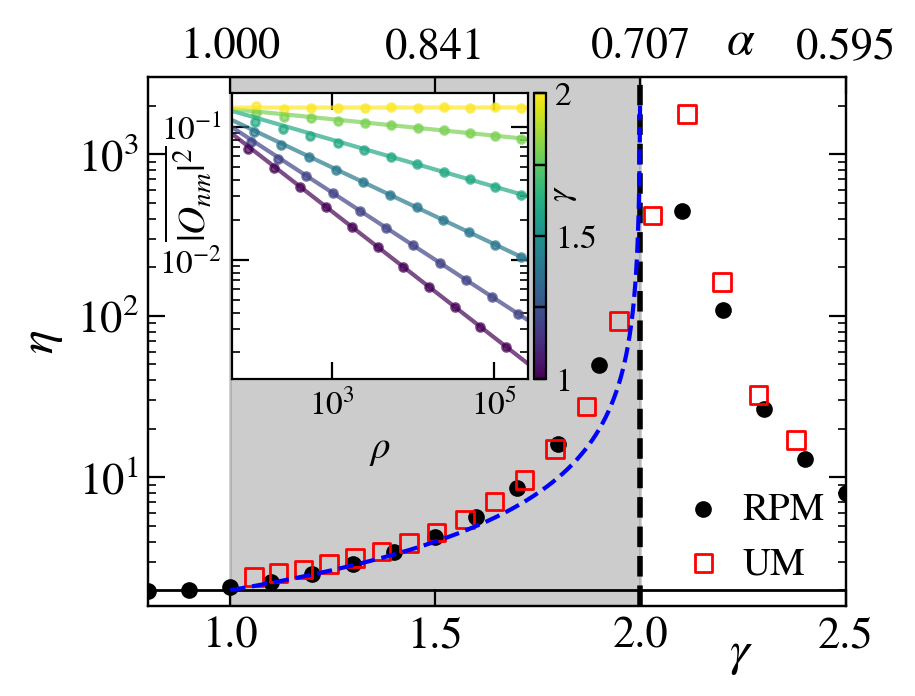

In [61]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(6, 17, 1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,3.5), dpi = 200, sharex=False, sharey=False)

inset = axis.inset_axes([0.12, 0.43, 0.45, 0.54])

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)


r_idx = 5
corr = 0
gx = 1.5
window = 100

L = 15
eps = 0.5
alfac = 1/np.sqrt(2)

dim = 2**L

gammas = np.arange(0.8, 2.51, 0.1)

norm = matplotlib.colors.Normalize(
        vmin=1,
        vmax=2)
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

ymin = 1e6
axis2 = axis.twiny()

# ------------------------------------------------------------ ROZENZWEIG-PORTER
def matelem_fit(DOS, a0, eta):
    return a0 * DOS**(-eta)

etaRP = np.zeros(gammas.shape)
for iig, gx in enumerate(gammas):
    colo = s_m.to_rgba(gx)
    DOS = np.zeros(sizes.shape)
    spec_at_wH_G = np.zeros(sizes.shape)
    for iiL, L in enumerate( sizes ):
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

        if exists(name):
            with h5py.File(name, "r") as file:
                sigma = np.mean( np.array(file.get('bandwidth')) )
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                omegax = np.array(file.get('omegas'))
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                    
                _DOS = np.array(file.get('DOS'))[idx]
                DOS[iiL] = _DOS
                wHx = np.array(file.get('wH_density'))[idx]
                yy0 = spec_fun
                
                omegax = omegax[~np.isnan(yy0)]
                spec_fun = spec_fun[~np.isnan(yy0)]
                spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                G = xx[1:][idxG]
                
                idx_spec = min(range(len(omegax)), key=lambda i: abs(omegax[i] - np.sqrt(wHx * G)))
                
                spec_at_wH_G[iiL] = np.sqrt( np.mean(yy0[ max(0, idx_spec - 20) : min(idx_spec + 20, yy0.size)]) )
        else:
            print(name)
    DOS = DOS[~np.isnan(spec_at_wH_G)]
    sizes = sizes[~np.isnan(spec_at_wH_G)]
    spec_at_wH_G = spec_at_wH_G[~np.isnan(spec_at_wH_G)]

    pars, pconv= fit(matelem_fit,
                xdata = DOS[-6:],
                ydata = spec_at_wH_G[-6:],
                maxfev = 20000)
    etaRP[iig] = 1 / np.abs(pars[-1])
    
    if gx >= 1 and gx < 2 and int(10 * np.round(gx, 2))%2==0:
        print(gx)
        inset.scatter(DOS, spec_at_wH_G, color=colo, s=8, alpha=0.7)
    
        zz = np.linspace(min(DOS)/2, max(DOS)*2, 1000)
        inset.plot(zz, matelem_fit(zz, *pars), color=colo, alpha=0.7)
    # a1 = -1 / ( (np.log(spec_at_wH_G[-1]) - np.log(spec_at_wH_G[-2])) / (np.log(DOS[-1]) - np.log(DOS[-2])) )
    # a2 = -1 / ( (np.log(spec_at_wH_G[-2]) - np.log(spec_at_wH_G[-3])) / (np.log(DOS[-2]) - np.log(DOS[-3])) )
    # etaRP[iig] = (a1 + a2)/2
axis.scatter(gammas, etaRP, label=r"RPM", zorder=0, color='k', s=25)

inset.set_xlim(0.5*min(DOS), 1.2 * max(DOS))
# ------------------------------------------------------------ ULTRAMETRIC MODEL
name_out = "./UM results/SpectralFun/etas.h5"
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        alfas = np.array(file.get('Sz/0/etas/mean'))[:, 0]
        _gammas_ = 1 + np.log(alfas**2) / np.log(alfac**2)
        
        etas = np.array(file.get('Sz/0/etas/mean'))[:, 1]
        indices = np.argwhere( np.logical_and(alfas >= 0.617, alfas < 1.1) )
        axis.scatter(_gammas_[indices], etas[indices], label=r"UM", marker = 's', zorder=1, color='red', facecolor='None', s=40)
        
else:
    print(name_out)
        

axis.axvline(x=2, ls='--', color='k', lw=2)
axis.axvspan(xmin=1, xmax=2, color='gray', alpha=0.4, zorder=-1)
axis.axhline(y=2, ls='-', color='k', lw=1)

z = np.linspace(1, 2, 1000)
axis.plot(z, 2 / np.abs(2 - z), ls='--', color='blue')#, label=r"$\eta_{\rm RPM}$")
# add 2/(2-g), feom g=1

cbar = None

divider = make_axes_locatable(inset)
cax = divider.new_horizontal(size = '4%', pad = 0.03)

fig.add_axes(cax)
cbar = fig.colorbar(s_m, cax = cax, orientation = 'vertical')
# cax.xaxis.set_ticks_position('top')
# cax.xaxis.set_label_position('top')
# cax.xaxis.set_label_coords(-0.06, 0.05)

cbar.set_label(r"$\gamma$", fontsize=12)
cax.tick_params(axis='both', which='major', direction="in",length=4, labelsize=12, bottom=True, top=True, left=True, right=True)
cax.yaxis.set_label_coords(1.3, 0.65)
cax.set_yticks([1, 1.25, 1.5, 1.75, 2])
cax.set_yticklabels(["1", "", "1.5", "", "2"])

inset.yaxis.set_label_coords(-0.06, 0.65)

fig_help.set_plot_elements(inset, ylabel=r"$\overline{|O_{nm}|^2}$", xlabel=r"$\rho$", font_size=12, set_legend=0, xscale='log', yscale='log')

fig_help.set_plot_elements(axis, ylabel=r"$\eta$", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_legend(axis, loc='lower right', fontsize=14)

fig_help.set_plot_elements(axis2, ylabel=r"", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis.tick_params(axis='both', which='major', direction="in",length=6, labelsize=16, bottom=True, top=False, left=True, right=True)
axis2.tick_params(axis='both', which='major', direction="in", length=6, labelsize=16, bottom=False, top=True, left=True, right=True)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')
axis.set_xlim(0.8, 2.5)
axis.set_ylim(1.6, 3e3)

ax1Ticks = axis.get_xticks()   
ax2Ticks = ax1Ticks

def tick_function(X):
    V = np.sqrt( np.exp( (X - 1) * np.log(alfac**2) ) )
    return ["%.3f" % z for z in V]

axis2.set_xticks(ax2Ticks)
axis2.set_xbound(axis.get_xbound())
axis2.set_xticklabels(tick_function(ax2Ticks))

# axis.set_ylim(2e-3, 1)

axis.xaxis.set_label_coords(.85, 1.11)
axis2.xaxis.set_label_coords(.85, -0.11)

fig.subplots_adjust(wspace = 0.2, hspace=0.2)

fig.savefig("PLOTS_FADING/ANOMALOUS/Fig_eta.pdf", bbox_inches = 'tight', pad_inches=0.02)

UM 1.148698354997035 0.8055535781950272
UM 1.109569472067845 0.8055535781950272
UM 1.0717734625362931 0.8055535781950272
UM 1.0352649238413776 0.8055535781950272
UM 1.0 0.8055535781950272
UM 0.9659363289248455 0.7939351272753046
UM 0.9330329915368074 0.8029991466394582
UM 0.9012504626108302 0.8300033259504368
RP 1.4 0.9595777876019228
UM 0.8705505632961241 0.8319763866665125
UM 0.8408964152537145 0.8200870084686191
RP 1.6 1.0039212769323045
UM 0.8122523963562355 0.8234769584715215
UM 0.7845840978967507 0.7660499550768929
UM 0.757858283255199 0.6881146844858789
UM 0.7320428479728127 0.5620649177231248


No handles with labels found to put in legend.
No handles with labels found to put in legend.


UM 0.7071067811865475 0.0009764520569553954


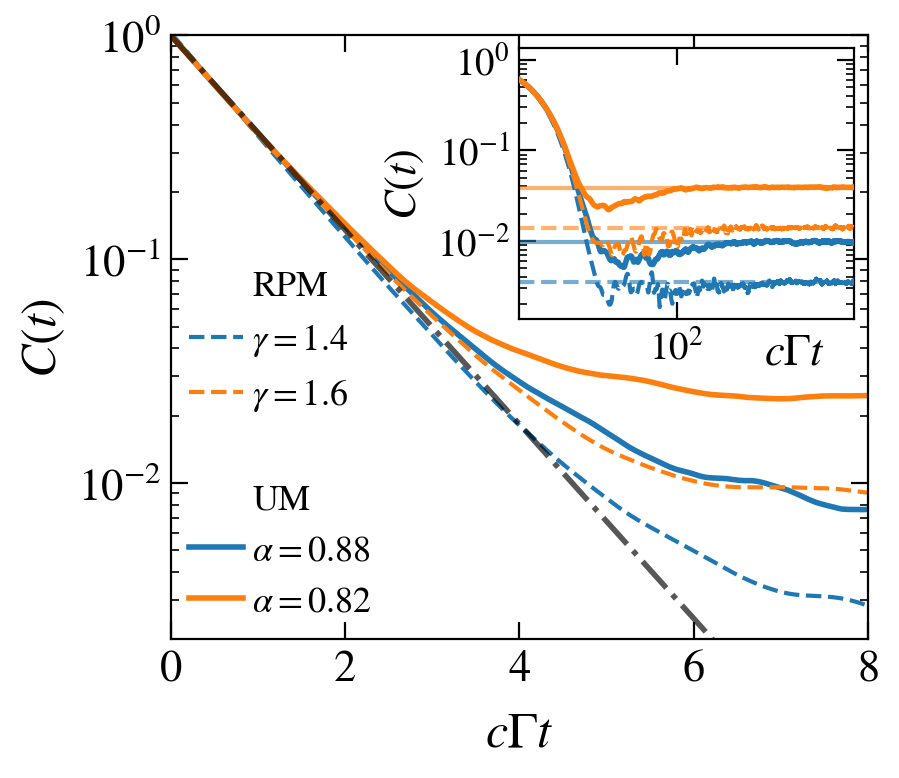

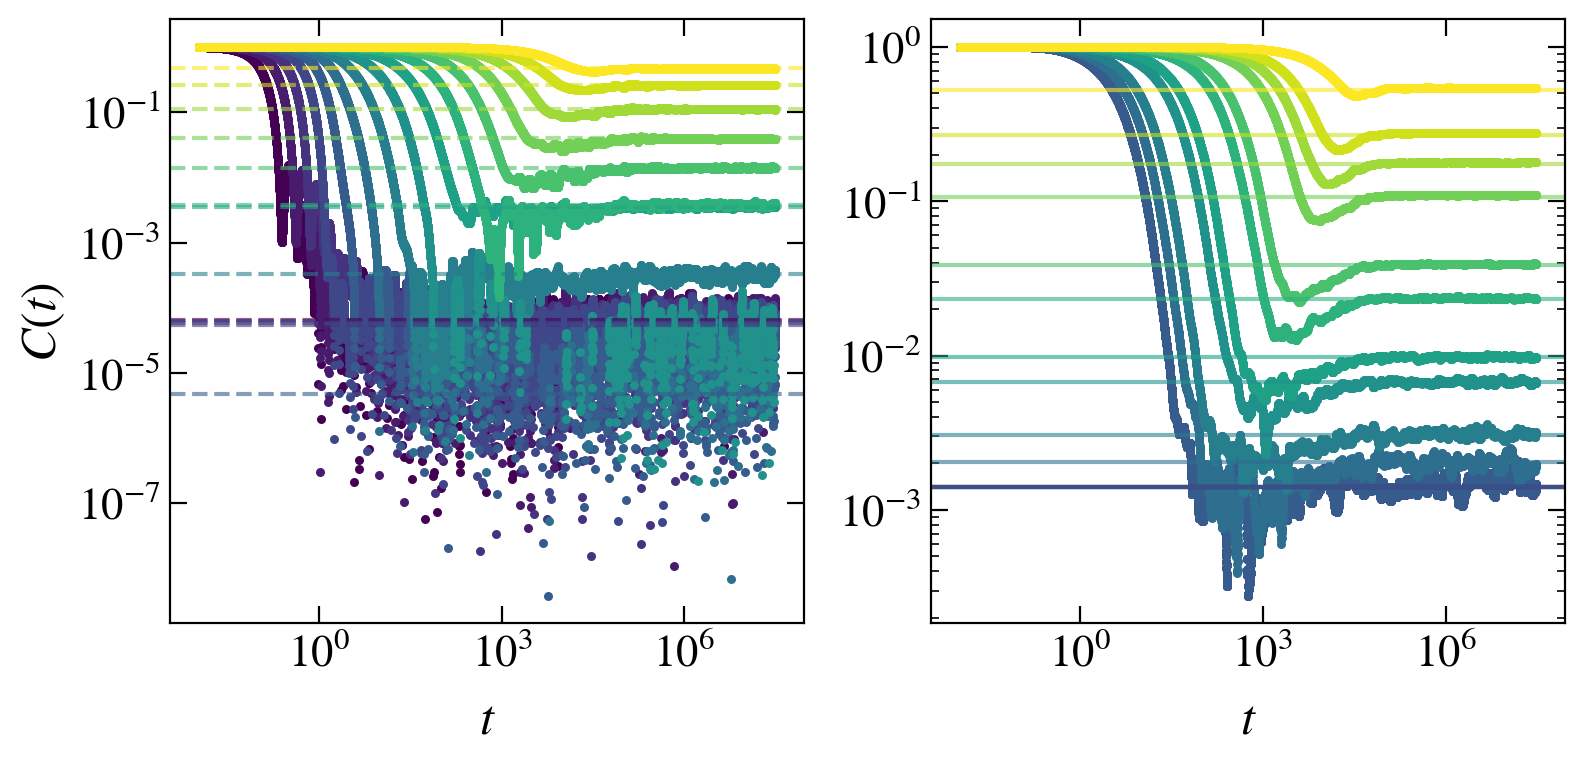

In [9]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(7, 17, 1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,4), dpi = 200, sharex=False, sharey=False)

fig_test, axis_test = plt.subplots( nrows=1, ncols=2, figsize=(9,4), dpi = 200, sharex=False, sharey=False)
# fig = plt.figure(figsize=(5,6), dpi = 300)
# gs = GridSpec(nrows=2, ncols=2, height_ratios=[2, 3])
# axis = fig.add_subplot(gs[1, :])
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])


# fig2, axis2 = plt.subplots( nrows=4, ncols=3, figsize=(12,15), dpi = 200, sharex=False, sharey=False)
# axis2 = axis2.flatten()
inset = axis.inset_axes([0.5, 0.53, 0.48, 0.45])

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)


r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5
alfac = 1/np.sqrt(2)

gamma_vals = np.arange(0.6, 2.1, 0.1)
alfas = np.sqrt( np.exp( (gamma_vals - 1) * np.log(alfac**2) ) )
dim = 2**L

def funn(obs, DE):
    # return (obs - DE) / (obs[0] - DE)
    return obs / obs[0]

con = 0.115

ymin = 1e6

handles = []

def exp_fit(x, J):
    """Exponential function to fit and find decay rate"""
    return np.exp(- x / J)

norm = matplotlib.colors.Normalize(
        vmin=min(gamma_vals),
        vmax=max(gamma_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])
# for iig, gx in enumerate([1.4, 1.6]):

gx1 = 1.4
gx2 = 1.6


energy_scale_RP = []
energy_scale_UM = []
_gammas_ = []
for iig, gx in enumerate(gamma_vals):
    gx = np.round(gx, 1)
    alfa = np.sqrt( np.exp( (gx - 1) * np.log(alfac**2) ) )
    if gx == gx1 or gx == gx2:
        col = next(colors_ls_cyc)
    col2 = s_m.to_rgba(gx)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            wH        = np.array(file.get('wH'))[-2]
            tH        = 2 * np.pi / wH
            
            omegax = np.array(file.get('omegas'))# / wH
            omegax = np.sqrt(omegax[1:] * omegax[:-1])
            spec_fun = np.array(file.get('spec_fun'))[idx]
            spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                    
            yy0 = spec_fun * 2**L
            
            omegax = omegax[~np.isnan(yy0)]
            spec_fun = spec_fun[~np.isnan(yy0)]
            spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
            yy0 = yy0[~np.isnan(yy0)]
            # axis2[iig].scatter(omegax, yy0, color=col2, s=10)
            xx = omegax
            yy = integrate.cumulative_trapezoid(yy0, xx)
            yy = (yy - yy[0]) / (yy[-1] - yy[0])
            idxG = np.argmin( np.abs(yy - 0.5) )
            
            dE  = np.mean( np.array(file.get('bandwidth')) )
            sig  = np.mean( np.array(file.get('stddev')) )
            # dE  = wH * dim
            G = xx[1:][idxG]#np.sqrt(1 + dim**(1-gx))
            
    else:
        print(name)       
    
    name_out = prefix + "NONON_Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            siz = np.array(file.get('sizes'))
            idxL = np.argmin( np.abs(siz - L) )
            
            times    = np.array(file.get('TIMES/L=%d'%L))# / tH
            quench = np.array(file.get('QUENCH/L=%d'%L))
            autocorr = np.array(file.get('AUTOCORR/L=%d'%L))
            
            quench = tools.remove_fluctuations(quench, bucket_size=window)[window//2:-window//2]
            autocorr = tools.remove_fluctuations(autocorr, bucket_size=window)[window//2:-window//2]
            times = times[window//2:-window//2]
            # print(autocorr)
            
            obs = 4*autocorr
            DE = 4*np.array(file.get('diagonal ensemble CE'))[idxL]
            # obs = obs#funn(obs, DEx)
            # DE = 2*DEx# / obs[0] # np.mean(obs[-1000 : -100])
            # obs_resc = (obs - DE) / (obs[0] - DE)
            obs_resc = obs
            
            indices = (obs > 0.06)
            pars, pconv, fit_info, msg, _ = fit(exp_fit,
                            xdata = (times * G)[indices],
                            ydata = obs_resc[indices],
                            full_output=True, maxfev=10000)
            
            # axis_test[0].scatter((times * G)[indices], obs[indices], color=col2, s = 5)
            axis_test[0].scatter((times), obs, color=col2, s = 5)
            axis_test[0].axhline(y=DE, color=col2, ls='--', alpha=0.6)
            # print(np.mean(quench[-100:-10]), DEx, np.abs(np.mean(quench[-100:-10]) - DEx))
            
            # x = np.linspace(0, 10, 1000)
            # axis_test[0].plot(x, exp_fit(x, *pars), color=col2, ls='--')
            
            energy_scale_RP.append(pars[0] / dE)
            
            if gx == gx1 or gx == gx2:
                print("RP", gx, 1/pars[0])
                # line, = axis.plot((times * G) / (dE * con)**0, obs, color=col, ls = '--', lw=1.5, label = r"$\gamma=%g$"%gx)
                line, = axis.plot((times * G) / pars[0], obs_resc, color=col, ls = '--', lw=1.5, label = r"$\gamma=%g$"%gx)
                inset.plot((times * G) / pars[0], obs, color=col, ls = '--', lw=1.5, label = r"$\gamma=%g$"%gx, zorder=10)
                inset.axhline(y=DE, color=col, ls='--', alpha=0.6)
                
                handles.append(line)
            # if np.min( np.abs(obs[times < 10/wH/G]) ) < ymin: ymin = np.min( np.abs(obs[times<10/G]) )
    else:
        print(name_out)
    
    
    # ------------------------------------------------------------ ULTRAMETRIC MODEL
    name_out = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            _alfas_ = np.array(file.get('alphas'))
            idxa = np.argmin( np.abs(_alfas_ - alfa) )
            sig = np.array(file.get('variance/1.00/mean'))[idxa]
            dE = np.array(file.get('bandwidth/mean'))[idxa]
            # sig = np.array(file.get('mean_lvl/0.50/mean'))[idxa] * dim
            # print(L, alfa, sig)
    else:
        print(name_out)
        
    name_out = "./UM results/SpectralFun/Ns=%d.h5"%(L)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            _alfas_ = np.array(file.get('Sz/0/alphas/mean'))
            idxa = np.argmin( np.abs(_alfas_ - alfa) )
            
            E_th        = np.array(file.get('Sz/0/gamma/mean'))
            wH        = np.array(file.get('Sz/0/heisenberg/mean'))[idxa]
            tH        = 2 * np.pi / wH
            # idxa = np.argmin( np.abs(E_th - G) )
            # print(alfa, _alfas_[idxa])
            E_th = E_th[idxa]
            omegas      = np.array(file.get('Sz/0/omegas/mean/%.3f'%(_alfas_[idxa]) ))[:-5]# / wH
            spec_fun    = np.array(file.get('Sz/0/f_fun/mean/%.3f'%(_alfas_[idxa]) ))[:-5]
            # axis2[iig].plot(omegas, spec_fun, color=col2, ls='--')
            xx = omegas
            yy = integrate.cumulative_trapezoid(spec_fun, omegas)
            yy = (yy - yy[0]) / (yy[-1] - yy[0])
            idxG = np.argmin( np.abs(yy - 0.5) )
            G_UM = omegas[1:][idxG]
            # print(alfa, _alfas_[idxa], G, G_UM, E_th)
    else:
        print(name_out)
        
            
    name_out = "./UM results/TimeEvo/Ns=%d.h5"%(L)   
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            _alfas_ = np.array(file.get('Sz/0/ME/alphas'))
            idxa = np.argmin( np.abs(_alfas_ - alfa) )
            
            times = np.array(file.get('Sz/0/ME/autocorr/%d/times'%(idxa) ))# / tH
            autocorr = np.array(file.get('Sz/0/ME/autocorr/%d/mean'%(idxa) ))
            
            autocorr = tools.remove_fluctuations(autocorr, bucket_size=window)[window//2:-window//2]
            times = times[window//2:-window//2]
            # print(autocorr)
            
            obs = autocorr
            DE = np.array(file.get('Sz/0/ME/stat/lt/ac/mean'))[idxa]#np.mean(obs[-1000 : -100])
            # obs = funn(obs, DE)
            # obs_resc = (obs - DE) / (obs[0] - DE)
            obs_resc = obs
            
            indices = (obs > 0.06)
            pars, pconv, fit_info, msg, _ = fit(exp_fit,
                            xdata = (times * G_UM)[indices],
                            ydata = obs_resc[indices],
                            full_output=True, maxfev=10000)
            
            axis_test[1].scatter((times), autocorr, color=col2, s = 5)
            axis_test[1].axhline(y=DE, color=col2, ls='-', alpha=0.6)
            # x = np.linspace(0, 10, 1000)
            # axis_test[1].plot(x, exp_fit(x, *pars), color=col2, ls='--')
            
            _gammas_.append(1 + np.log(_alfas_[idxa]) / np.log(alfac))
            energy_scale_UM.append(pars[0] / dE)
            print("UM", alfa, 1/pars[0])
            if gx == gx1 or gx == gx2:
                # DE = np.array(file.get('Sz/0/ME/stat/lt/ac/typical' ))[idxa]
                # print("UM", alfa, 1/pars[0])
                line, = axis.plot((times * G_UM) / pars[0], obs_resc, color=col, ls='-', lw=2, label = r"$\alpha=%g$"%(_alfas_[idxa]))
                inset.plot((times * G_UM) / pars[0], obs, color=col, ls='-', lw=2, label = r"$\alpha=%g$"%(_alfas_[idxa]), zorder=10)
                inset.axhline(y=DE, color=col, ls='-', alpha=0.6)
                # line, = axis.plot((times * G_UM) / (dE * con)**0, obs, color=col, ls=':', lw=2, label = r"$\alpha=%g$"%(_alfas_[idxa]))
                handles.append(line)
            
            # if np.min( np.abs(obs[times < 10/wH/G_UM]) ) < ymin: ymin = np.min( np.abs(obs[times<10/G_UM]) )
    else:
        print(name_out)

line, = axis.plot(np.nan, np.nan, color='k', ls='-', lw=0,label = r"UM")
handles.append(line)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RPM")
handles.append(line)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"$\ $")
handles.append(line)
indices = np.array([5,0,2, 6, 4,1,3])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )
    
fig_help.set_plot_elements(axis, ylabel=r"$C(t)$", xlabel=r"$c\Gamma t$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_legend(axis, fontsize=13, loc='lower left', ncol = 1, handles = _handle_shit, columnspacing=0.5)
axis.set_xlim(0, 8)


fig_help.set_plot_elements(inset, ylabel=r"$C(t)$", xlabel=r"$c\Gamma t$", font_size=14, set_legend=0, xscale='log', yscale='log')

times = np.linspace(0, 10, 1000)
axis.plot(times, np.exp(-times), ls='-.', color='k', alpha=0.66, lw=2)
# axis.plot(times, np.exp(-0.9*times), ls='-', color='red', alpha=0.5)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')
axis.set_ylim(2e-3, 1)
cbar = None
inset.set_xlim(0.5, 4e4)
# inset.axvline(x=1, ls=':', color='gray', lw=1, zorder=0)
inset.xaxis.set_label_coords(0.82, -0.05)

# inset.scatter(gamma_vals, energy_scale_RP, color='k', marker='o', label=r"RP")
# inset.scatter(_gammas_, energy_scale_UM, color='red', marker='s', facecolor='None', label=r"UM")
# fig_help.set_plot_elements(inset, ylabel=r"$C(t)$", xlabel=r"$\Gamma t$", font_size=12, set_legend=1, xscale='linear', yscale='linear')
# fig_help.set_legend(inset, fontsize=12, loc='lower left', ncol = 2, columnspacing=0.5)
# inset.set_yticks([0.1, 0.11, 0.12, 0.13])
# inset.set_yticklabels(["0.1", "0.11", "0.12", "0.13"])
# inset.minorticks_off()

fig.subplots_adjust(wspace = 0.1, hspace=0.17)

fig_help.set_plot_elements(axis_test[0], ylabel=r"$C(t)$", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')
# axis_test[0].set_xlim(0, 3)
# axis_test[0].set_ylim(1e-1, 1)
fig_help.set_plot_elements(axis_test[1], ylabel=r"", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')
# axis_test[1].set_xlim(0, 3)
# axis_test[1].set_ylim(1e-1, 1)

fig.savefig("PLOTS_FADING/ANOMALOUS/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)
# DIVIDE Gamma / J, J = bandwidth, if does not work find prefactor which can be different for both models

../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=16,J=1,g=1.hdf5
1.0 [49100. 50100. 50818. 49758. 39931. 25573.  4877.   415.]
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=9,J=1,g=1.1.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=10,J=1,g=1.1.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=11,J=1,g=1.1.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=12,J=1,g=1.1.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=13,J=1,g=1.1.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=14,J=1,g=1.1.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=15,J=1,g=1.1.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=16,J=1,g=1.1.hdf5
1.1 [23500. 23500. 23500. 22738. 12972.  7041.  3247.   432.]
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=16,J=1,g=1.2.hdf5
1.2 [49100. 50100. 50751. 49858. 39754. 25617.  4830.   422.]
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=9,J=1,g=1.3.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=10,J=1,g=1.3.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=11,J

No handles with labels found to put in legend.
No handles with labels found to put in legend.


../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=16,J=1,g=1.8.hdf5
1.8 [48800. 50100. 50275. 49742. 39742. 25599.  4837.   410.]
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=9,J=1,g=1.9.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=10,J=1,g=1.9.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=11,J=1,g=1.9.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=12,J=1,g=1.9.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=13,J=1,g=1.9.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=14,J=1,g=1.9.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=15,J=1,g=1.9.hdf5
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=16,J=1,g=1.9.hdf5
1.9 [23500. 23500. 23500. 23010. 12948.  6946.  3124.   434.]
../results/RP/GOE/ENERGY_SPECTRA2/E_spectra_L=16,J=1,g=2.hdf5
2.0 [49100. 50100. 50304. 50000. 39602. 25332.  4843.   399.]


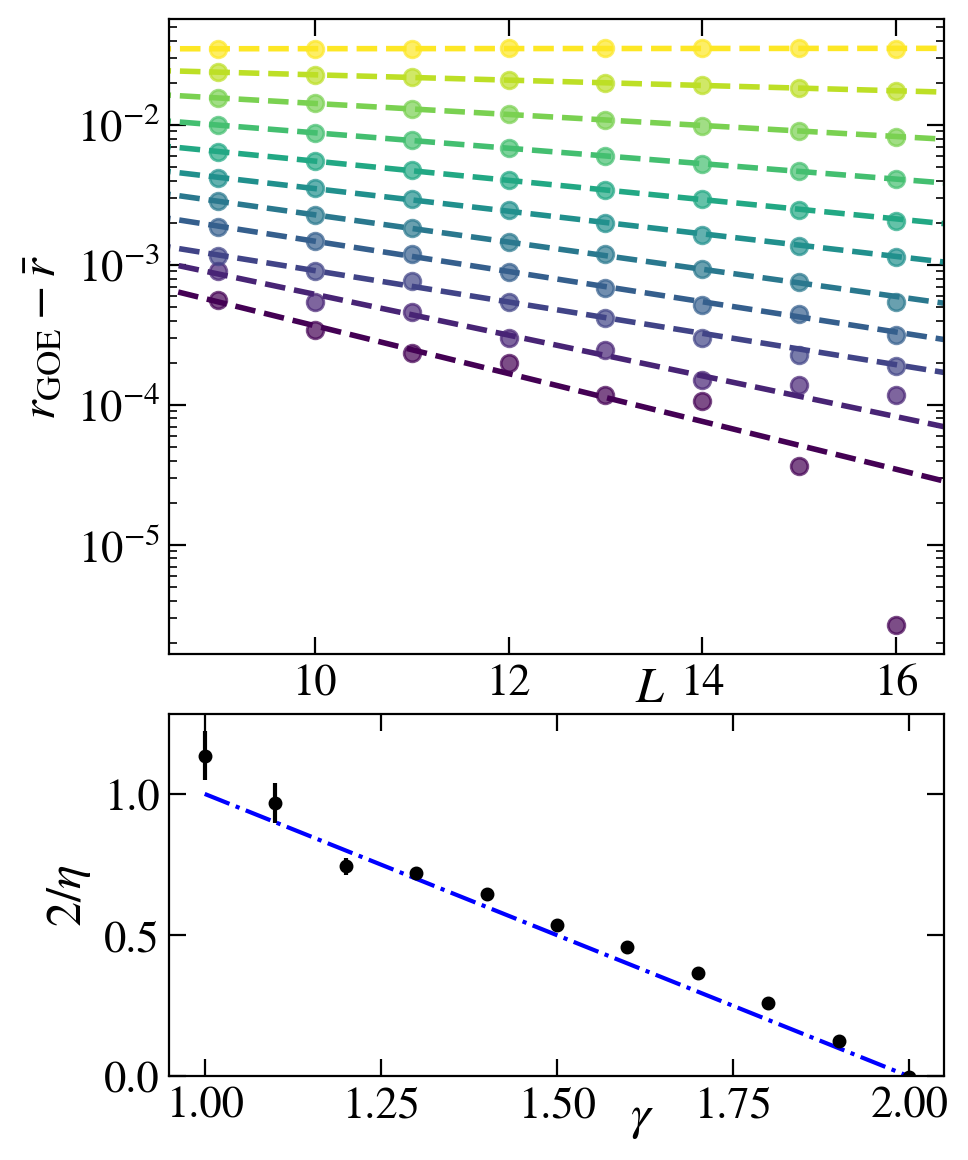

In [381]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(9, 17, 1)

DIM = 1
# fig, axis1 = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200, sharex=False, sharey=False)
# fig2, ax = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200, sharex=False, sharey=False)
# axis = [axis1]
fig = plt.figure(figsize=(5,7), dpi = 200)
fig.subplots_adjust(hspace=0.0)
gs = GridSpec(2, 1, height_ratios = [7, 4]) 
# gs1 = GridSpec(1,1)
# gs.update(top=0.98, bottom=0.48, hspace=0.02)
# gs1.update(top=0.4, bottom=0.02)
axis = [fig.add_subplot(gs[0])]
ax = fig.add_subplot(gs[1])

r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5
alfac = 1/np.sqrt(2)

def exp_fit_kurwa(x, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * 2**(-x * xi / 2)

for iig, gamma_vals in enumerate([np.arange(1, 2.01, 0.1)]):
# gamma_vals = np.arange(0.5, 2.01, 0.1)
    dim = 2**L

    norm = matplotlib.colors.Normalize(
            vmin=min(gamma_vals),
            vmax=max(gamma_vals))
    s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
    s_m.set_array([])

    etas = []
    etas_err = []
    for ibsifusdf, gx in enumerate(gamma_vals):
        gx = np.round(gx, 1)
        alfa = np.sqrt( np.exp( (gx - 1) * np.log(alfac**2) ) )
        col = s_m.to_rgba(gx)
        
        gap_ratio = np.zeros(sizes.shape)
        realis = np.zeros(sizes.shape)
        # ------------------------------------------------------------ ROZENZWEIG-PORTER
        for iiL, L in enumerate(sizes):
            dim = 2**L
            counter = 0
            gap = 0#np.zeros((45))
            
            name = base_dir(model=modello, d=DIM) + 'GOE/ENERGY_SPECTRA/E_spectra' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies'))
                    dim = Ex.size
                    meanE = np.mean(Ex)
                    idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - meanE))
                    R = np.array(file.get('realisations'))
                    # gap += np.mean(np.array(file.get('gap_ratio'))) * R
                    gap += np.mean(np.array(file.get('weight_ratio'))) * R
                    realis[iiL] += R
            else:
                print(name)
            
            name = base_dir(model=modello, d=DIM) + 'GOE/ENERGY_SPECTRA2/E_spectra' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies'))
                    dim = Ex.size
                    meanE = np.mean(Ex)
                    idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - meanE))
                    R = np.array(file.get('realisations'))
                    # gap += np.mean(np.array(file.get('gap_ratio'))) * R
                    gap += np.mean(np.array(file.get('weight_ratio'))) * R
                    realis[iiL] += R
            else:
                print(name)
            # name = base_dir(model=modello, d=DIM) + 'Entropy/ManyBody/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
            # if exists(name):
            #     with h5py.File(name, "r") as file:
            #         R = np.array(file.get('realisations'))
            #         gap += np.mean(np.array(file.get('gap ratio'))) * R
            #         realis[iiL] += R
            # else:
            #     print(name)
            
            gap_ratio[iiL] = gap / realis[iiL]
        print(gx, realis)
        # yy = 0.5307 - gap_ratio
        # yy = 0.5307 - gap_ratio
        yy = gap_ratio - 0.8100699350
        yy = np.abs(yy)
        # print(gx, sizes, yy)
        
        sizes = sizes[~np.isnan(yy)]
        yy = yy[~np.isnan(yy)]
        parsolo, pconv, fit_info, msg, _ = fit(exp_fit_kurwa,
                        xdata = sizes,
                        ydata = yy,
                        full_output=True, maxfev=10000)
        A = parsolo[0]
        # eta_fit = 1 / parsolo[1]
        perr = np.sqrt(np.diag(pconv))
        if eta_fit > 1e6:
            eta_fit = np.nan
        etas.append(parsolo[1])
        etas_err.append(perr[1])
        
        # if (iig == 0 and gx > 1.0) or (iig and gx < 4):
        z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
        axis[iig].plot(z, exp_fit_kurwa(z, *parsolo), color=col, ls='--', lw=2)
        axis[iig].scatter(sizes, yy, color=col, alpha=0.7)
        
        
    etas = np.array(etas)
    # ax.scatter(gamma_vals, etas, color='red' if iig else 'k', marker='s' if iig else 'o', facecolor='None' if iig else 'k')
    line = ax.errorbar(x=gamma_vals, y=etas, yerr=etas_err, fmt='o', color='k', markersize=4)
    
    axis[iig].set_xlim(min(sizes)-0.5, max(sizes)+0.5)

# norm = matplotlib.colors.Normalize(
#         vmin=min(sizes[1:]),
#         vmax=max(sizes[1:]))
# s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
# s_m.set_array([])
# etas_L = np.transpose(etas_L) 
# for iiL, L in enumerate(sizes[1:-1]):
#     if L > 11:
#         ax.scatter(gamma_vals, 2*etas_L[iiL], color=s_m.to_rgba(L), facecolor='None')
# ax.set_ylim(0, 1.05)

z = np.linspace(1.0, 2, 1000)
ax.plot(z, np.abs(2 - z), ls='-.', color='blue')
ax.set_xlim(0.95, 2.05)
ax.set_ylim(0, None)
# z = np.linspace(0.5, 1.0, 1000)
# ax.plot(z, [1]*z.size, ls='-.', color='blue')
# # ax[1].scatter(gamma_vals, 1/(etas_NE / np.log(2)), color='red', marker='s', facecolor='None')

fig_help.set_plot_elements(axis[0], ylabel=r"$r_{\rm GOE}-\bar{r}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
# fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r} - r_{\rm PE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(ax, ylabel=r"$2/\eta$", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='linear')

axis[0].xaxis.set_label_coords(.62, -0.02)
ax.xaxis.set_label_coords(.61, -0.05)

fig.subplots_adjust(wspace = 0.12, hspace=0.12)
fig.savefig("PLOTS_FADING/ANOMALOUS/FigA2.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [309]:
x = None
if x is None:
    print('x is None')
else:
    x[0]

x is None


0.3862943611198906

[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9]
RP:  AAAA [0.99983868 0.97382877 0.90259755 0.78871862 0.65976291 0.5358276
 0.41822424 0.28904147 0.166352   0.04704062] [0.00010585 0.00069386 0.00236033 0.0045846  0.00434947 0.0035346
 0.00216459 0.00119299 0.01098608 0.00432662]
RP:  BBBB [0.99926353 0.95460615 0.86937443 0.75517597 0.63267362 0.516516
 0.40383331 0.29241952 0.18842402 0.07166478] [3.43392970e-05 2.67036497e-04 2.02645103e-03 3.06817542e-03
 2.72909217e-03 2.12870437e-03 2.47770806e-03 1.18101481e-03
 1.04723105e-02 6.48626220e-03]


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


./UM results/AA/log/ldos_data_a=0.980,n=1.h5
UM:  AAAA [0.40476674 0.52216734 0.64384272 0.75781953 0.82969183 0.88820407
 0.9367211  0.97773271 0.98598275 1.0038252  1.02585124 1.01968205
 1.02131852 1.00532991 1.00587614] [0.01096723 0.01236023 0.00936283 0.0083454  0.00930684 0.00833318
 0.0077712  0.00945212 0.00564316 0.00945263 0.01140648 0.01303448
 0.01182575 0.01029336 0.01128653]
UM:  BBBB [0.45757533 0.57655417 0.72365027 0.78206032 0.8385323  0.89450834
 0.93071551 0.97927516 0.98724544 0.99768097 1.03226968 1.01495365
 1.02499663 1.02202509        nan] [0.01800447 0.00628467 0.02393999 0.00824439 0.00618468 0.01486831
 0.01287799 0.01474408 0.00706419 0.00532488 0.00761392 0.00797822
 0.00213774 0.00305049        nan]


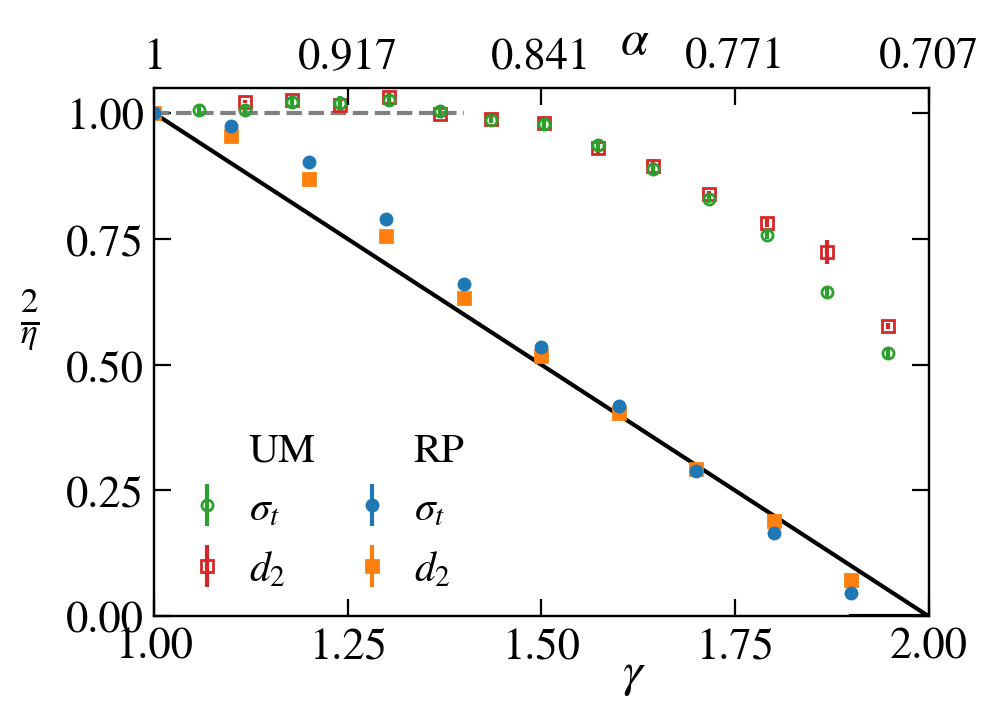

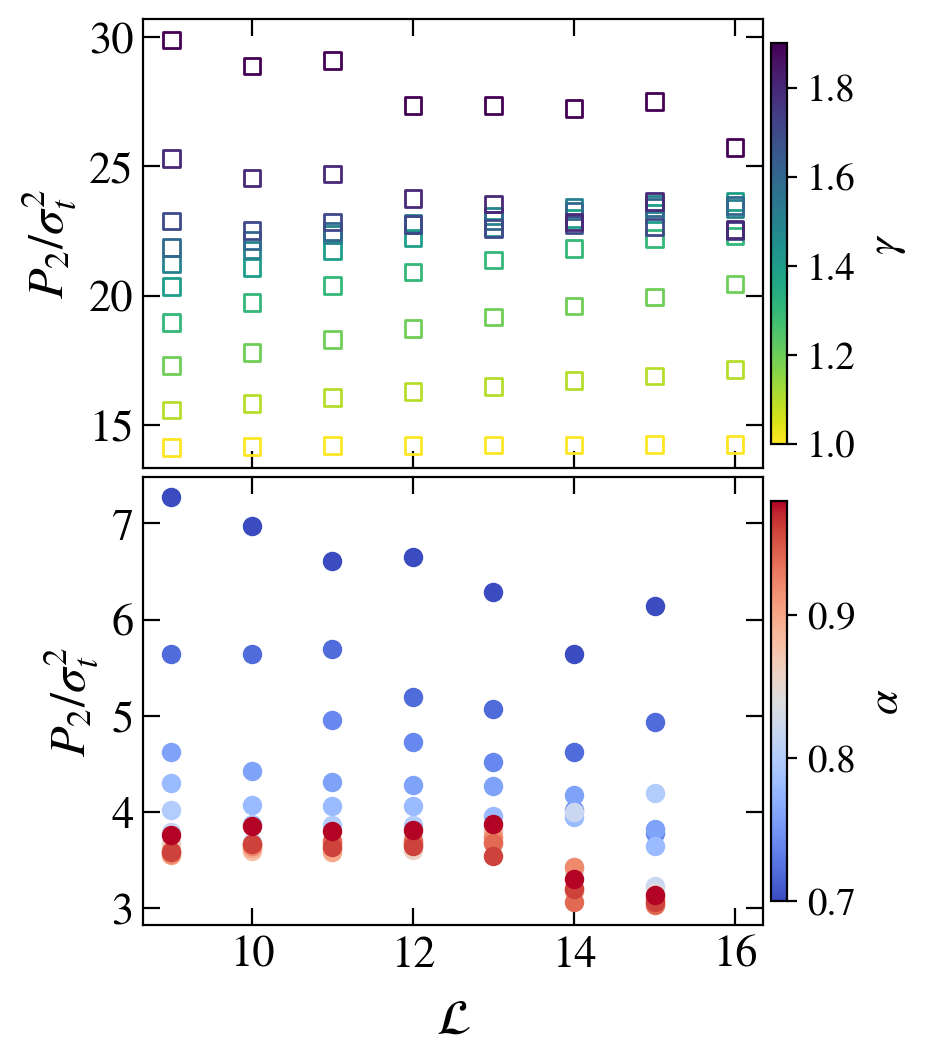

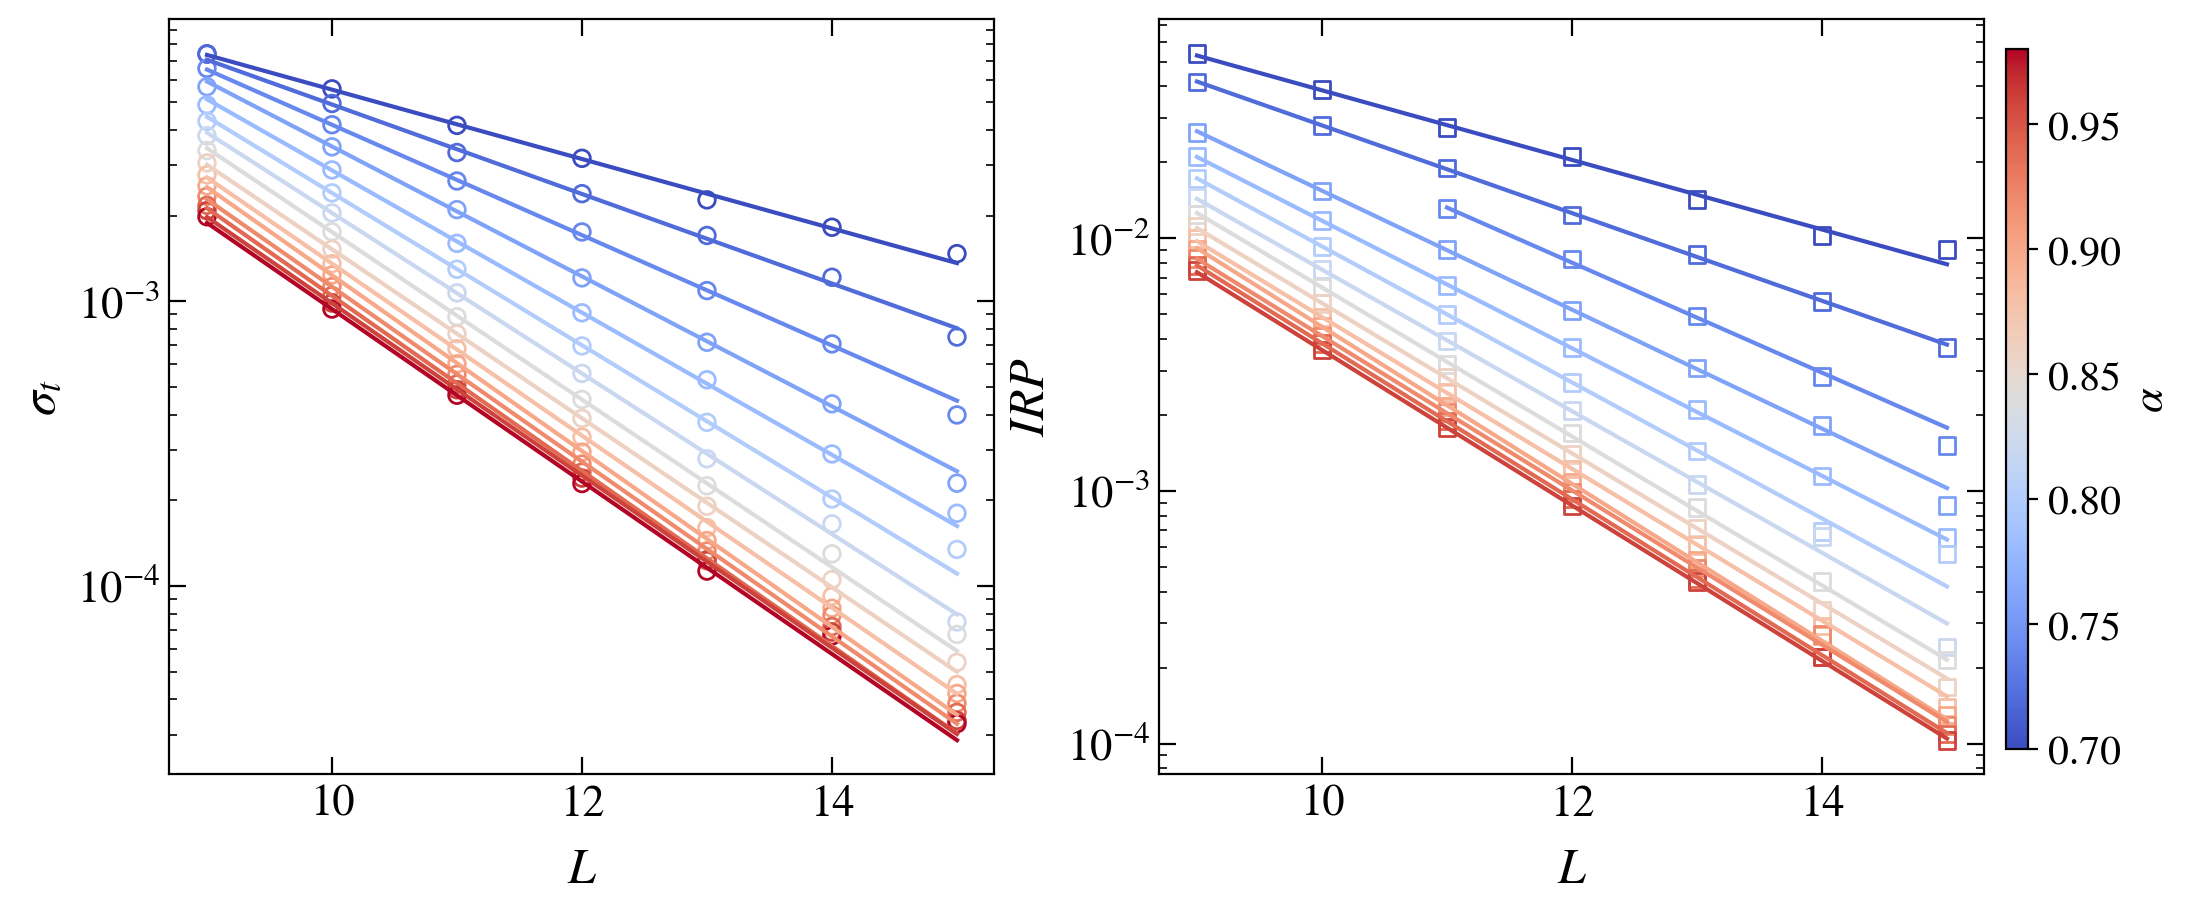

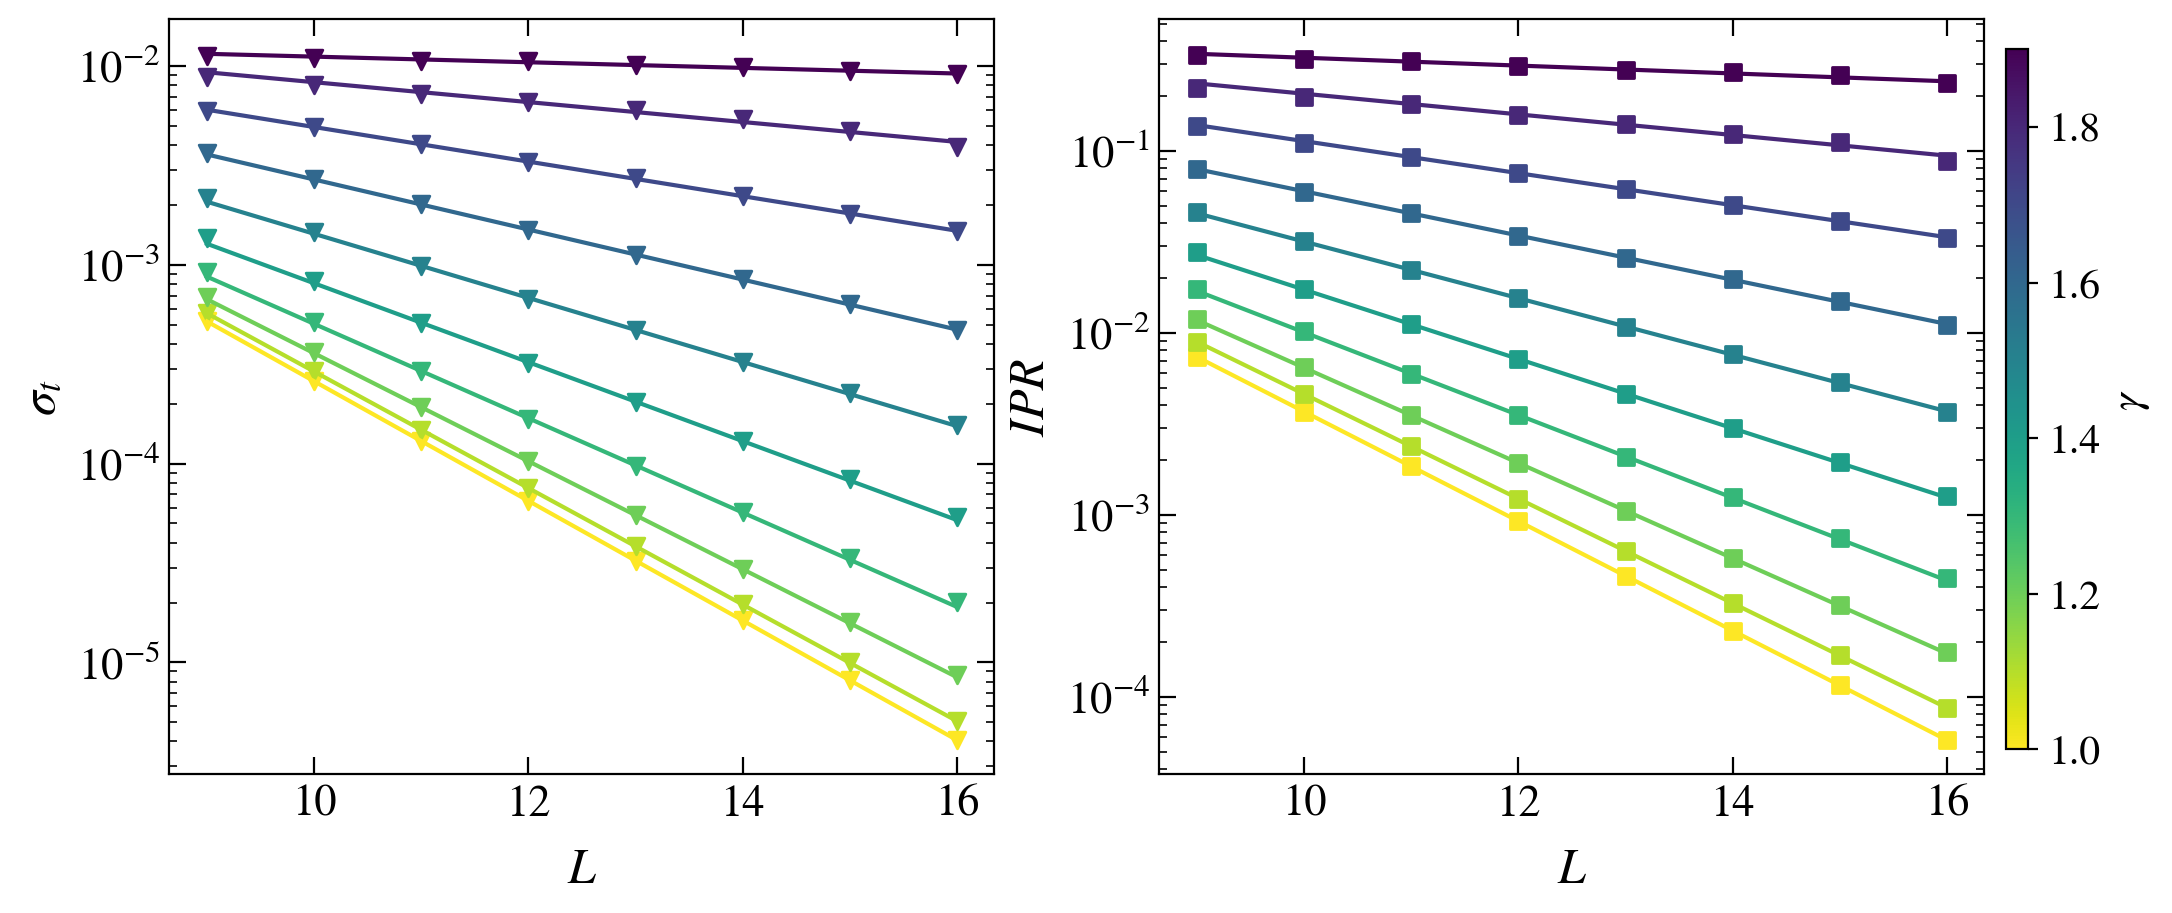

In [310]:


L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(8, 17, 1)

DIM = 1
fig_end, axes = plt.subplots( nrows=1, ncols=1, figsize=(5,3.5), dpi = 200)

# figoshi, axisshi = plt.subplots( nrows=1, ncols=2, figsize=(6,3), dpi = 200)
# ax1 = axisshi[0];   ax2 = axisshi[1]
# ax = ax1
figoshi, ax = plt.subplots( nrows=2, ncols=1, figsize=(4,6), dpi = 200, sharex = True)
figoshi.subplots_adjust(wspace = 0.02, hspace=0.02)
# fig_end = plt.figure(figsize=(7.5,4), dpi = 300)
# gs = GridSpec(nrows=2, ncols=2, width_ratios=[3, 2])
# axes = fig_end.add_subplot(gs[:,0])
# ax = fig_end.add_subplot(gs[0,1])
# ax2 = fig_end.add_subplot(gs[1,1])

fig, axis1 = plt.subplots( nrows=1, ncols=2, figsize=(11,5), dpi = 200)
fig2, axis2 = plt.subplots( nrows=1, ncols=2, figsize=(11,5), dpi = 200)

axis = [*axis1, *axis2]

# gammas = np.array( [*np.arange(0.5, 2.0, 0.1), *np.arange(2.1, 2.2, 0.1)] )
gammas = np.arange(1, 1.91, 0.1)
g_crit = 2
alfac = 1 / np.sqrt(2)

print(gammas)

norm = matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis_r', norm=norm)
s_m.set_array([])


def fading_erg(x, eta, a):
    return a * 2**(-x * eta)

def fading_loc(x, eta, a):
    return a * 2**(x * eta)


qs = np.array( [0.5, 1.0, 1.5, 2.0, 3.0] )
q = 2

colors = []
eta_fluct = []
eta_ipr = []
eta_fluct_err = []
eta_ipr_err = []

handles = []
handles2 = []
gammas_plot = [1.4, 1.6]
# ------------------------------------------------------------ ROZENZWEIG-PORTER~
eps = 0.5
for iia, gx in enumerate(gammas):
    name_out = prefix +  "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
    col = s_m.to_rgba(gx)
    colors.append(col)
    
    fading_fit = fading_erg #if gx <= g_crit else fading_loc
    

    typ_susc = np.zeros(sizes.shape)
    wH_typ = np.zeros(sizes.shape)
    spec_at_wH_G = np.zeros(sizes.shape)
    for ii, L in enumerate(sizes):
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        # if not exists(name):
        #     name = base_dir(model=modello, d=DIM) + 'SpectralFunctions2/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - 0.5))
                    
                typ_susc[ii] = 1/np.array(file.get('TYP_SUSC'))[-2]
                wH_typ[ii] = np.array(file.get('wH_typ'))[-2]
    tH = 2 * np.pi / wH_typ
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            # print(sizes, np.array(file.get('sizes'))[3:])
            sizes = np.array(file.get('sizes'))[1:]
            realis = np.array(file.get('realisations'))[1:]
            idx = np.argmin( np.abs(Ex - eps) )
            ipr = np.array(file.get('ipr'))[np.argmin(np.abs(qs - q))][1:]
            temp_fluct = np.zeros(sizes.shape)
            for ii, L in enumerate(sizes):
                times= np.array(file.get('TIMES/L=%d'%L))#[:-50]
                idx1 = np.argmin( np.abs(times - tH[ii] * 5))
                idx2 = np.argmin( np.abs(times - tH[ii] * 5))
                sig = np.array(file.get('temporal fluctuations2'))[1 + ii]
                # sig = np.array(file.get('temporal fluctuations'))[2 + ii]
                temp_fluct[ii] = np.mean( sig[idx1 : -100] )
            # temp_fluct = np.zeros(sizes.shape)
            axis[2].scatter(sizes, temp_fluct, color=col, marker='v')
            pars, pconv, fit_info, msg, _ = fit(fading_fit,
                            xdata = sizes[~np.isnan(temp_fluct)][-6:],
                            ydata = temp_fluct[~np.isnan(temp_fluct)][-6:],
                            full_output=True, maxfev=10000)
            perr = np.sqrt(np.diag(pconv))
            # print(J, alfa, fit_info['fvec'])
            dense_sizes = np.linspace(sizes[0], sizes[-1], 10000)
            axis[2].plot(dense_sizes, fading_fit(dense_sizes, *pars), lw=1.5, color=col, ls = '-')
            # print(gx, *pars)
            _etaX_ = pars[0]
            # _etaX_ = -(np.diff(np.log(temp_fluct)) / np.diff(np.log(2**sizes)))
            # _etaX_ = (_etaX_[-2] + _etaX_[-1])/2
            if _etaX_ > 1e6 or gx >= 2.5: 
                _etaX_ = np.nan
            eta_fluct.append(_etaX_)
            eta_fluct_err.append(perr[0])
            
            axis[3].scatter(sizes, ipr, color=col, marker='s')
            pars, pconv, fit_info, msg, _ = fit(fading_fit,
                            xdata = sizes[-6:],
                            ydata = ipr[-6:],
                            full_output=True, maxfev=10000)
            perr = np.sqrt(np.diag(pconv))
            # print(J, alfa, fit_info['fvec'])
            dense_sizes = np.linspace(sizes[0], sizes[-1], 10000)
            axis[3].plot(dense_sizes, fading_fit(dense_sizes, *pars), lw=1.5, color=col, ls = '-')
            # print(gx, pars[1], gamma_fun(q - 0.5) * gamma_fun(q + 0.5) / gamma_fun(q) / np.pi / np.sqrt(np.pi / 8)**(2*q-2))
            _etaX_ = (pars[0])
            # _etaX_ = -(np.diff(np.log(ipr)) / np.diff(np.log(2**sizes)))
            # _etaX_ = (_etaX_[-2] + _etaX_[-1])/2
            if _etaX_ > 1e6: _etaX_ = np.nan
            eta_ipr.append(_etaX_)
            eta_ipr_err.append(perr[0])
            # print(L, gx, _etaX_, perr[0])
            
            ax[0].scatter(sizes, ipr / temp_fluct, marker='s', color=col, facecolor='None')
                # ax.scatter(sizes, temp_fluct**2, marker='o', color=col)
            # if any(ipr - temp_fluct < 0):
            #     print("RPM g=", gx, "diff=", ipr - temp_fluct)
    else:   
        print(name_out)


eta_fluct   = np.array(eta_fluct)
eta_ipr     = np.array(eta_ipr) / (q-1)
eta_ipr_err = np.array(eta_ipr_err)
eta_fluct_err = np.array(eta_fluct_err)
print("RP:  AAAA", eta_fluct, eta_fluct_err)
print("RP:  BBBB", eta_ipr, eta_ipr_err)
colors_ls_cyc = itertools.cycle(colors_ls)
# line = axes.scatter(gammas, eta_fluct, marker='o', color=next(colors_ls_cyc), label=r"$\sigma_t$", zorder=10)
line = axes.errorbar(x=gammas, y=eta_fluct, yerr=eta_fluct_err, fmt='o', color=next(colors_ls_cyc), label=r"$\sigma_t$", zorder=10, markersize=4)
handles.append(line)

# line = axes.scatter(gammas, eta_ipr, marker='s', color=next(colors_ls_cyc), label=r"$d_2$", zorder=4)
line = axes.errorbar(x=gammas, y=eta_ipr, yerr=eta_ipr_err, fmt='s', color=next(colors_ls_cyc), label=r"$d_2$", zorder=4, markersize=4)
handles.append(line)

fig2.subplots_adjust(right=0.95)
cbar_ax = fig2.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig2.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\gamma$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

box = ax[0].get_position()
cax = figoshi.add_axes([0.91, box.y0+0.02, 0.02, box.height-0.04])
cbar = figoshi.colorbar(s_m, cax=cax)
cbar.set_label(r"$\gamma$", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# cbar1 = figoshi.colorbar(s_m, ax=ax1)
# cbar1.set_label("Colorbar 1")

axes2 = axes.twiny()
# ------------------------------------------------------------ ULTRAMETRIC MODEL
eta_fluct = []
eta_fluct_err = []
eta_ipr = []
eta_ipr_err = []

sizes = np.arange(9, 16, 1)
alfas = np.arange(0.7, 0.99, 0.02)
norm = matplotlib.colors.Normalize(
        vmin=min(alfas),
        vmax=max(alfas))
s_m = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=norm)
s_m.set_array([])

for iia, alfa in enumerate(alfas):
    col = s_m.to_rgba(alfa)
    temp_fluct = np.zeros((sizes.size))
    for ii, L in enumerate(sizes):
        name_out = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('alphas'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                tH = 2 * np.pi / np.array(file.get('mean_lvl/0.50/mean'))[idxa]
        else:
            print(name_out)
        name_out = "./UM results/TimeEvo/Ns=%d.h5"%(L)   
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('Sz/0/ME/alphas'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                if np.abs(alfa - _alfas_[idxa]) > 5e-3:
                    # print(alfa, name_out)
                    continue
                times = np.array(file.get('Sz/0/ME/fluct/%d/times'%(idxa) ))
                idx1 = np.argmin( np.abs(times - tH))
                # temp_fluct[ii] = np.mean(np.array(file.get('Sz/0/ME/fluct/%d/mean'%(idxa) ))[idx1 : -100]**2)
                temp_fluct[ii] = np.array(file.get('Sz/0/ME/stat/lt/evo/fluct'))[idxa]
        else:
            print(name_out)
    
    line = axis[0].scatter(sizes, temp_fluct, color=col, marker='o', facecolor='None')
    pars, pconv, fit_info, msg, _ = fit(fading_fit,
                    xdata = sizes[~np.isnan(temp_fluct)][-6:],
                    ydata = temp_fluct[~np.isnan(temp_fluct)][-6:],
                    full_output=True, maxfev=10000)
    perr = np.sqrt(np.diag(pconv))
    # print(J, alfa, fit_info['fvec'])
    dense_sizes = np.linspace(sizes[0], sizes[-1], 10000)
    axis[0].plot(dense_sizes, fading_fit(dense_sizes, *pars), lw=1.5, color=col, ls = '-')
    # print(gx, *pars)
    _etaX_ = pars[0]
    
    # _etaX_ = -(np.diff(np.log(temp_fluct)) / np.diff(np.log(2**sizes)))
    # _etaX_ = (_etaX_[-2] + _etaX_[-1])/2
    if _etaX_ > 1e6 or gx >= 2.5: 
        _etaX_ = np.nan
    eta_fluct.append(_etaX_)
    eta_fluct_err.append(perr[0])
    
    name_out = "./UM results/AA/log/ldos_data_a=%.3f,n=1.h5"%alfa
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            Ns = np.array(file.get('ns'))[1:]
            Ns = Ns[:-1]
            # print(Ns, sizes)
            ipr = np.zeros(Ns.shape)
            for ii, L in enumerate(Ns):
                ipr[ii] = np.array(file.get('%d/ipr/mean/2.0'%L))[0]
                # print(ipr[ii])
                
            line = axis[1].scatter(Ns, ipr, color=col, marker='s', facecolor='None')
            pars2, pconv2, fit_info, msg, _ = fit(fading_fit,
                    xdata = Ns[~np.isnan(ipr)][-6:],
                    ydata = ipr[~np.isnan(ipr)][-6:],
                    full_output=True, maxfev=10000)
            perr = np.sqrt(np.diag(pconv2))
            dense_sizes = np.linspace(Ns[0], Ns[-1], 10000)
            axis[1].plot(dense_sizes, fading_fit(dense_sizes, *pars2), lw=1.5, color=col, ls = '-')
            
            _etaX_ = pars2[0]
            if _etaX_ > 1e6 or alfa > 1:
                _etaX_ = np.nan
            eta_ipr.append(_etaX_)
            eta_ipr_err.append(perr[0])
            
            # ax2.scatter(sizes, ipr - temp_fluct, marker='o', color=col)
        # if any(ipr - temp_fluct < 0):
        #     print("RPM g=", gx, "diff=", ipr - temp_fluct)
    else:
        print(name_out)
        eta_ipr.append(np.nan)
        eta_ipr_err.append(np.nan)
    
    common = np.intersect1d(sizes, Ns)

    # Indices of those common values in each array
    indices_a = np.transpose([np.where(sizes == x)[0] for x in common])[0]
    indices_b = np.transpose([np.where(Ns == x)[0] for x in common])[0]
    # print(Ns, sizes, indices_a, indices_b)
    
    ipr = ipr[indices_b]
    temp_fluct = temp_fluct[indices_a]
    ax[1].scatter(Ns[indices_b], ipr / temp_fluct, marker='o', color=col)
    # name_out = "./UM results/fractal/_Ngrain=1/fractal_dimension.h5"
    # if exists(name_out):
    #     with h5py.File(name_out, "r") as file:
    #         Ns = np.array(file.get('4/a=%.3f/Ns'%alfa))
    #         d2 = np.array(file.get('4/a=%.3f/q=2.00'%alfa))
    #         # d2 = (16*d2[-1] + 15*d2[-2] + 14*d2[-4]+ 13*d2[-4]) / 4
    #         # d2 = np.sum(Ns[-4:] * d2[-4:]) / np.sum(Ns[-4:])
    #         d2 = (d2[-2] + d2[-1])/2
    #         eta_ipr.append(d2)
    # else:
    #     print(name_out)
    #     eta_ipr.append(np.nan)
        
    
_gammas_ = 1 + np.log(alfas) / np.log(alfac) 
eta_fluct   = np.array(eta_fluct)
eta_ipr     = np.array(eta_ipr)
eta_ipr_err     = np.array(eta_ipr_err)
eta_fluct_err     = np.array(eta_fluct_err)
print("UM:  AAAA", eta_fluct, eta_fluct_err)
print("UM:  BBBB", eta_ipr, eta_ipr_err)
# line = axes.scatter(_gammas_, eta_fluct, marker='o', color=next(colors_ls_cyc), label=r"$\sigma_t$", zorder=10, facecolor='None')
line = axes.errorbar(x=_gammas_, y=eta_fluct, yerr=eta_fluct_err, fmt='o', color=next(colors_ls_cyc), label=r"$\sigma_t$", zorder=10, markerfacecolor='none', markersize=4)
handles.append(line)
# line = axes.scatter(_gammas_, eta_ipr, marker='s', color=next(colors_ls_cyc), label=r"$d_2$", zorder=10, facecolor='None')
line = axes.errorbar(x=_gammas_, y=eta_ipr, yerr=eta_ipr_err, fmt='s', color=next(colors_ls_cyc), label=r"$d_2$", zorder=4, markerfacecolor='none', markersize=4)
handles.append(line)
# axes.scatter(gammas, eta_ipr, marker='s', color=next(colors_ls_cyc), label=r"$d_2$", zorder=4)
# fig_help.set_plot_elements(axis[0], ylabel=r"$\mathcal{Q}_{\infty}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[0], ylabel=r"$\sigma_t$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$IRP$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[3], ylabel=r"$IPR$", xlabel=r"$L$", font_size=16, set_legend=1,           xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[2], ylabel=r"$\sigma_t$", xlabel=r"$L$", font_size=16, set_legend=1,           xscale='linear', yscale='log')

line, = axes.plot(np.nan, np.nan, color='k', ls=':', lw=0,label = r"UM")
handles.append(line)
line, = axes.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RP")
handles.append(line)
indices = np.array([4,2, 3, 5, 0, 1])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )
    

xx = np.linspace(1, g_crit-0.0, 1000)
axes.plot(xx, (2 - xx), ls='-', color='k')
xx = np.linspace(2, max(gammas), 1000)
axes.plot(xx, [0]*xx.size, ls='-', color='k')
axes.axhline(y=1, xmax=0.4, ls='--', color='gray')

fig_help.set_plot_elements(axes2, ylabel=r"", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_plot_elements(axes, ylabel=r"$\eta$", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='linear')

fig_help.set_legend(axes, fontsize=15, loc='lower left', ncol = 2, handles = _handle_shit, columnspacing=0.6)#, anchor=(0.88, 1.02))
axes.set_ylabel(r"$\frac{2}{\eta}$", rotation=0, fontsize=18)
axes.yaxis.set_label_coords(-0.16, 0.5)
axes.tick_params(axis='both', which='major', direction="in",length=6, labelsize=16, bottom=True, top=False, left=True, right=True)
axes2.tick_params(axis='both', which='major', direction="in", length=6, labelsize=16, bottom=False, top=True, left=True, right=True)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')

fig_help.set_plot_elements(ax[0], ylabel=r"$P_2/\sigma_t^2$", xlabel=r"", font_size=16, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_plot_elements(ax[1], ylabel=r"$P_2/\sigma_t^2$", xlabel=r"$\mathcal{L}$", font_size=16, set_legend=1, xscale='linear', yscale='linear')
# fig_help.set_legend(ax, fontsize=15, loc='lower left', ncol = 2, handles = _handle_shit, columnspacing=0.6)#, anchor=(0.88, 1.02))

axes.set_xlim(1, 2.0)
axes.set_xticks([1, 1.25, 1.5, 1.75, 2])

ax1Ticks = axes.get_xticks()   
ax2Ticks = ax1Ticks

def tick_function(X):
    V = np.sqrt( np.exp( (X - 1) * np.log(alfac**2) ) )
    return [("%g" % z if z == 1 else "%.3f"%z) for z in V]

axes2.set_xticks(ax2Ticks)
axes2.set_xbound(axes.get_xbound())
axes2.set_xticklabels(tick_function(ax2Ticks))

axes.set_ylim(0, 1.05)

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\alpha$", fontsize=16)
cbar.ax.tick_params(labelsize=15)


box = ax[1].get_position()
cax = figoshi.add_axes([0.91, box.y0+0.02, 0.02, box.height-0.04])
cbar = figoshi.colorbar(s_m, cax=cax)
cbar.set_label(r"$\alpha$", fontsize=16)
cbar.ax.tick_params(labelsize=14)

fig.subplots_adjust(wspace = 0.2, hspace=0.2)
fig2.subplots_adjust(wspace = 0.2, hspace=0.2)

fig_end.subplots_adjust(wspace = 0.3, hspace=0.02)
figoshi.savefig("PLOTS_FADING/ANOMALOUS/Fig3a.pdf", bbox_inches = 'tight', pad_inches=0.02)

axes.xaxis.set_label_coords(.62, 1.13)
axes2.xaxis.set_label_coords(.62, -0.13)

fig_end.savefig("PLOTS_FADING/ANOMALOUS/Fig3.pdf", bbox_inches = 'tight', pad_inches=0.02)

[0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]
[ 9 10 11 12 13 14 15 16]


No handles with labels found to put in legend.
No handles with labels found to put in legend.


./UM results/AA/log/ldos_data_a=0.980,n=1.h5


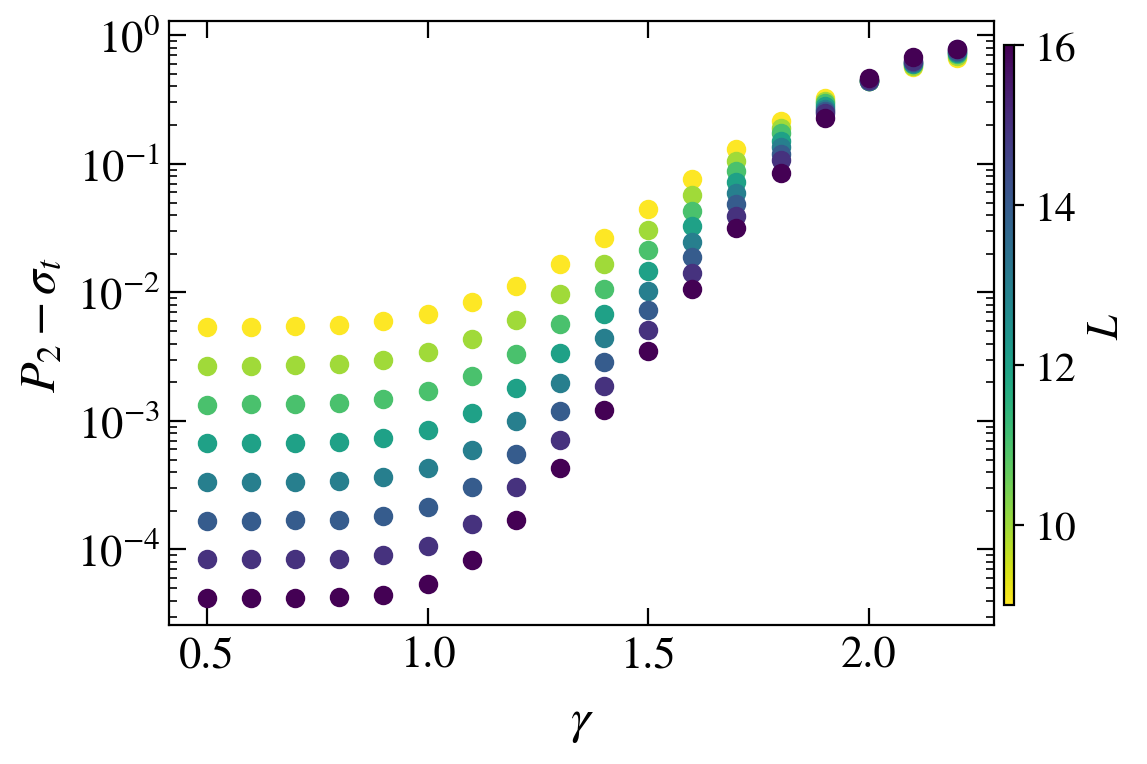

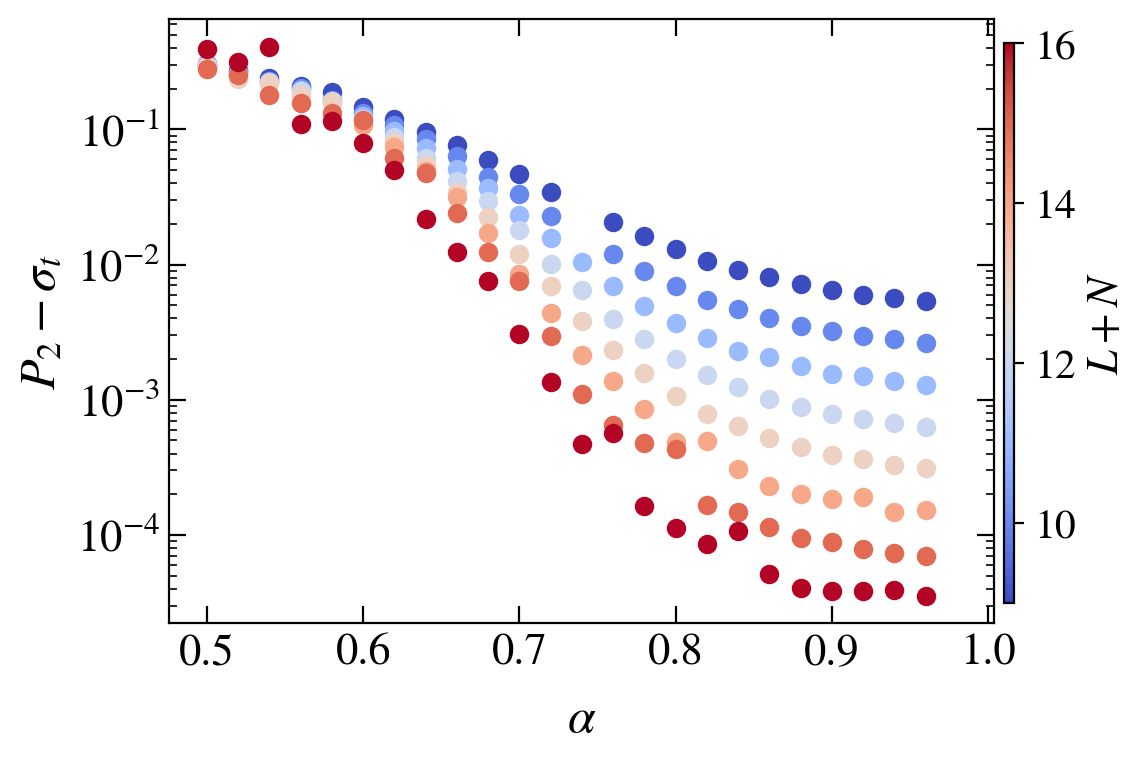

In [10]:
L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(9, 17, 1)

DIM = 1
fig, axis1 = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)
fig2, axis2 = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)

axis = [axis1, axis2]

# gammas = np.array( [*np.arange(0.5, 2.0, 0.1), *np.arange(2.1, 2.2, 0.1)] )
gammas = np.arange(0.5, 2.21, 0.1)
g_crit = 2
alfac = 1 / np.sqrt(2)

print(gammas)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis_r', norm=norm)
s_m.set_array([])


def fading_erg(x, eta, a):
    return a * 2**(-x * eta)

def fading_loc(x, eta, a):
    return a * 2**(x * eta)


qs = np.array( [0.5, 1.0, 1.5, 2.0, 3.0] )
q = 2

colors = []
eta_fluct = []
eta_ipr = []
eta_fluct_err = []
eta_ipr_err = []

handles = []
handles2 = []
gammas_plot = [1.4, 1.6]
# ------------------------------------------------------------ ROZENZWEIG-PORTER~
eps = 0.5
ipr_RP = np.zeros((gammas.size, sizes.size))
temp_fluct_RP = np.zeros((gammas.size, sizes.size))
for iia, gx in enumerate(gammas):
    name_out = prefix +  "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
    col = s_m.to_rgba(gx)
    colors.append(col)
    
    fading_fit = fading_erg #if gx <= g_crit else fading_loc
    

    typ_susc = np.zeros(sizes.shape)
    wH_typ = np.zeros(sizes.shape)
    spec_at_wH_G = np.zeros(sizes.shape)
    for ii, L in enumerate(sizes):
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        # if not exists(name):
        #     name = base_dir(model=modello, d=DIM) + 'SpectralFunctions2/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - 0.5))
                    
                typ_susc[ii] = 1/np.array(file.get('TYP_SUSC'))[-2]
                wH_typ[ii] = np.array(file.get('wH_typ'))[-2]
    tH = 2 * np.pi / wH_typ
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            # print(sizes, np.array(file.get('sizes'))[3:])
            sizes2 = np.array(file.get('sizes'))[1:]
            print(sizes2)
            realis = np.array(file.get('realisations'))[1:]
            idx = np.argmin( np.abs(Ex - eps) )
            ipr_RP[iia, :] = np.array(file.get('ipr'))[np.argmin(np.abs(qs - q))][1:]
            # temp_fluct = np.zeros(sizes.shape)
            for ii, L in enumerate(sizes2):
                times= np.array(file.get('TIMES/L=%d'%L))#[:-50]
                idx1 = np.argmin( np.abs(times - 2*tH[ii]))
                idx2 = np.argmin( np.abs(times - 2*tH[ii]))
                sig = np.array(file.get('temporal fluctuations2'))[1 + ii]
                # sig = np.array(file.get('temporal fluctuations'))[2 + ii]
                temp_fluct_RP[iia, ii] = np.mean( sig[idx1 : -100] )
            
    else:   
        print(name_out)
ipr_RP = np.transpose(ipr_RP)
temp_fluct_RP = np.transpose(temp_fluct_RP) 
for ii, L in enumerate(sizes):
    col = s_m.to_rgba(L)
    axis[0].scatter(gammas, (ipr_RP[ii] - temp_fluct_RP[ii]), color=col)

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$L$", fontsize=16)
cbar.ax.tick_params(labelsize=15)


sizes = np.arange(9, 17, 1)
alfas = np.arange(0.5, 0.99, 0.02)
norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=norm)
s_m.set_array([])

ipr_UM = np.zeros((alfas.size, sizes.size))
temp_fluct_UM = np.zeros((alfas.size, sizes.size))
for iia, alfa in enumerate(alfas):
    col = s_m.to_rgba(alfa)
    for ii, L in enumerate(sizes):
        name_out = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('alphas'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                tH = 2 * np.pi / np.array(file.get('mean_lvl/0.50/mean'))[idxa]
        else:
            print(name_out)
        name_out = "./UM results/TimeEvo/Ns=%d.h5"%(L)   
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('Sz/0/ME/alphas'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                if np.abs(alfa - _alfas_[idxa]) > 5e-3:
                    # print(alfa, name_out)
                    continue
                times = np.array(file.get('Sz/0/ME/fluct/%d/times'%(idxa) ))
                idx1 = np.argmin( np.abs(times - tH))
                # temp_fluct[ii] = np.mean(np.array(file.get('Sz/0/ME/fluct/%d/mean'%(idxa) ))[idx1 : -100]**2)
                temp_fluct_UM[iia, ii] = np.array(file.get('Sz/0/ME/stat/lt/evo/fluct'))[idxa]
        else:
            print(name_out)
    
    
    name_out = "./UM results/AA/log/ldos_data_a=%.3f,n=1.h5"%alfa
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            Ns = np.array(file.get('ns'))[1:]
            # print(Ns, sizes)
            for ii, L in enumerate(Ns):
                iio = np.argmin(np.abs(sizes - L))
                ipr_UM[iia, iio] = np.array(file.get('%d/ipr/mean/2.0'%L))[0]
                # print(ipr[ii])
                
    else:
        print(name_out)
        eta_ipr.append(np.nan)
        eta_ipr_err.append(np.nan)
ipr_UM = np.transpose(ipr_UM)
temp_fluct_UM = np.transpose(temp_fluct_UM) 
for ii, L in enumerate(sizes):
    col = s_m.to_rgba(L)
    axis[1].scatter(alfas, (ipr_UM[ii] - temp_fluct_UM[ii]), color=col)
    
fig_help.set_plot_elements(axis[0], ylabel=r"$P_2-\sigma_t$", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$P_2-\sigma_t$", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='log')

fig2.subplots_adjust(right=0.95)
cbar_ax = fig2.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig2.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$L+N$", fontsize=16)
cbar.ax.tick_params(labelsize=15)


## POWER SPECTRUM TEST

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


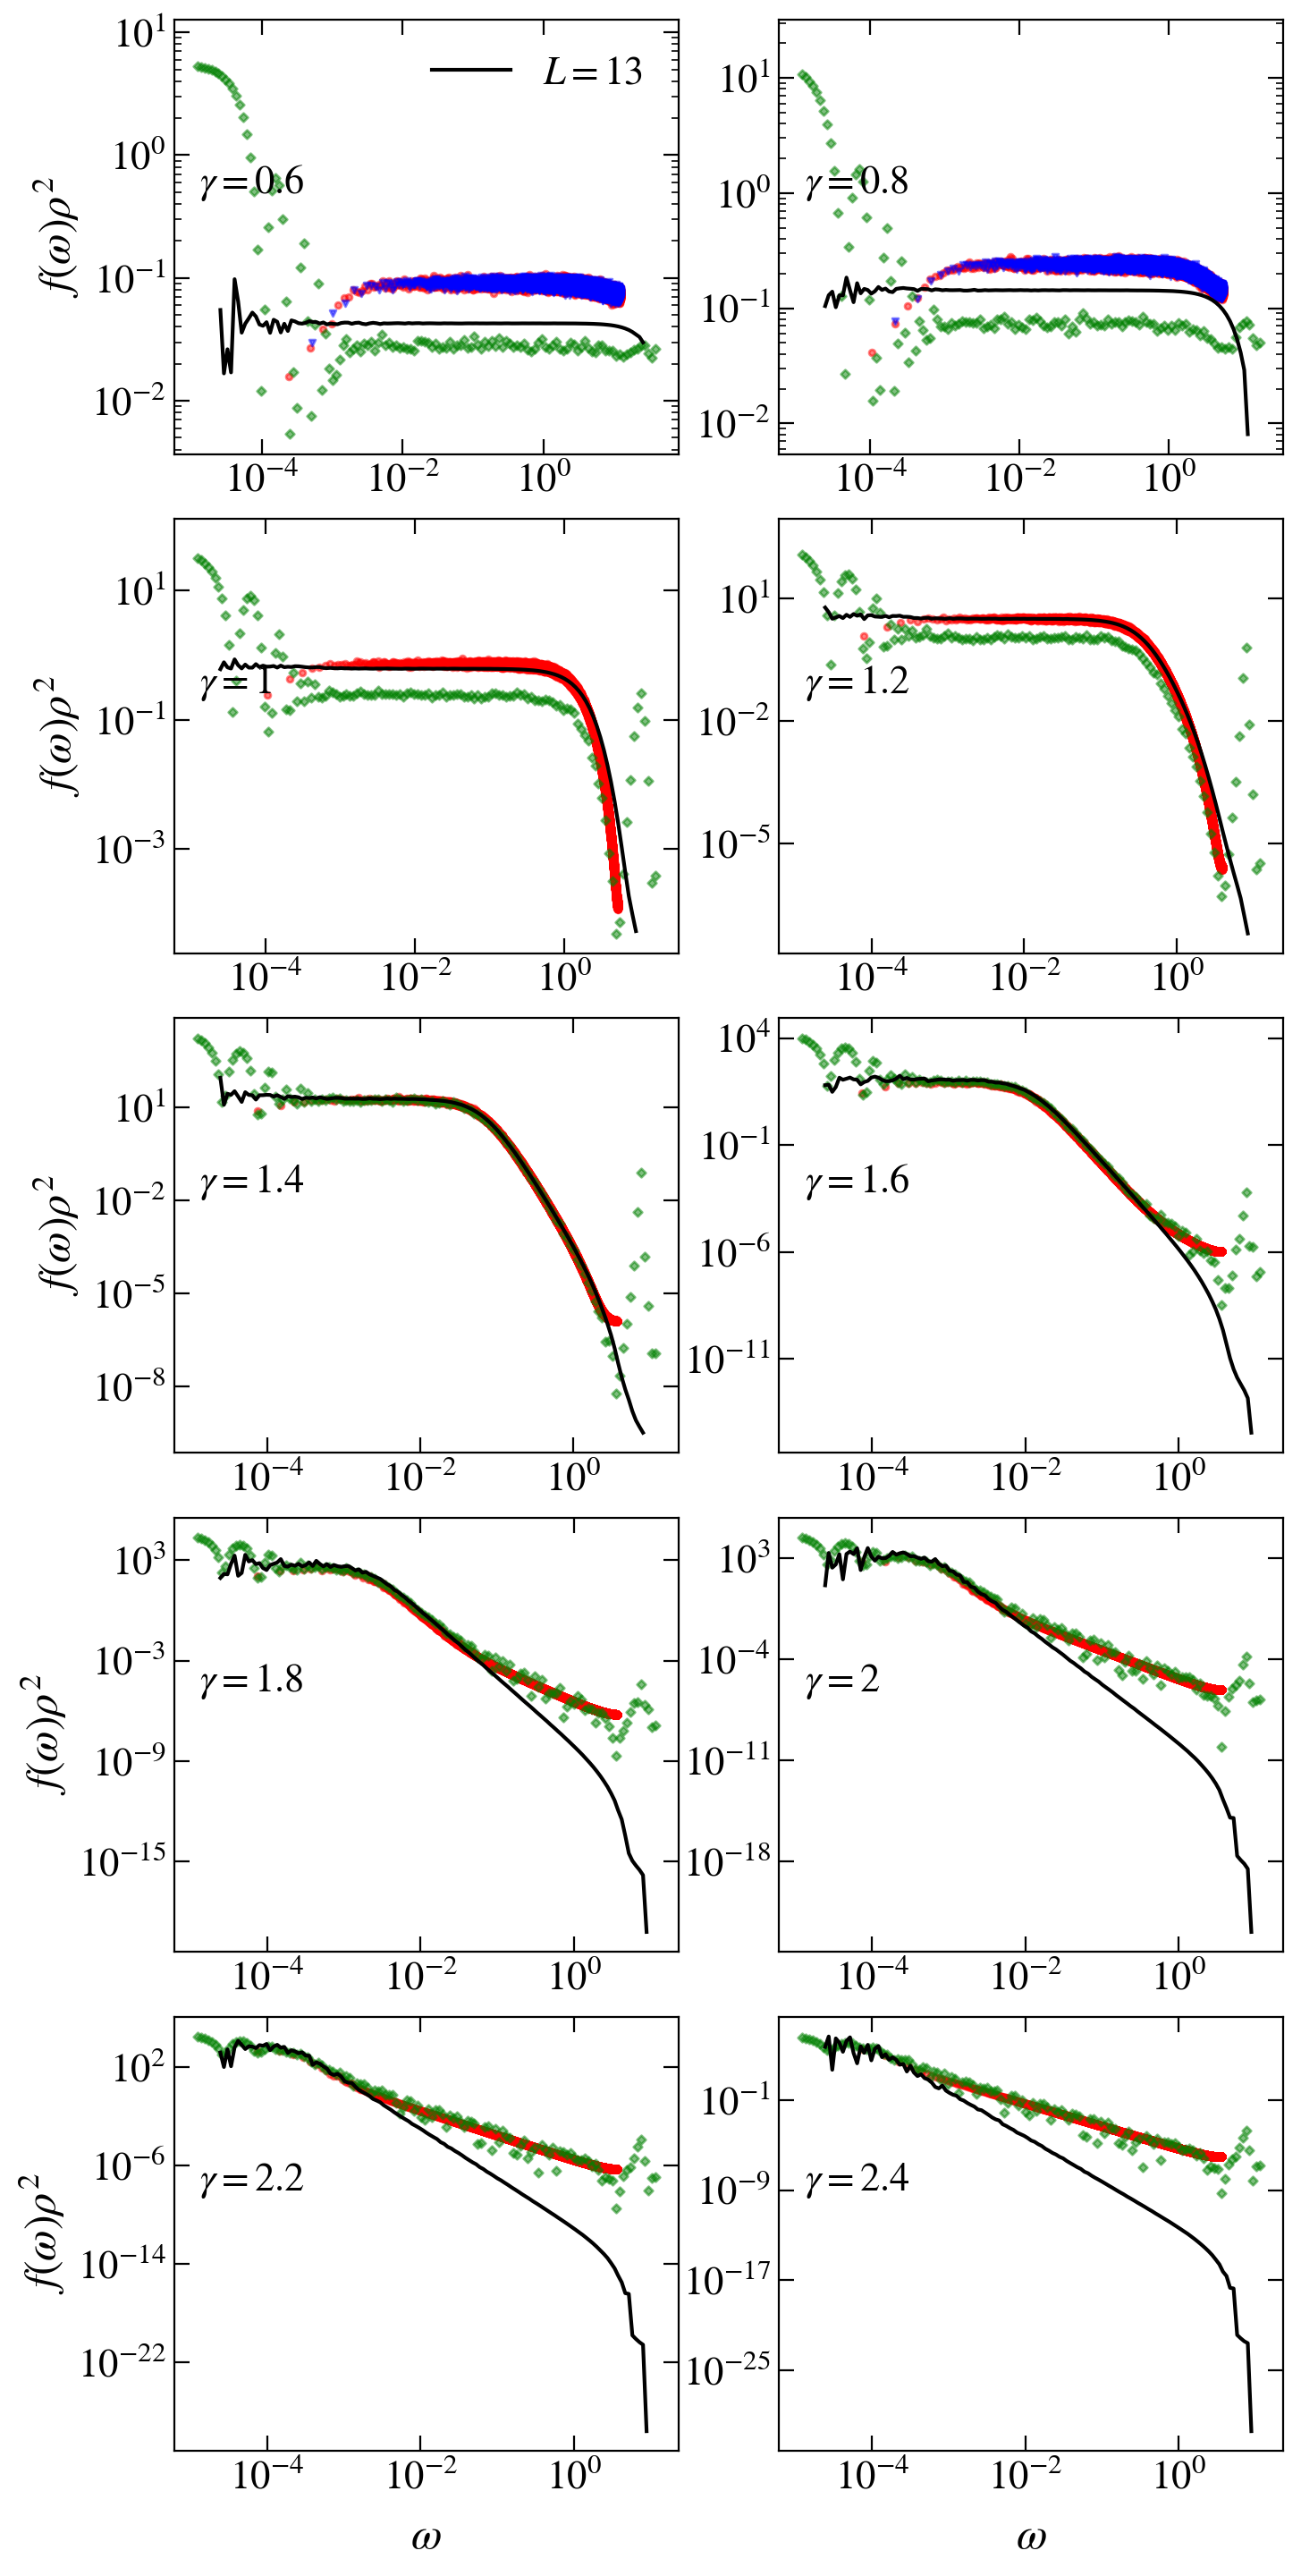

In [356]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'GOE/Quench/Fourier_test2/'

sizes = np.arange(13, 14, 1)
gamas = np.arange(0.6, 2.51, 0.2)

DIM = 1

gx = 1.3
fig, axis = plt.subplots( nrows=5, ncols=2, figsize=(8,18), dpi = 200, sharex=False, sharey=False)
axis = axis.flatten()

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes)))
s_m.set_array([])

# gx = 1.
L = 13
window = 10

def lorenz(x, A, G1):
    return A / ( (x / G1)**2 + 1)

dim = 2**L


for iig, gx in enumerate(gamas):
    for L in sizes:
        dim = 2**L
        col = s_m.to_rgba(L)
        name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                Ex = np.array(file.get('energy_density'))
                wH_dens = np.array(file.get('wH_dens'))
                DOS = 1/wH_dens
                # print(DOS)
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - 0.5))
                
                
                omegax = np.array(file.get('omegas'))
                omegax = np.sqrt(omegax[1:] * omegax[:-1])[6:]
                spec_fun = np.array(file.get('spec_fun_all'))[6:] * max(DOS)
                
                # if gx <= 2.2:
                #     yy_int = integrate.cumulative_trapezoid(yy, xx)
                #     yy_int = (yy_int - yy_int[0]) / (yy_int[-1] - yy_int[0])
                #     idxG = np.argmin( np.abs(yy_int - 0.5) )
                #     G = xx[idxG]
                #     axis[iig].axvline(x=G, ls='-', lw=2, color=col, alpha=0.7)
      
                # K_EOA = np.array(file.get('K_EOA_all'))[0]
                K_EOA = np.array(file.get('K_EAO_all'))[6:] * max(DOS)
                
                # print(dim)
                # yy = K_EOA * spec_fun
                yy = np.array(file.get('power_spectrum_exact'))[6:] * max(DOS)**2
                omegas = omegax[~np.isnan(yy)]
                yy = yy[~np.isnan(yy)]
                inte = np.trapz(yy, omegas)
                yy = yy / inte
                if iig==0:               axis[iig].plot(omegas, yy, color='k', ls='-', alpha=1, label = r'$L=%d$'%L)
                elif iig==3 and L == 10: axis[iig].plot(omegas, yy, color='k', ls='-', alpha=1, label = r'$\mathcal{O}^2(\omega)K(\omega)$')
                else:                    axis[iig].plot(omegas, yy, color='k', ls='-', alpha=1, label = '')
                                
                # power_spectrum = np.array(file.get('power_spectrum_exact'))[6:] * max(DOS)**2
                omegax = 2*np.pi*np.array(file.get('frequency'))
                power_spectrum = np.array(file.get('power spectrum')) * max(DOS)**2
                # power_spectrum = np.array(file.get('fourier series')) * max(DOS)**2
                omegas = omegax[~np.isnan(power_spectrum)]
                power_spectrum = power_spectrum[~np.isnan(power_spectrum)]
                inte = np.trapz(power_spectrum, omegas)
                power_spectrum = power_spectrum/inte
                axis[iig].scatter(omegas, power_spectrum, color='red', marker='o', s=6, alpha=0.5, label = r'$\mathcal{S}(\omega)$' if iig==2 and L == 12 else '', rasterized=True)
                
                omegax = 2*np.pi*np.array(file.get('frequency2'))
                power_spectrum = np.array(file.get('power spectrum2')) * max(DOS)**2
                # print(omegax.shape, power_spectrum.shape)
                # power_spectrum = np.array(file.get('fourier series2')) * max(DOS)**2
                omegas = omegax[~np.isnan(power_spectrum)]
                power_spectrum = power_spectrum[~np.isnan(power_spectrum)]
                inte = np.trapz(power_spectrum, omegas)
                power_spectrum = power_spectrum/inte
                axis[iig].scatter(omegas, power_spectrum, color='blue', marker='v', s=6, alpha=0.5, label = r'$\mathcal{S}_2(\omega)$' if iig==2 and L == 12 else '', rasterized=True)
                
                omegax = np.array(file.get('omegas'))
                power_spectrum = np.array(file.get('fourier_integral'))**2 * max(DOS)**2
                # # power_spectrum = np.array(file.get('fourier series2'))[::2] * max(DOS)**2
                omegas = omegax[~np.isnan(power_spectrum)]
                power_spectrum = power_spectrum[~np.isnan(power_spectrum)]
                inte = np.trapz(power_spectrum, omegas)
                power_spectrum = power_spectrum/inte
                axis[iig].scatter(omegas, power_spectrum, color='green', marker='D', s=6, alpha=0.5, label = r'$\mathcal{S}_3(\omega)$' if iig==2 and L == 12 else '', rasterized=True)
                
                omeg_spec = omegax
        else:
            print(name_out)
           
        fig_help.set_plot_elements(axis[iig], ylabel=r"$f(\omega)\rho^2$" if iig%2 == 0 else '', xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')
        axis[iig].annotate(r"$\gamma=%g$"%gx, fontsize=16, xy=(0.05, 0.6), xycoords='axes fraction')    
    

fig.subplots_adjust(wspace = 0.2, hspace=0.15)
# fig.savefig("PLOTS_FADING/ANOMALOUS/Fig6.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


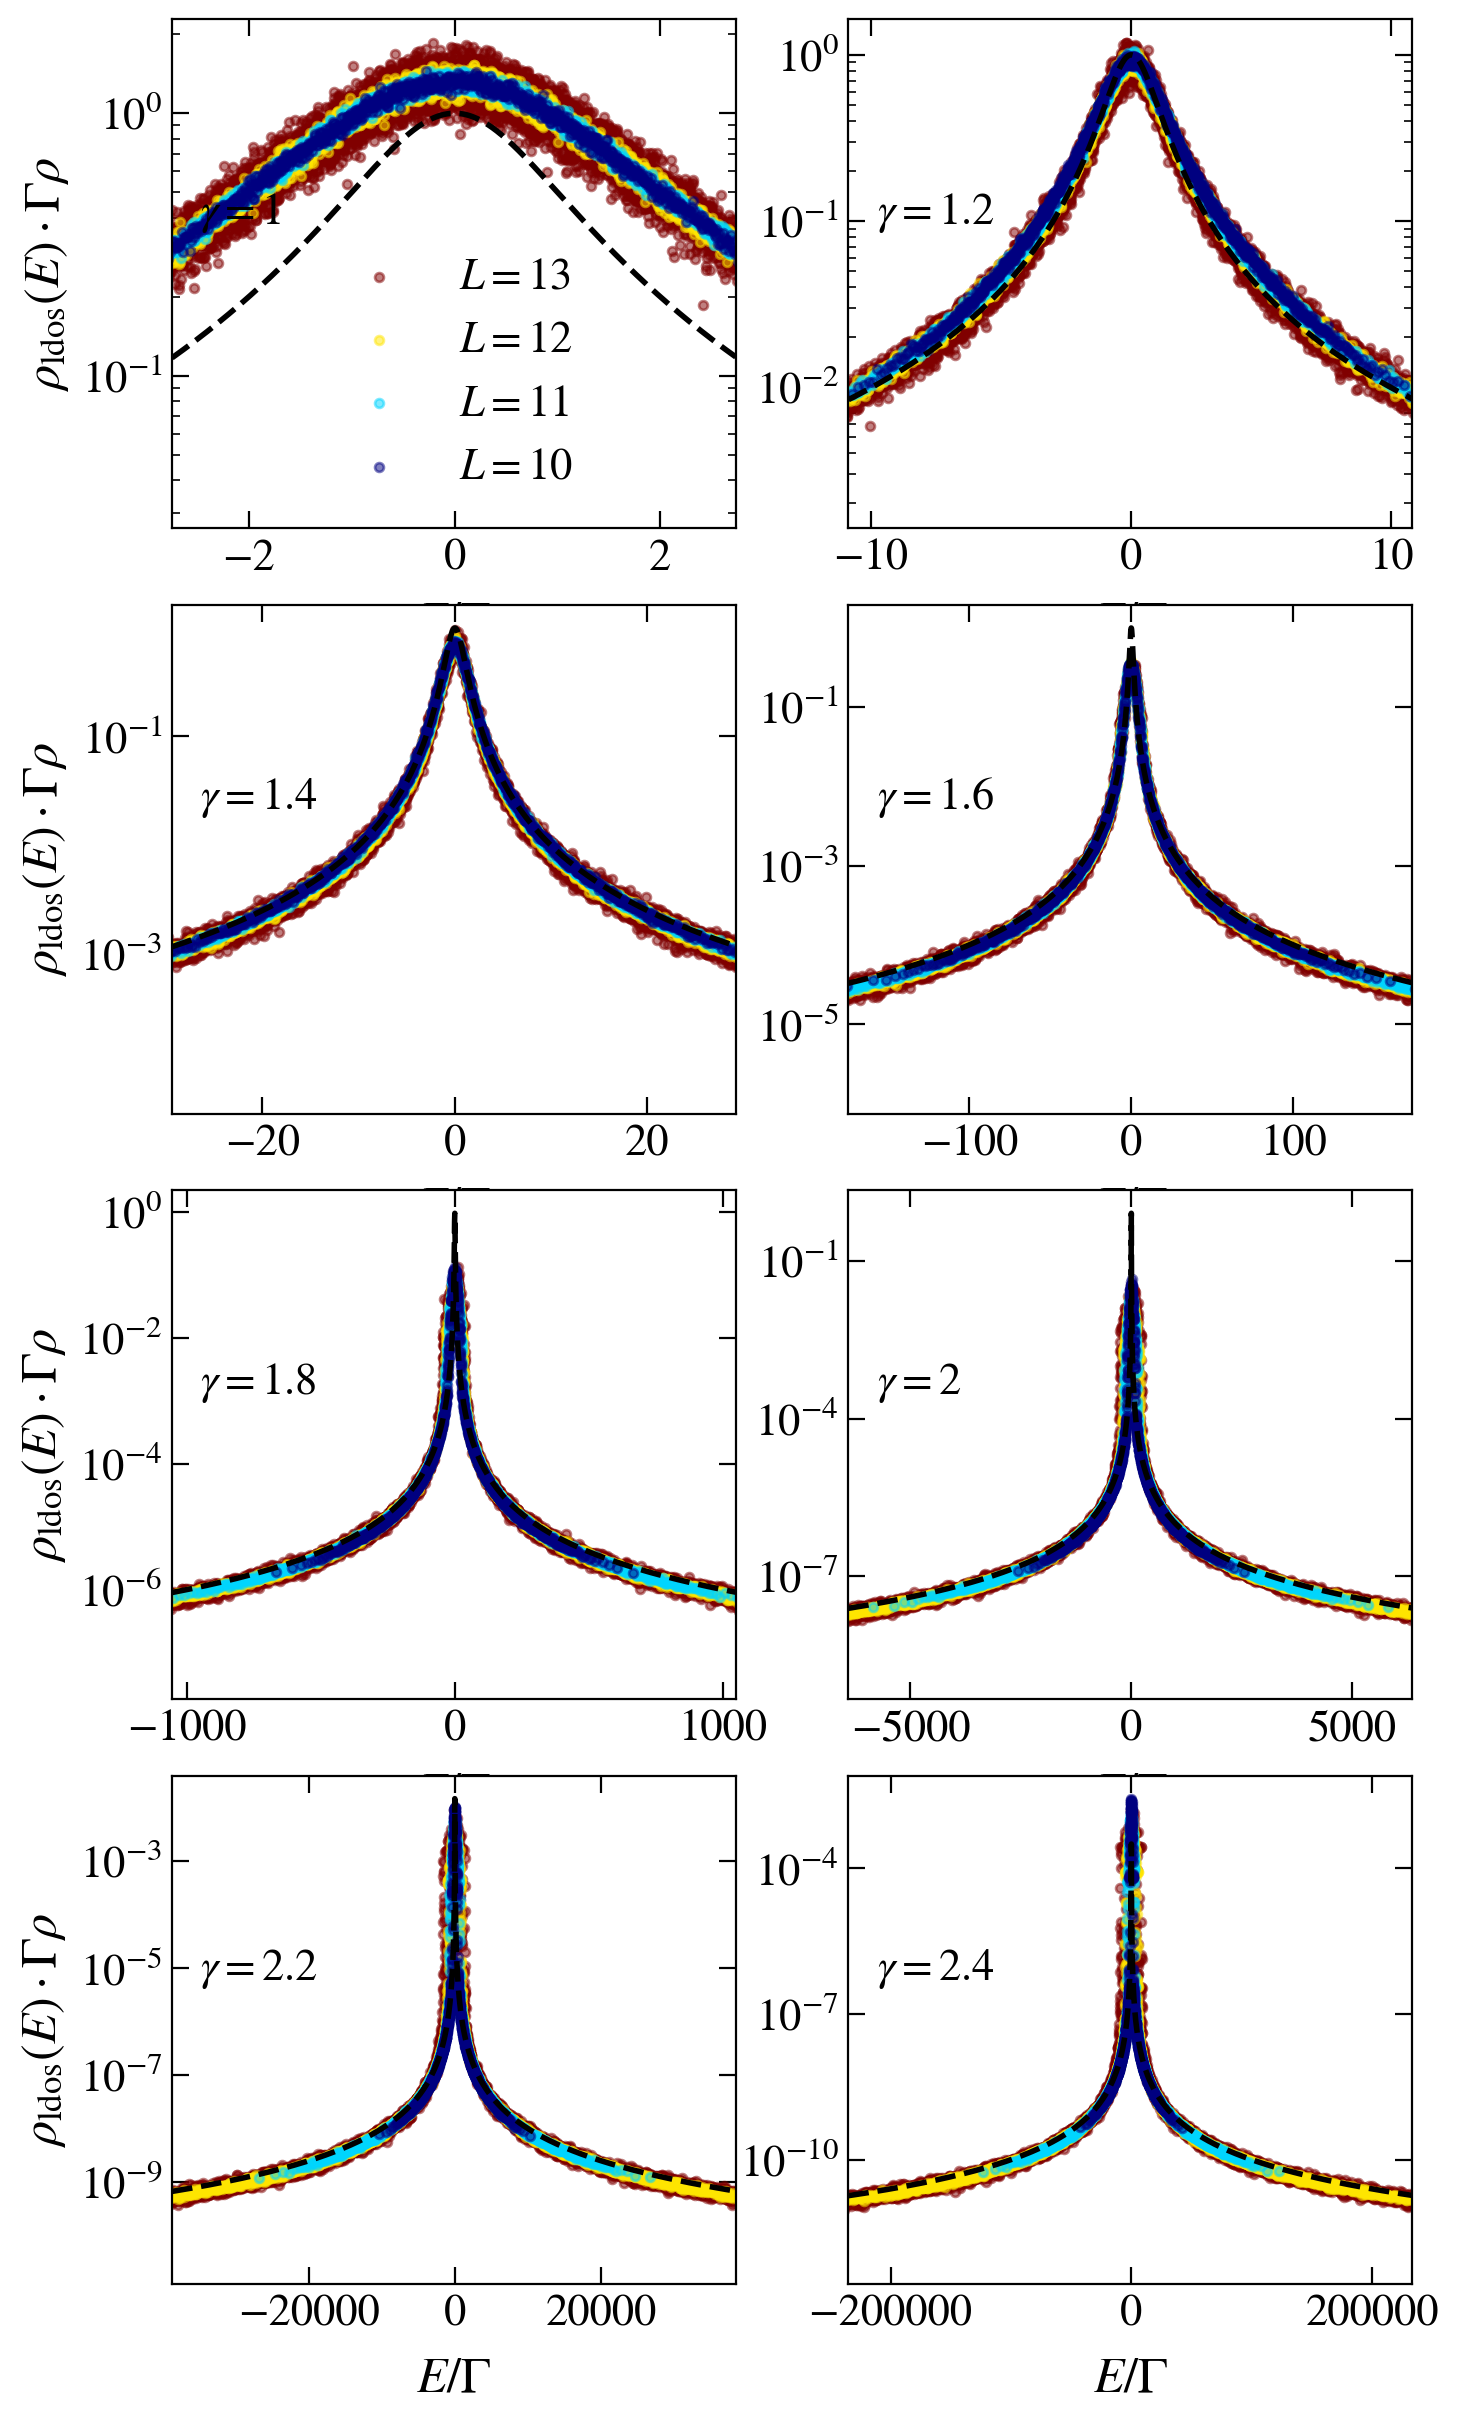

In [71]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'GOE/Quench/Fourier_test/'

sizes = np.arange(10, 14, 1)
gamas = np.arange(1.0, 2.51, 0.2)

DIM = 1

gx = 1.3
fig, axis = plt.subplots( nrows=4, ncols=2, figsize=(8,15), dpi = 200, sharex=False, sharey=False)
axis = axis.flatten()

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes)))
s_m.set_array([])

# gx = 1.
L = 14
window = 10

def lorenz(x, A, G1):
    return A / ( (x / G1)**2 + 1)

dim = 2**L


for iig, gx in enumerate(gamas):
    for L in sizes[::-1]:
        dim = 2**L
        col = s_m.to_rgba(L)
        name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                Ex = np.array(file.get('energy_density'))
                wH_dens = np.array(file.get('wH_dens'))
                DOS = 1/wH_dens
                # print(DOS)
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - 0.5))
                
                G = np.pi * dim**(-gx) * (dim+1) * max(DOS) / dim
                E = np.array(file.get('E')) / G
                LDOS = np.array(file.get('Cn^2')) * G * dim# * max(DOS)
                
                if iig==0: axis[iig].scatter(E, LDOS, color=col, marker='o', s=10, alpha=0.5, label = r'$L=%d$'%L)
                else:      axis[iig].scatter(E, LDOS, color=col, marker='o', s=10, alpha=0.5, label = '')
                
        else:
            print(name_out)
        if L == max(sizes): 
            if gx > 1.2:    axis[iig].set_xlim(min(E)/4, max(E)/4)
            else:           axis[iig].set_xlim(min(E)/2, max(E)/2)
            z = np.linspace(min(E), max(E), 10000)
            G = 1#0.05
            yy = G / 1 / ( z**2 + G**2)
            axis[iig].plot(z, yy, ls='--', color='k', lw=2)
    fig_help.set_plot_elements(axis[iig], ylabel=r"$\rho_{\rm ldos}(E)\cdot\Gamma\rho$" if iig%2 == 0 else '', xlabel=r"$E/\Gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')
    axis[iig].annotate(r"$\gamma=%g$"%gx, fontsize=16, xy=(0.05, 0.6), xycoords='axes fraction')    
    

fig.subplots_adjust(wspace = 0.2, hspace=0.15)
# fig.savefig("PLOTS_FADING/ANOMALOUS/Fig6.pdf", bbox_inches = 'tight', pad_inches=0.02)

25250.43974069176 25734.35636567686 |||| 7.599221861028428 7.376805298788401


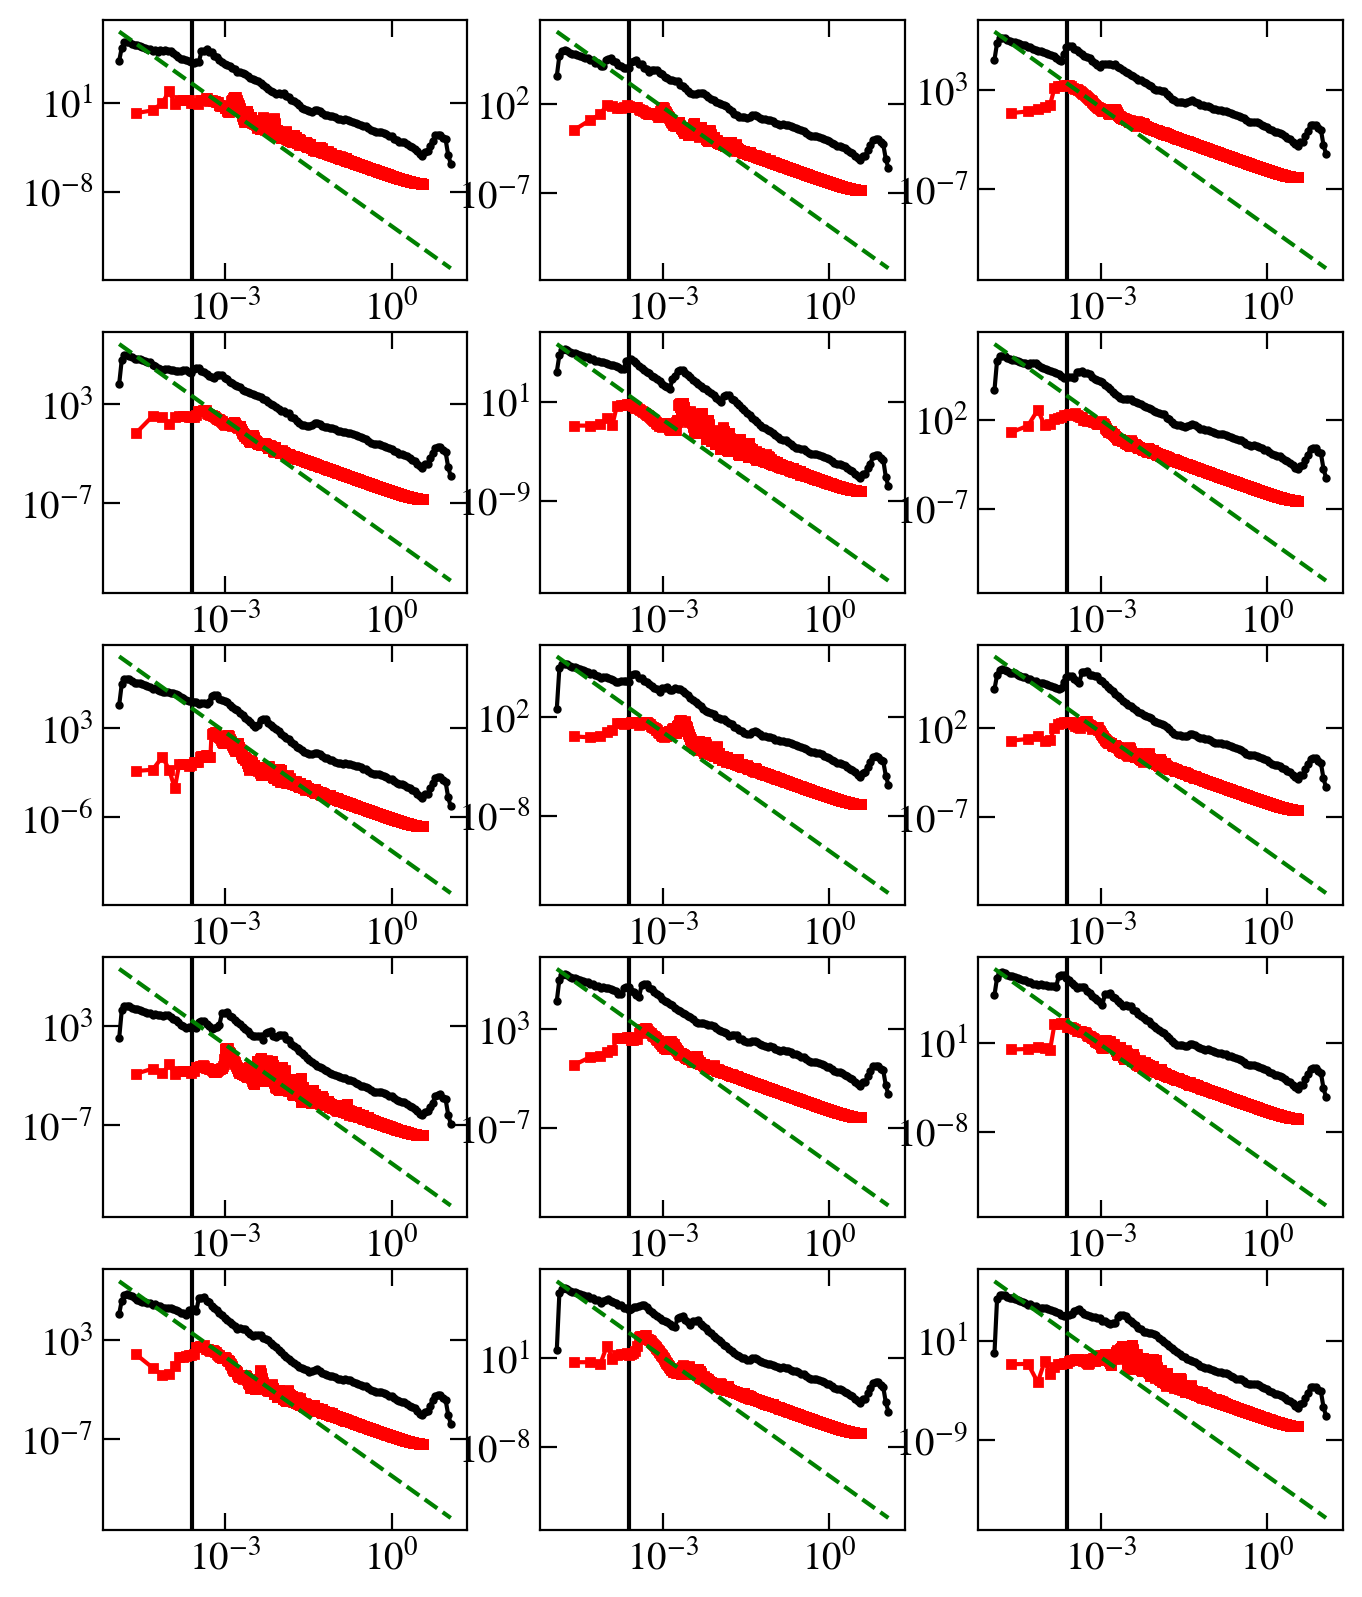

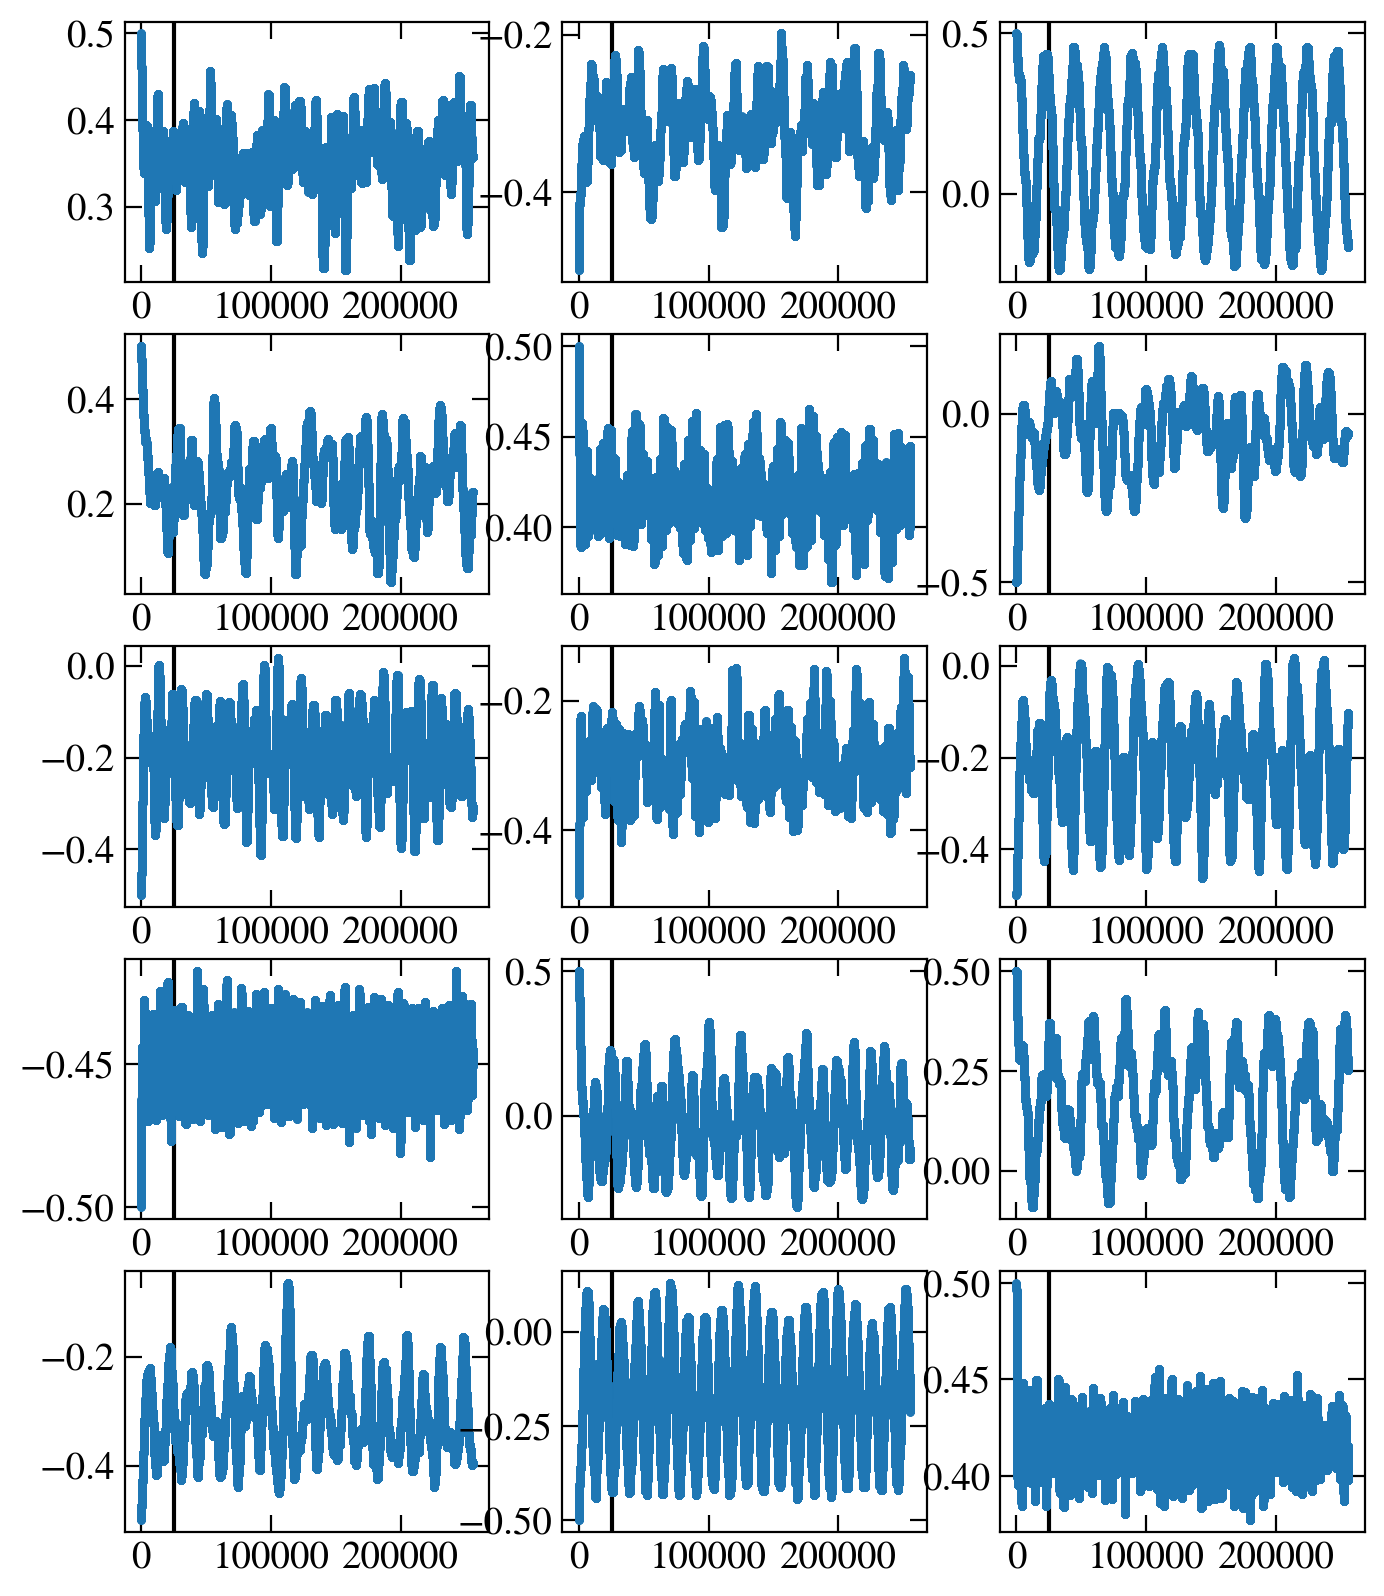

In [7]:
colors_ls_cyc = itertools.cycle(colors_ls)
from scipy import signal
from numpy.fft import *


L = 13
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'GOE/Quench/Fourier/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(1.0, 2.9, 0.2)
# from scipy.signal.windows import blackman
# w = blackman(N)

DIM = 1

nrows = 5
fig, axis = plt.subplots( nrows=nrows, ncols=3, figsize=(8,2*nrows), dpi = 200)
axis = axis.flatten()

fig_raw, axis_raw = plt.subplots( nrows=nrows, ncols=3, figsize=(8,2*nrows), dpi = 200)
axis_raw = axis_raw.flatten()

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])

gx = 2
L = 13
dim = 2**L
name_out = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        dE = np.mean( np.array(file.get('bandwidth')) )
        wH = np.array(file.get('wH_typ'))[-2]
        tH = 2 * np.pi / wH
        
        e_max = e_max = ( np.sqrt(2 * np.log(dim)) - np.log(np.log(dim) * 4 * np.pi) / np.sqrt(2*np.log(dim)) / 2 ) * (np.sqrt(1 + dim**(1-gx)))
        dE_analytical = 2 * e_max if gx >= 1 else (4 * np.sqrt(1 + dim**(1-gx)))
        print(tH, 2 * np.pi * dim / (np.sqrt(1 + dim**(1-gx))) / 2, "||||", dE, dE_analytical)
else:
    print(name_out)
for ii, ax in enumerate(axis_raw):
    ax.axvline(x=tH, ls='-', color='k')
    axis[ii].axvline(x=wH, ls='-', color='k')
    
    
name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        times  = np.array(file.get('times'))
        T = times[1] - times[0]
        N = times.size
        # times = times[:N//2]
        
        t_idx = np.argmin(np.abs(times - tH / 2))
        # print(t_idx, tH, times[0])
        Q_raw  = np.array(file.get('quench data'))#[:, :t_idx]
        # times = times[:t_idx]
        N = times.size
        
        omegas  = np.array(file.get('omegas'))
        for ii, ax in enumerate(axis_raw):
            ax.plot(times, Q_raw[ii], lw=1, marker='o', markersize=2)
            
            xf = 2 * np.pi * fftfreq(N, T)[1:N//2]
            yf = np.abs( 2 / np.sqrt(N) * np.abs(fft(Q_raw[ii])[1:N//2]) )**2
            # xf, yf = signal.welch(Q_raw[ii], 1/T, scaling='spectrum', average='median')

            # print(T, times[-1] - times[0], np.min(xf))
            yf = tools.remove_fluctuations(yf, 10)
            axis[ii].plot(xf, yf, color='red', marker='s', markersize=3)
            
            # axis[ii].plot(xf, _resc_(xf, 1/xf**2, yf), ls='--', color='k')
            # axis[ii].plot(xf, _resc_(1/xf**1), ls=':', color='blue')
            pow_spec = np.zeros(omegas.shape)
            for iiw, w in enumerate(omegas):
                pow_spec[iiw] = np.trapz( np.exp(1j * w * times) * (Q_raw[ii] - np.mean(Q_raw[ii, :1000])), times)
            pow_spec = np.abs(pow_spec)**2
             
            pow_spec = tools.remove_fluctuations(pow_spec, 4)
            axis[ii].plot(omegas, pow_spec, color='k', marker='o', markersize=2)
            
            yy = 1/omegas**4
            idx = omegas.size//3
            axis[ii].plot(omegas, yy / yy[idx] * yf[idx], color='green', ls='--')
            
for ii, ax in enumerate(axis_raw):
    fig_help.set_plot_elements(ax, ylabel=r"", xlabel=r"", font_size=14, set_legend=0, xscale='linear', yscale='linear')
    fig_help.set_plot_elements(axis[ii], ylabel=r"", xlabel=r"", font_size=14, set_legend=0, xscale='log', yscale='log')
# fig_help.set_plot_elements(axis, ylabel=r"$f(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

25250.43974069176 25734.35636567686 |||| 7.599221861028428 7.376805298788401


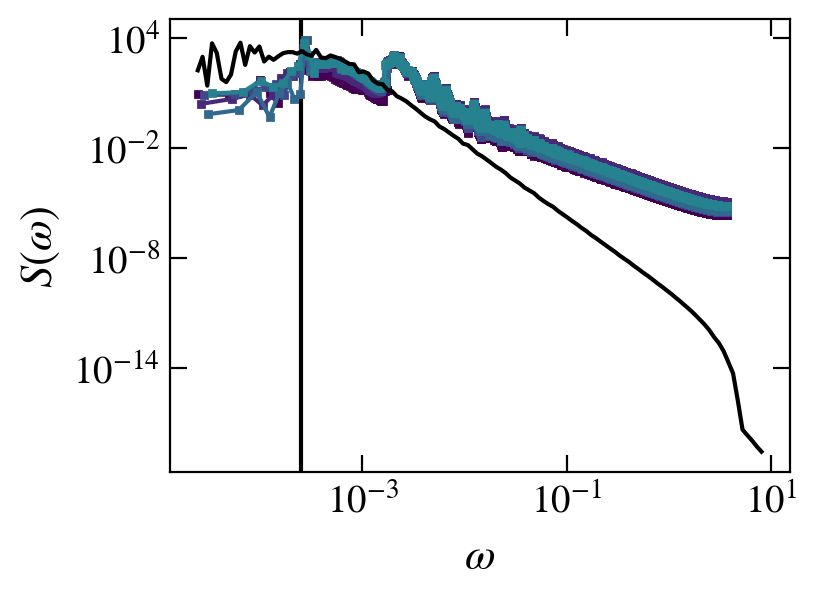

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)
# from scipy import signal
# from numpy.fft import *
from numpy.fft import rfft as fft
from numpy.fft import rfftfreq as fftfreq

L = 13
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'GOE/Quench/Fourier/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(1.0, 2.9, 0.2)
# from scipy.signal.windows import blackman
# w = blackman(N)

DIM = 1

nrows = 5
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200)

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=(1),
        vmax=(10)))
s_m.set_array([])

gx = 2
L = 13
dim = 2**L
name_out = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        dE = np.mean( np.array(file.get('bandwidth')) )
        wH = np.array(file.get('wH_typ'))[-2]
        tH = 2 * np.pi / wH
        
        e_max = e_max = ( np.sqrt(2 * np.log(dim)) - np.log(np.log(dim) * 4 * np.pi) / np.sqrt(2*np.log(dim)) / 2 ) * (np.sqrt(1 + dim**(1-gx)))
        dE_analytical = 2 * e_max if gx >= 1 else (4 * np.sqrt(1 + dim**(1-gx)))
        print(tH, 2 * np.pi * dim / (np.sqrt(1 + dim**(1-gx))) / 2, "||||", dE, dE_analytical)
else:
    print(name_out)

axis.axvline(x=wH, ls='-', color='k')
    
    
name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        
        for n in range(1, 6, 1):
            times  = np.array(file.get('times'))
            T = times[1] - times[0]
            N = times.size
            
            times = times[: N - 20000*int(n-1)]
            Q_raw  = np.array(file.get('quench data'))[4][: N - 20000*int(n-1)]
            N = times.size
            # T = times[1] - times[0]
            
            xf = 2 * np.pi * fftfreq(N, T)[1:]
            yf = np.abs( 2 / np.sqrt(N) * np.abs(fft(Q_raw))[1:] )**2
            inte = np.trapz(yf, xf)
            yf = tools.remove_fluctuations(yf, 20)
            axis.plot(xf, yf / inte, color=s_m.to_rgba(n), marker='s', markersize=2)
        
        omegax = np.array(file.get('omegas'))
        omegax = np.sqrt(omegax[1:] * omegax[:-1])[6:]
        yy = np.array(file.get('power_spectrum_exact'))[6:]
        omegas = omegax[~np.isnan(yy)]
        yy = yy[~np.isnan(yy)]
        inte = np.trapz(yy, omegas)
        axis.plot(omegas, yy / inte, color='k')
        
fig_help.set_plot_elements(axis, ylabel=r"$S(\omega)$", xlabel=r"$\omega$", font_size=14, set_legend=0, xscale='log', yscale='log')
# fig_help.set_plot_elements(axis, ylabel=r"$f(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles wi

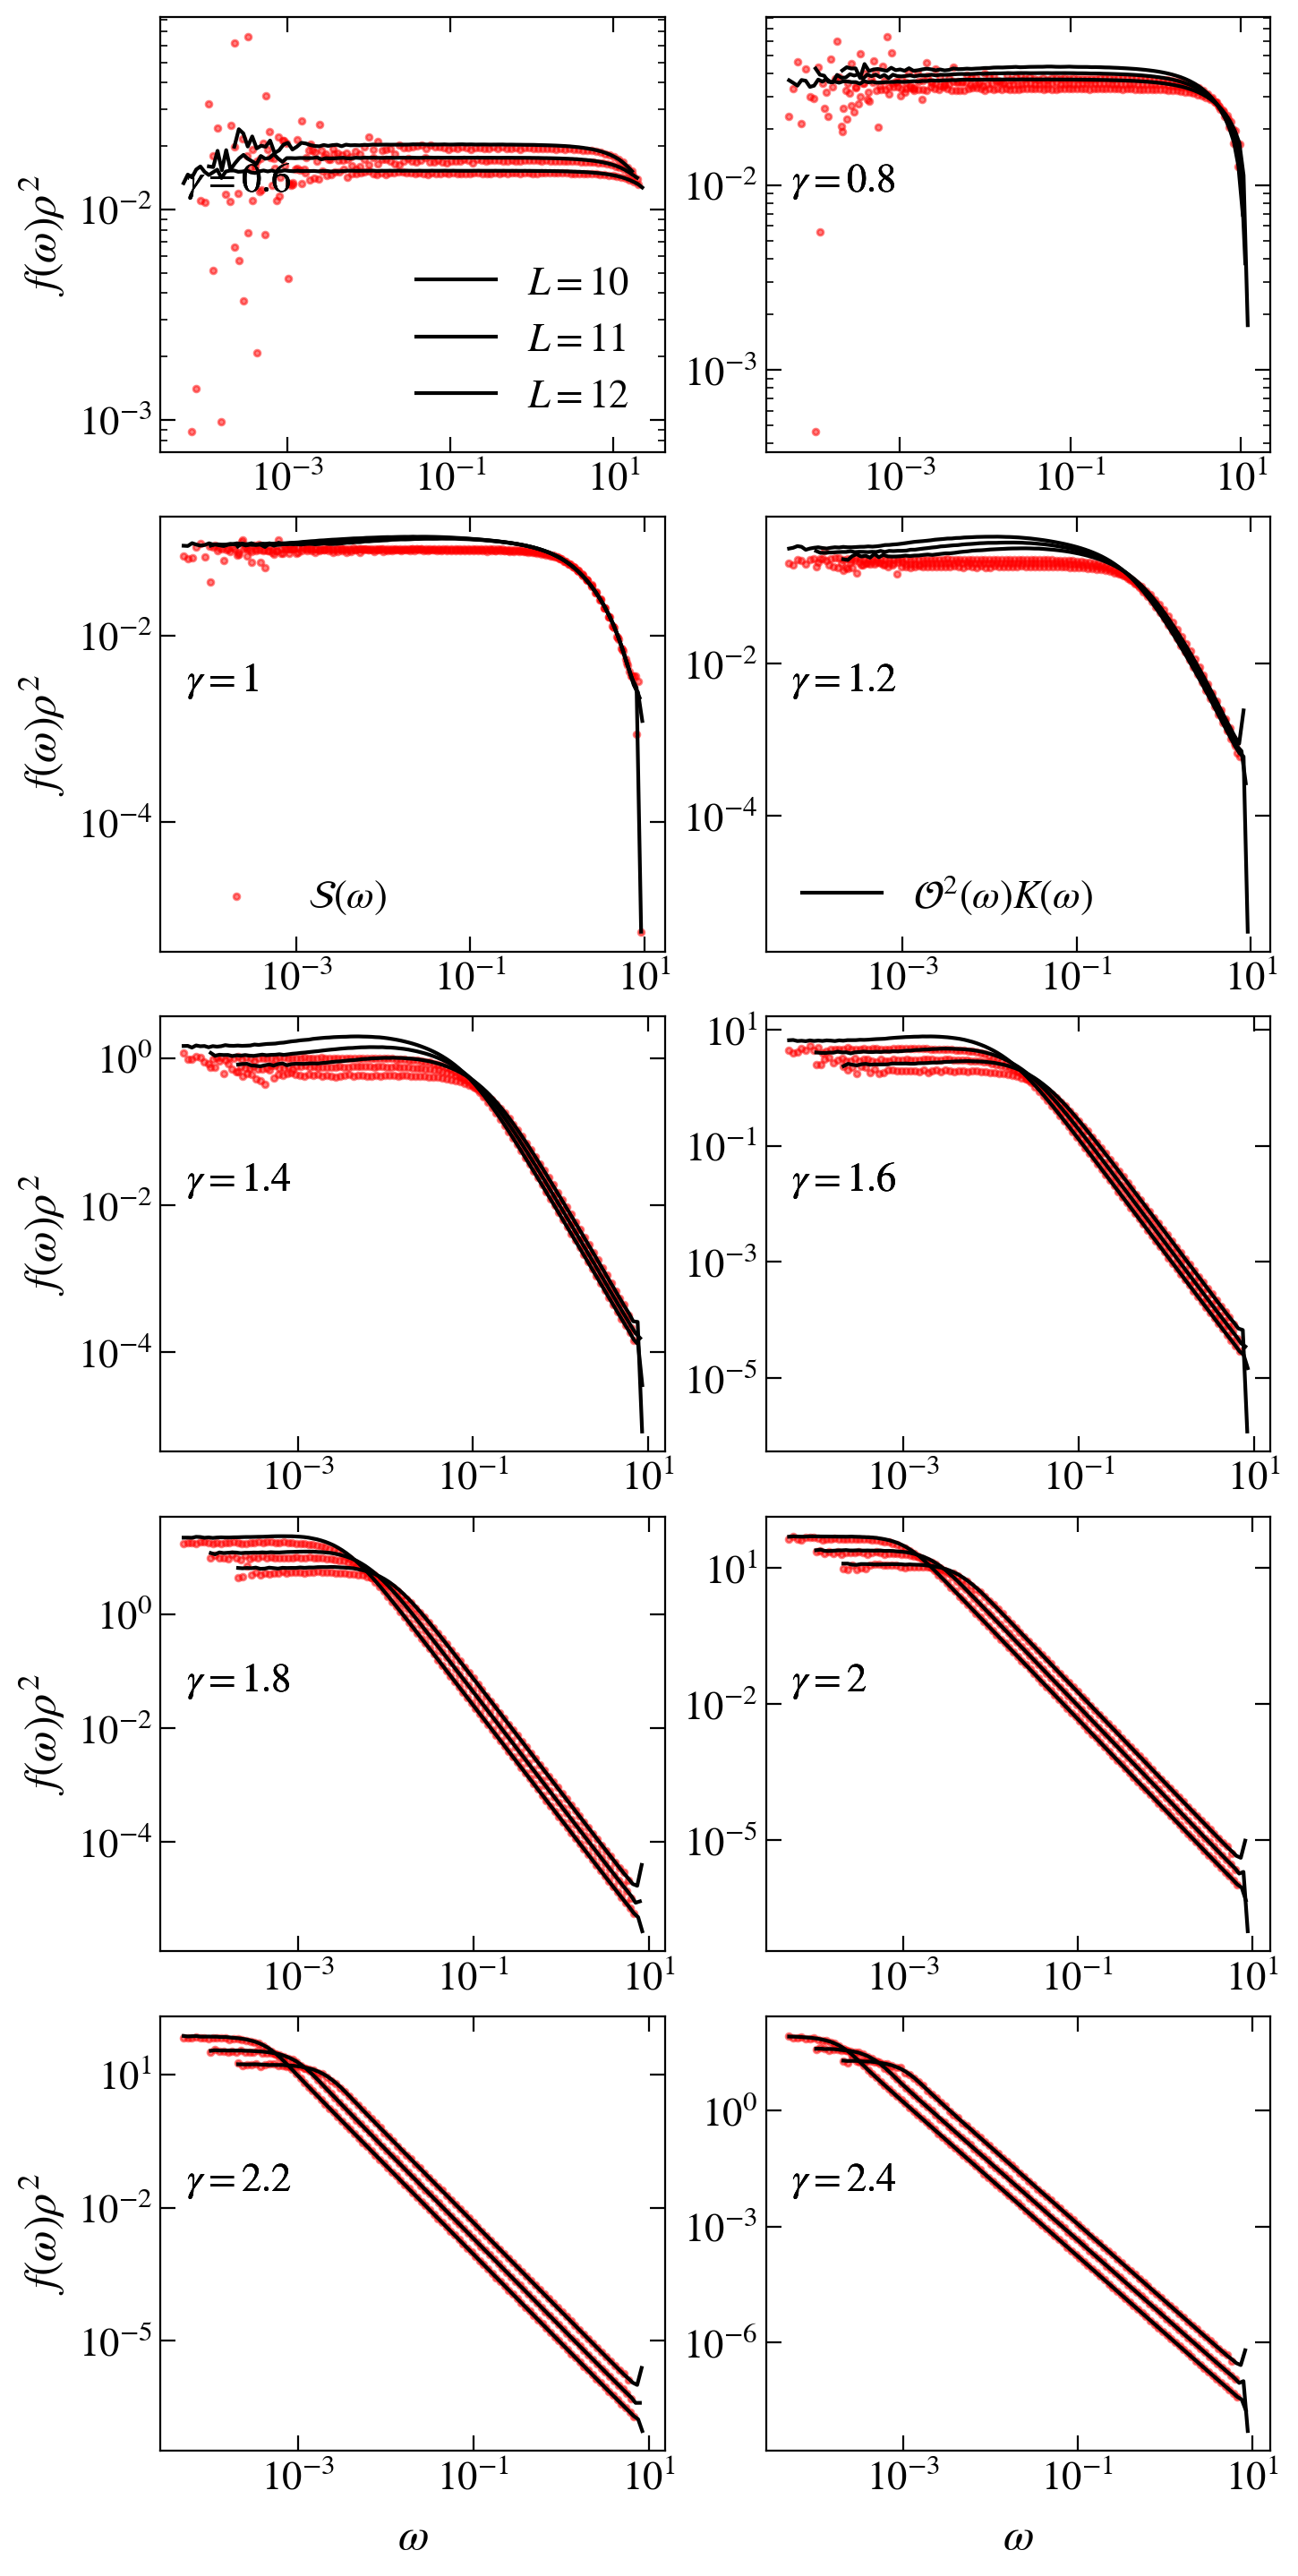

In [205]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'GOE/Quench/Fourier_test2/'

sizes = np.arange(10, 13, 1)
gamas = np.arange(0.6, 2.51, 0.2)

DIM = 1

gx = 1.3
fig, axis = plt.subplots( nrows=5, ncols=2, figsize=(8,18), dpi = 200, sharex=False, sharey=False)
axis = axis.flatten()

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes)))
s_m.set_array([])

# gx = 1.
L = 13
window = 10

def lorenz(x, A, G1):
    return A / ( (x / G1)**2 + 1)

dim = 2**L


for iig, gx in enumerate(gamas):
    for L in sizes:
        dim = 2**L
        col = s_m.to_rgba(L)
        name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                Ex = np.array(file.get('energy_density'))
                wH_dens = np.array(file.get('wH_dens'))
                DOS = 1/wH_dens
                # print(DOS)
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - 0.5))
                
                
                omegax = np.array(file.get('omegas'))
                omegax = np.sqrt(omegax[1:] * omegax[:-1])[6:]
                spec_fun = np.array(file.get('spec_fun_all'))[6:] * max(DOS)
                # yy = spec_fun
                # omegas = omegax[~np.isnan(yy)]
                # yy = yy[~np.isnan(yy)]
                # inte = np.trapz(yy, omegas)
                # yy = yy / inte
                if iig==0:               axis[iig].plot(omegax, spec_fun, color='k', ls='-', alpha=1, label = r'$L=%d$'%L)
                elif iig==3 and L == 10: axis[iig].plot(omegax, spec_fun, color='k', ls='-', alpha=1, label = r'$\mathcal{O}^2(\omega)K(\omega)$')
                else:                    axis[iig].plot(omegax, spec_fun, color='k', ls='-', alpha=1, label = '')
                
                spec_fun = np.array(file.get('spec_fun'))[idx][6:] * max(DOS)
                
                axis[iig].scatter(omegax, spec_fun, color='red', marker='o', s=6, alpha=0.5, label = r'$\mathcal{S}(\omega)$' if iig==2 and L == 12 else '', rasterized=True)
                
        else:
            print(name_out)
           
        fig_help.set_plot_elements(axis[iig], ylabel=r"$f(\omega)\rho^2$" if iig%2 == 0 else '', xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')
        axis[iig].annotate(r"$\gamma=%g$"%gx, fontsize=16, xy=(0.05, 0.6), xycoords='axes fraction')    
    

fig.subplots_adjust(wspace = 0.2, hspace=0.15)
# fig.savefig("PLOTS_FADING/ANOMALOUS/Fig6.pdf", bbox_inches = 'tight', pad_inches=0.02)

## FOURIER ANALYSIS

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles wi

./UM results/AA/uniform_01_08_um/alpha_0.54_ns_15_n_1.h5
./UM results/AA/uniform_01_08_um/alpha_0.60_ns_11_n_1.h5
./UM results/AA/uniform_01_08_um/alpha_0.60_ns_14_n_1.h5
./UM results/AA/uniform_01_08_um/alpha_0.60_ns_15_n_1.h5
./UM results/AA/uniform_01_08_um/alpha_0.68_ns_12_n_1.h5
./UM results/AA/uniform_01_08_um/alpha_0.68_ns_14_n_1.h5
./UM results/AA/uniform_01_08_um/alpha_0.68_ns_15_n_1.h5
./UM results/AA/uniform_01_08_um/alpha_0.72_ns_12_n_1.h5


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles wi

./UM results/AA/uniform_01_08_um/alpha_0.80_ns_14_n_1.h5
./UM results/AA/uniform_01_08_um/alpha_0.80_ns_15_n_1.h5
./UM results/AA/uniform_01_08_um/alpha_0.86_ns_14_n_1.h5
./UM results/AA/uniform_01_08_um/alpha_0.86_ns_15_n_1.h5
./UM results/AA/uniform_01_08_um/alpha_0.92_ns_14_n_1.h5


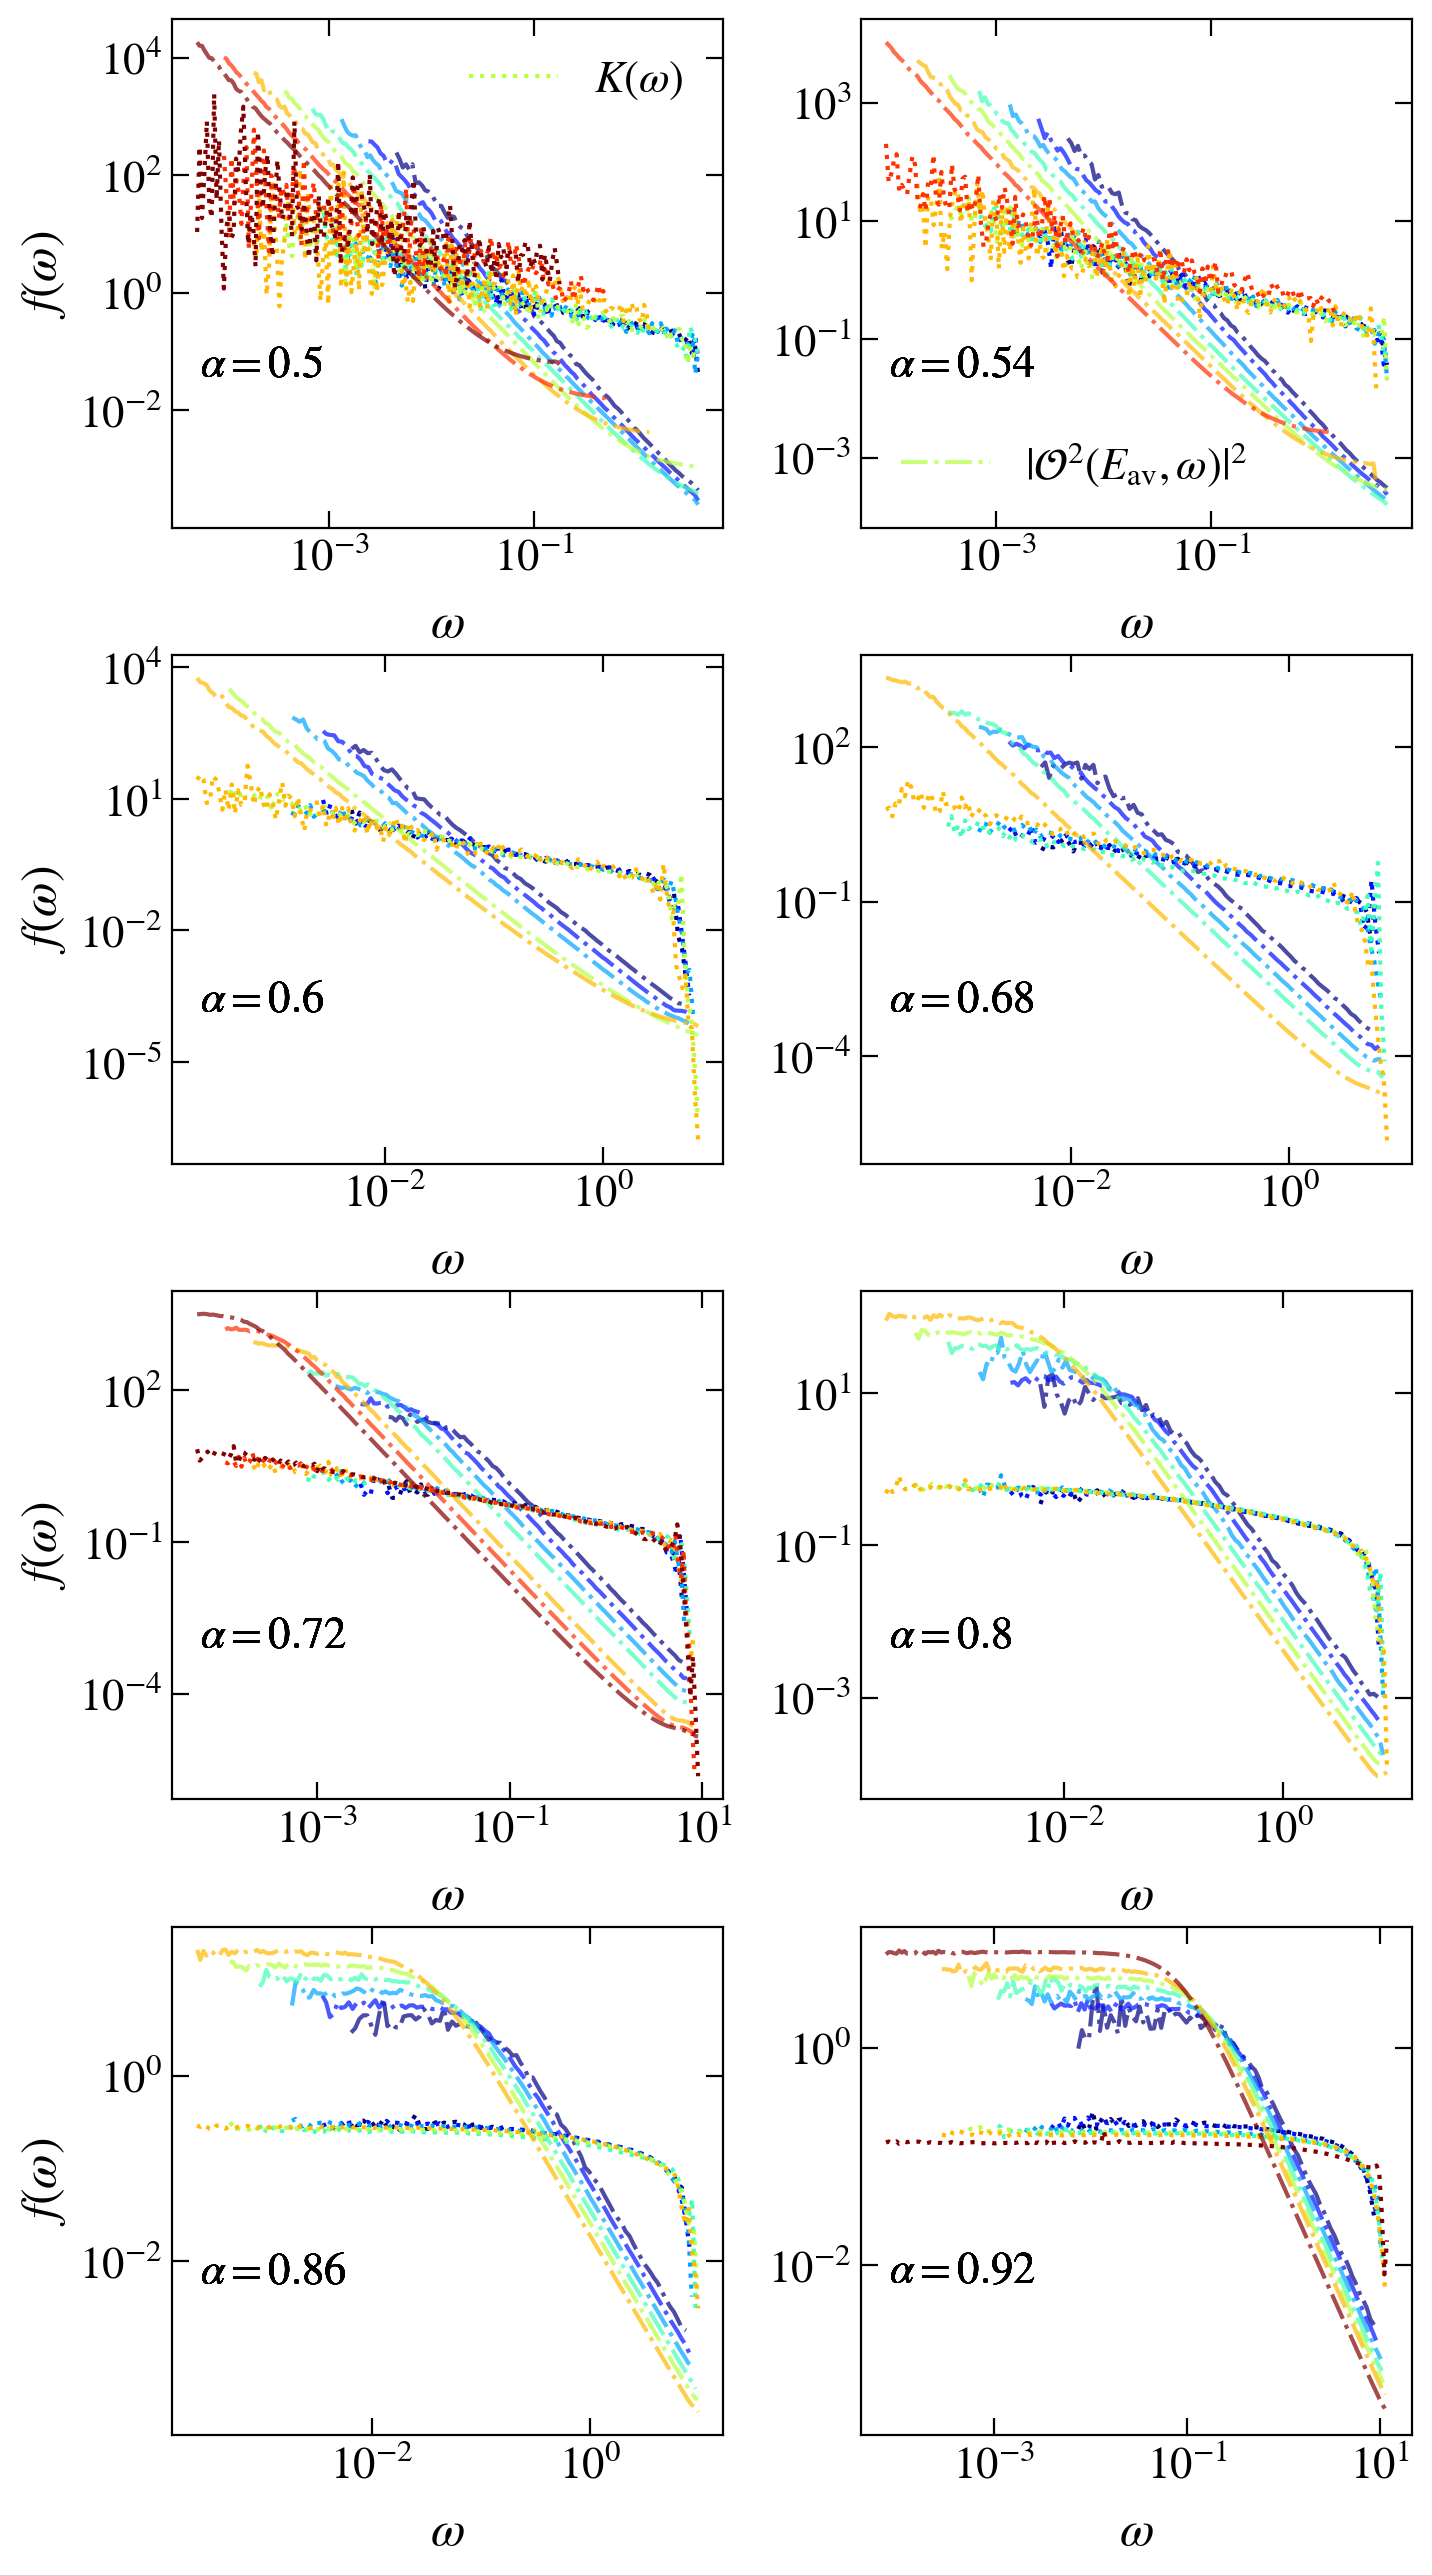

In [63]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
# prefix = './UM results/processed/'
prefix = './UM results/AA/uniform_01_08_um/'

sizes = np.arange(8, 16, 1)

alfas = [0.5, 0.54, 0.6, 0.68, 0.72, 0.80, 0.86, 0.92]

DIM = 1

fig, axis = plt.subplots( nrows=4, ncols=2, figsize=(8,16), dpi = 200, sharex=False, sharey=False)
axis = axis.flatten()

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes)))
s_m.set_array([])

# gx = 1.
L = 14
window = 10

def lorenz(x, A, G1):
    return A / ( (x / G1)**2 + 1)

dim = 2**L


for iia, alfa in enumerate(alfas):
    for L in sizes:
        dim = 2**L
        col = s_m.to_rgba(L)
        name_out = prefix + "alpha_%.2f_ns_%d_n_1.h5"%(alfa,L)
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                
                wH = np.array(file.get('stat/mean_lvl'))
                # sig  = np.sqrt( np.array(file.get('stat/var')) )
                dE  = ( np.array(file.get('stat/bw')) )
                
                omegax = np.array(file.get('O2/omegas'))[1:]
                # omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('O2/av/raw'))[1:]
                K_EOA = np.array(file.get('k/base'))
                # omegax2 = np.array(file.get('k02/omegas'))

                indices = np.where(np.logical_and(omegax >= wH/5, omegax < dE))[0]
                # xx = omegax
                # yy = spec_fun
                omegax = omegax[indices]
                spec_fun = spec_fun[indices]
                K_EOA = K_EOA[indices]
                omegax = omegax[~np.isnan(spec_fun)]
                K_EOA = K_EOA[~np.isnan(spec_fun)]
                spec_fun = spec_fun[~np.isnan(spec_fun)]
                
                inte = np.trapz(K_EOA, omegax)
                K_EOA = K_EOA / inte
                axis[iia].plot(omegax, K_EOA, color=col, ls=':', label = r'$K(\omega)$' if iia==0 and L == 12  else '')
                inte = np.trapz(spec_fun, omegax)
                spec_fun = spec_fun / inte
                axis[iia].plot(omegax, spec_fun, color=col, ls='-.', alpha=0.7, label = r'$|\mathcal{O}^2(E_{\rm av},\omega)|^2$' if iia==1 and L == 12 else '')
                # axis[iig].plot(omegax, np.abs(K_EOA / spec_fun), color=col, ls='-', label = r'$K(\omega)/|f(\omega)|^2$' if L==14 else '')
                # inte_spec = np.trapz(yy, omegax)
                # axis[iig].plot(omegax, yy / inte_spec, color='k', ls='--', label = r'$K(\omega)|f(\omega)|^2$' if iig==1 else '')
                
                omeg_spec = omegax
        else:
            print(name_out)
            
        fig_help.set_plot_elements(axis[iia], ylabel=r"$f(\omega)$" if iia%2 == 0 else '', xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')
        axis[iia].annotate(r"$\alpha=%g$"%alfa, fontsize=16, xy=(0.05, 0.3), xycoords='axes fraction')    
    

fig.subplots_adjust(wspace = 0.25, hspace=0.25)
# fig.savefig("PLOTS_FADING/ANOMALOUS/Fig6.pdf", bbox_inches = 'tight', pad_inches=0.02)

0.3805100996978581 100001
0.40278137871837316 100001
0.40631135521971373 100001
0.40682587330456954 100001


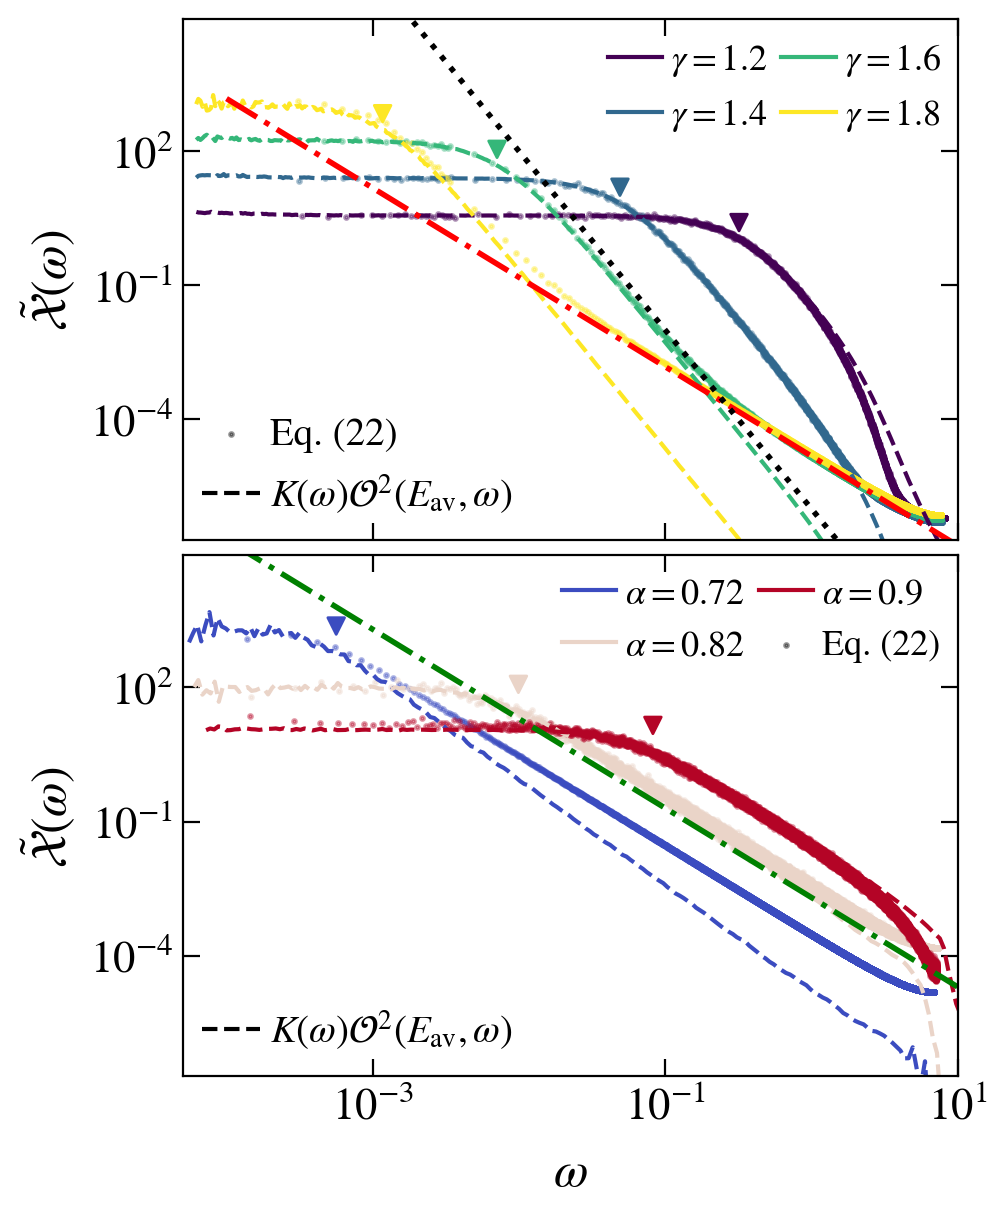

In [72]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(1.2, 1.81, 0.2)

DIM = 1
fig, axes = plt.subplots( nrows=2, ncols=1, figsize=(5,7), dpi = 200, sharex=True, sharey=True)
axis = axes[0]
axis2 = axes[1]

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])

gx = 1.5

L = 14

window = 50

def lorenz(x, A, G1):
    return A / ( (x / G1)**2 + 1)

handles = []
for gx in gammas:
    col = s_m.to_rgba(gx)
    dim = 2**L
    name_out = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - 0.5))
            wH = np.array(file.get('wH'))[-2]
            DOS = np.array(file.get('DOS'))
            
            omegax = np.array(file.get('omegas'))[100:-20]
            omegax = np.sqrt(omegax[1:] * omegax[:-1])
            spec_fun = np.array(file.get('spec_fun'))[idx, 100:-20]
            X = np.array(file.get('wH_typ_density'))[idx]
            cut = X
            # spec_fun = np.zeros(omegax.size)
            # element_count = np.zeros(omegax.size)
            # for ii in range(Ex.size):
            #     _grh_ = np.array(file.get('spec_fun'))[ii, 100:-20]
            #     _grh_elem = np.array(file.get('element_count'))[ii, 100:-20]
            #     # indices = np.argwhere(_grh_elem > 0)
            #     spec_fun += _grh_ * _grh_elem * DOS[ii]
            #     element_count += _grh_elem
            # # inte = np.trapz(spec_fun, omegax)
            # spec_fun = spec_fun / element_count
            # spec_fun = np.zeros(omegax.shape)
            # element_count = np.zeros(omegax.size)
            # for iiw in range(omegax.size):
            #     _grh_ = np.array(file.get('spec_fun'))[:, iiw]
            #     _grh_elem = np.array(file.get('element_count'))[:, iiw]
            #     indices = np.argwhere(~np.isnan(_grh_))
            #     # print(DOS[indices][:,0].shape, _grh_.shape)
            #     if len(indices) > 0:
            #         spec_fun[iiw] = np.trapz(DOS[indices][:,0] * _grh_[indices][:,0] * _grh_elem[indices][:,0], Ex[indices][:,0])
            #         element_count[iiw] = np.sum(_grh_elem[indices][:,0])
            
            # spec_fun = spec_fun / element_count
            
            indices = np.where(np.logical_and(omegax >= cut, omegax < 100))[0]
            xx = omegax
            yy = spec_fun
            # xx = xx[indices]
            # yy = yy[indices]
            xx = xx[~np.isnan(yy)]
            yy = yy[~np.isnan(yy)]
            
            # if gx <= 2.2:
            #     pars, pconv= fit(lorenz,
            #                 xdata = xx,
            #                 ydata = yy,
            #                 maxfev = 20000)
            #     z = np.logspace( np.log(min(xx)) + 4, np.log(max(xx))-2, 5000)
            #     # axis[iie].plot(z, lorenz(z, *pars), ls='--', color=col)
            #     G = np.abs(pars[-1])
            #     # axis.plot(omegax, spec_fun, color=col, ls=':')
            #     axis.axvline(x=G, ls='-', lw=2, color='gray', alpha=0.7)
            yy_int = integrate.cumulative_trapezoid(yy, xx)
            yy_int = (yy_int - yy_int[0]) / (yy_int[-1] - yy_int[0])
            idxG = np.argmin( np.abs(yy_int - 0.5) )
            G = xx[idxG]
            # axis.axvline(x=G, ls='-', lw=2, color=col, alpha=0.7)
            # axis.arrow(G, yy[idxG], 0, 0.01, color=col, linewidth=G/5, head_width=G/10)
    else:
        print(name_out)
    name_out = base_dir(model=modello, d=DIM) + 'GOE/K_EOA/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            Ex = np.array(file.get('energy_density'))[0]
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - 0.5))
            omegax = np.array(file.get('omegax'))[0][100:-20]
            omegax = np.sqrt(omegax[1:] * omegax[:-1])
            
            K_EOA = np.array(file.get('K_EOA_all'))[0][100:-20]
            # K_EOA = np.array(file.get('K_EOA'))[idx][100:-20]
            element_count = np.array(file.get('element_count_all'))[0][100:-20]
            
            omegax = omegax[~np.isnan(spec_fun)]
            K_EOA = K_EOA[~np.isnan(spec_fun)]
            spec_fun = spec_fun[~np.isnan(spec_fun)]
            
            omegax = omegax[~np.isnan(K_EOA)]
            spec_fun = spec_fun[~np.isnan(K_EOA)]
            K_EOA = K_EOA[~np.isnan(K_EOA)]
            
            spec_fun = spec_fun[omegax > 1/dim]
            K_EOA = K_EOA[omegax > 1/dim]
            omegax = omegax[omegax > 1/dim]
            
            yy = K_EOA * spec_fun
            inte = np.trapz(yy, omegax)
            # print(inte)
            # inte = np.mean(yy[:20])
            yy = yy / inte
            axis.plot(omegax, yy, color=col, ls='--', rasterized=True)
            
            idxG = np.argmin( np.abs(omegax - G) )
            opt = dict(color=col, 
                arrowstyle = 'simple,head_width=.75,head_length=.75',
                connectionstyle = 'arc3,rad=0')
            axis.annotate('',xy=(G, 1.5*yy[idxG]),xycoords='data',xytext =(G, 2.5*yy[idxG]),textcoords = 'data',arrowprops=opt,size=8)
            
            omeg_spec = omegax
    else:
        print(name_out)
    name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            times  = np.array(file.get('times'))
            T = times[1] - times[0]
            N = times.size
            print(times[1] - times[0], times.size)
            omegax  = 2 * np.pi * np.array(file.get('frequency'))[1:-100]
            power_spectrum  = np.array(file.get('fourier series'))[1:-100]**2 / T**2 / N/4# / N**0.5
            # power_spectrum  = np.array(file.get('power spectrum'))[1:] / T**2
            # power_spectrum  = np.array(file.get('power spectrum'))[1:]
            # power_spectrum = power_spectrum# * dim**(2-gx)
            # print(omegas.shape, power_spectrum.shape)
            # axis.axvline(x=wH, ls=':', color=col)
            power_spectrum = power_spectrum[omegax > wH]# * dim**(2-gx)
            omegax = omegax[omegax > wH]
            
            # long_time = np.mean(power_spectrum[-100:])
            # power_spectrum = (power_spectrum - long_time) / (power_spectrum[0] - long_time)
            
            
            
            # power_spectrum = tools.remove_fluctuations(power_spectrum, bucket_size=window)#[window//2:-window//2]
            # omegax = omegax[window//2:-window//2]
            # inte = np.mean(power_spectrum[:50])
            inte = np.trapz(power_spectrum, omegax)
            power_spectrum = power_spectrum / inte
            
            
            # res_omeg, ind1, ind2 = np.intersect1d(np.round(omeg_spec[:-20], 4), np.round(omegax[:-100], 4), return_indices=True)
            # y1 = power_spectrum[ind2]
            # y2 = yy[ind1]
            # idx = max( np.argwhere(np.abs(y2 / y1 - 1) < 0.25) )
            # # axis.axvline(x=res_omeg[idx], ls='--', color=s_m.to_rgba(gx), lw=2)
            # axis.scatter(res_omeg[idx], y1[idx], color=col, marker='s', s=40, facecolor='None')
            
            power_spectrum = np.array([*power_spectrum[:20], *power_spectrum[20::10]])
            omegax = np.array([*omegax[:20], *omegax[20::10]])
            axis.scatter(omegax, power_spectrum, color=col, s=2, alpha=0.4, rasterized=True)
            
            line, = axis.plot(np.nan, np.nan, color=col, ls='-', label = r'$\gamma=%g$'%gx)
            handles.append(line)
    else:
        print(name_out)
axis.set_ylim(1e-8, 2e4)
# axis.set_ylim(1e-19, 1e-3)
sc = axis.scatter(np.nan, np.nan, color='k', s=2, label = r'Eq. (22)', alpha=0.4)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', label = r'$K(\omega)\mathcal{O}^2(E_{\rm av},\omega)$')
handles.append(sc)
handles.append(line)

# cbar_ax = axis.inset_axes([1.01, 0.0, 0.02, 1])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
# cbar.set_label(r"$\gamma$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

# axis.set_title(r"$\gamma=%g$"%gx, fontsize=20)
fig_help.set_plot_elements(axis, ylabel=r"$\tilde{\mathcal{X}}(\omega)$", xlabel=r"", font_size=16, set_legend=1, xscale='log', yscale='log')
leg = fig_help.set_legend(axis, fontsize=14, loc='lower left', handles = handles[4:], columnspacing=0.6)
fig_help.set_legend(axis, fontsize=13, loc='upper right', handles = handles[:4], columnspacing=0.4, ncol=2)
fig.add_artist(leg)
axis.set_ylim(3e-8, 7e4)

z = np.logspace(-4, 1, 1000)
axis.plot(z, 1.5e-5/z**2, ls='-.', lw=2, color='red', alpha=1, rasterized=True)
axis.plot(z, 1e-6/z**4, ls=':', lw=2, color='k', alpha=1, rasterized=True)

axis = axis2
# prefix = './UM results/processed/'
prefix = './UM results/AA/uniform_01_08_um/'
sizes = np.arange(8, 14, 1)
# alfas = [0.68, 0.74, 0.8, 0.86]
alfas = [0.72, 0.82, 0.9]

s_m = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=matplotlib.colors.Normalize(
        vmin=min(alfas),
        vmax=max(alfas)))
s_m.set_array([])

# L = 12
dim = 2**L
handles = []
for iia, alfa in enumerate(alfas):
    
    dim = 2**L
    col = s_m.to_rgba(alfa)
    name_out = prefix + "alpha_%.2f_ns_%d_n_1.h5"%(alfa,L)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            
            wH = np.array(file.get('stat/mean_lvl'))
            # sig  = np.sqrt( np.array(file.get('stat/var')) )
            dE  = ( np.array(file.get('stat/bw')) )
            G  = ( np.array(file.get('stat/gamma_th')) )
            
            # omegax = np.array(file.get('O2/omegas'))[1:]
            # # omegax = np.sqrt(omegax[1:] * omegax[:-1])
            # spec_fun = np.array(file.get('O2/av/raw'))[1:]
            # K_EOA = np.array(file.get('k/base'))
            
            # # omegax2 = np.array(file.get('k02/omegas'))

            # indices = np.where(np.logical_and(omegax >= wH/10, omegax < dE))[0]
            # # xx = omegax
            # # yy = spec_fun
            # omegax = omegax[indices]
            # spec_fun = spec_fun[indices]
            # K_EOA = K_EOA[indices]
            # omegax = omegax[~np.isnan(spec_fun)]
            # K_EOA = K_EOA[~np.isnan(spec_fun)]
            # spec_fun = spec_fun[~np.isnan(spec_fun)]
            
            # yy = K_EOA * spec_fun
            # inte = np.trapz(yy, omegax)
            # yy = yy / inte
            # axis.plot(omegax, yy, color=col, ls='--')#, label = r'$K(\omega)\mathcal{O}^2(E_{\rm av},\omega)$' if iia==0 else '')
            
            omegax = np.array(file.get('kO2/omegas'))[1:]
            # omegax = np.sqrt(omegax[1:] * omegax[:-1])
            yy = np.array(file.get('kO2/av'))[1:]
            
            # omegax2 = np.array(file.get('k02/omegas'))

            indices = np.where(np.logical_and(omegax >= wH/10, omegax < dE))[0]
            omegax = omegax[indices]
            yy = yy[indices]
            inte = np.trapz(yy, omegax)
            yy = yy / inte
            axis.plot(omegax, yy, color=col, ls='--')#, label = r'$K(\omega)\mathcal{O}^2(E_{\rm av},\omega)$' if iia==0 else '')
            
            
            inte = np.array(file.get('fft/integral'))
            power = np.array(file.get('fft/s'))# / inte
            freq = np.array(file.get('fft/om'))
            inte = np.trapz(power, freq)
            
            # window = 20
            # power = tools.remove_fluctuations(power, bucket_size=window)[window//2:-window//2]
            # freq = f`req[window//2:-window//2]
            axis.scatter(freq, power / inte, color=col, alpha=0.4, s=2)#, label=r"Eq. (22)" if iia==0 else '')
            
            idxG = np.argmin( np.abs(omegax - G) )
            opt = dict(color=col, 
                arrowstyle = 'simple,head_width=.75,head_length=.75',
                connectionstyle = 'arc3,rad=0')
            axis.annotate('',xy=(G, 2.5*yy[idxG]),xycoords='data',xytext =(G, 4*yy[idxG]),textcoords = 'data',arrowprops=opt,size=8)
            
            line, = axis.plot(np.nan, np.nan, color=col, ls='-', label = r'$\alpha=%g$'%alfa)
            handles.append(line)
    else:
        print(name_out)

sc = axis.scatter(np.nan, np.nan, color='k', s=2, label = r'Eq. (22)', alpha=0.4)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', label = r'$K(\omega)\mathcal{O}^2(E_{\rm av},\omega)$')

handles.append(sc)
handles.append(line)

fig_help.set_plot_elements(axis, ylabel=r"$\tilde{\mathcal{X}}(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')
leg = fig_help.set_legend(axis, fontsize=14, loc='lower left', handles = handles[4:], columnspacing=0.6)
fig_help.set_legend(axis, fontsize=13, loc='upper right', handles = handles[:4], columnspacing=0.4, ncol=2)
fig.add_artist(leg)

z = np.logspace(-5, 1, 1000)
axis.plot(z, 2e-3/z**2, ls='-.', lw=2, color='green', alpha=1, rasterized=True)

axis.set_ylim(2e-7, 9e4)
axis.set_xlim(5e-5, 10)

# cbar_ax = axis.inset_axes([1.01, 0.0, 0.02, 1])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
# cbar.set_label(r"$\alpha$", fontsize=16)

fig.subplots_adjust(wspace = 0.03, hspace=0.03)
fig.savefig("PLOTS_FADING/ANOMALOUS/Fig5.pdf", bbox_inches = 'tight', pad_inches=0.02)
fig.savefig("PLOTS_FADING/ANOMALOUS/Fig5.png", bbox_inches = 'tight', pad_inches=0.02)

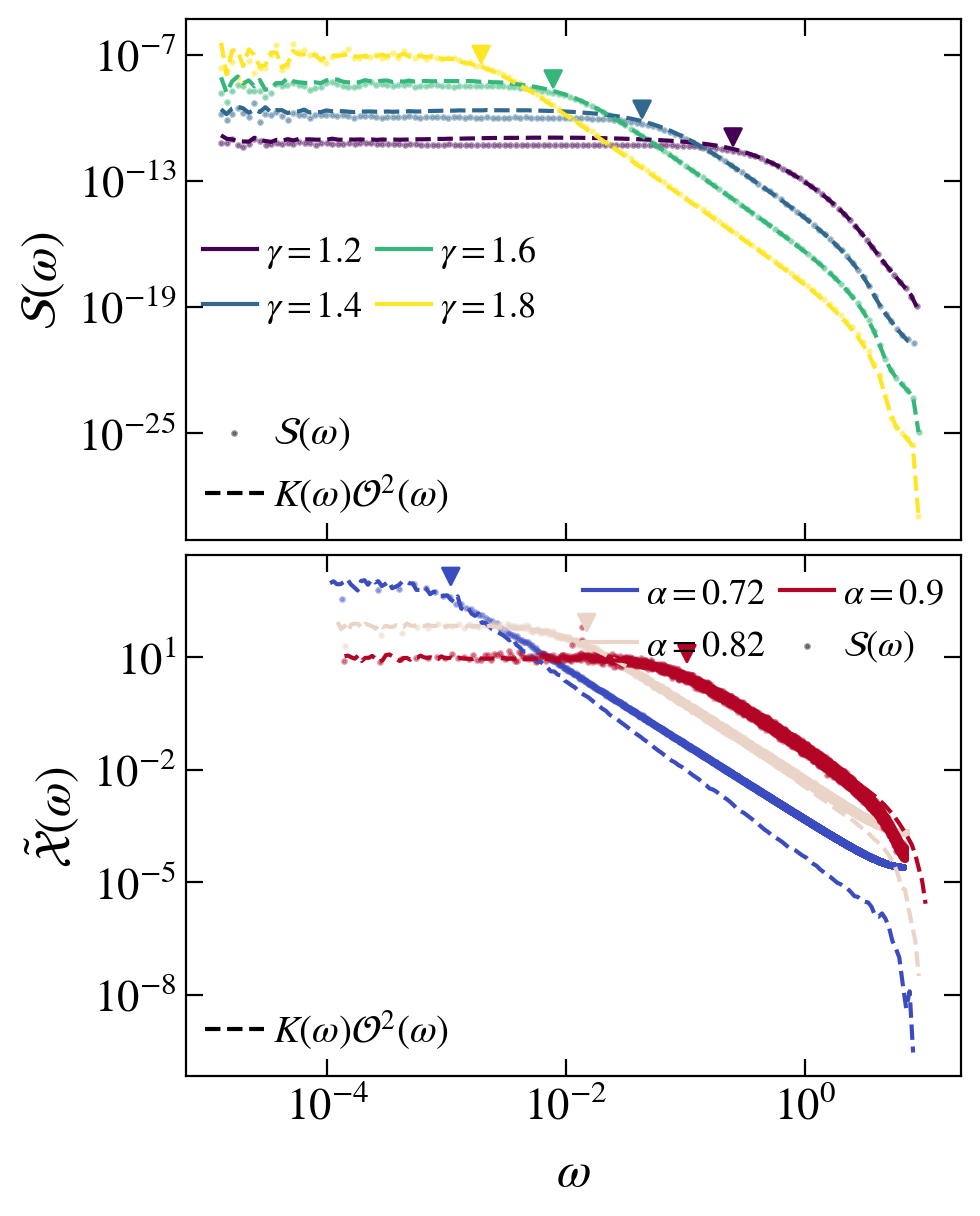

In [222]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'GOE/Quench/Fourier_test2/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(1.2, 1.81, 0.2)

DIM = 1
fig, axes = plt.subplots( nrows=2, ncols=1, figsize=(5,7), dpi = 200, sharex=True, sharey=False)
axis = axes[0]
axis2 = axes[1]

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])

gx = 1.5

L = 13

window = 50

def lorenz(x, A, G1):
    return A / ( (x / G1)**2 + 1)

handles = []
for gx in gammas:
    col = s_m.to_rgba(gx)
    dim = 2**L
    name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - 0.5))
            # wH = np.array(file.get('wH'))[-2]
            DOS = np.array(file.get('DOS'))
            
            omegax = np.array(file.get('omegas'))#[100:-20]
            omegax = np.sqrt(omegax[1:] * omegax[:-1])
            spec_fun = np.array(file.get('spec_fun_all'))#[100:-20]
            wH = np.array(file.get('wH_dens'))[idx]
            cut = wH
            
            indices = np.where(np.logical_and(omegax >= cut, omegax < 100))[0]
            xx = omegax
            yy = spec_fun
            xx = xx[indices]
            yy = yy[indices]
            xx = xx[~np.isnan(yy)]
            yy = yy[~np.isnan(yy)]
            
            yy_int = integrate.cumulative_trapezoid(yy, xx)
            yy_int = (yy_int - yy_int[0]) / (yy_int[-1] - yy_int[0])
            idxG = np.argmin( np.abs(yy_int - 0.5) )
            G = xx[idxG]
            
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - 0.5))
            omegax = np.array(file.get('omegas'))
            omegax = np.sqrt(omegax[1:] * omegax[:-1])
            
            K_EOA = np.array(file.get('K_EAO_all'))
            # K_EOA = np.array(file.get('K_EOA'))[idx][100:-20]
            element_count = np.array(file.get('element_count_all'))
            
            omegax = omegax[~np.isnan(spec_fun)]
            K_EOA = K_EOA[~np.isnan(spec_fun)]
            spec_fun = spec_fun[~np.isnan(spec_fun)]
            
            omegax = omegax[~np.isnan(K_EOA)]
            spec_fun = spec_fun[~np.isnan(K_EOA)]
            K_EOA = K_EOA[~np.isnan(K_EOA)]
            
            yy = K_EOA * spec_fun
            omegax = omegax[~np.isnan(yy)]
            yy = yy[~np.isnan(yy)]
            inte = np.trapz(yy, omegax)
            # yy = yy / inte
            axis.plot(omegax, yy, color=col, ls='--', rasterized=True)
            
            idxG = np.argmin( np.abs(omegax - G) )
            opt = dict(color=col, 
                arrowstyle = 'simple,head_width=.75,head_length=.75',
                connectionstyle = 'arc3,rad=0')
            axis.annotate('',xy=(G, 1.5*yy[idxG]),xycoords='data',xytext =(G, 2.5*yy[idxG]),textcoords = 'data',arrowprops=opt,size=8)
            
            omegax = np.array(file.get('omegas'))
            omegax = np.sqrt(omegax[1:] * omegax[:-1])
            yy = np.array(file.get('power_spectrum_exact'))
            
            # inte = np.trapz(power_spectrum, omegax)
            # power_spectrum = power_spectrum / inte
            
            # power_spectrum = np.array([*power_spectrum[:20], *power_spectrum[20::10]])
            # omegax = np.array([*omegax[:20], *omegax[20::10]])
            axis.scatter(omegax, yy, color=col, s=2, alpha=0.4, rasterized=True)
            
            line, = axis.plot(np.nan, np.nan, color=col, ls='-', label = r'$\gamma=%g$'%gx)
            handles.append(line)
    else:
        print(name_out)
# axis.set_ylim(1e-8, 2e4)
# axis.set_ylim(1e-19, 1e-3)
sc = axis.scatter(np.nan, np.nan, color='k', s=2, label = r"$\mathcal{S}(\omega)$", alpha=0.4)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', label = r'$K(\omega)\mathcal{O}^2(\omega)$')
handles.append(sc)
handles.append(line)
fig_help.set_plot_elements(axis, ylabel=r"${\mathcal{S}}(\omega)$", xlabel=r"", font_size=16, set_legend=1, xscale='log', yscale='log')
leg = fig_help.set_legend(axis, fontsize=14, loc='lower left', handles = handles[4:], columnspacing=0.6)
fig_help.set_legend(axis, fontsize=13, loc='center left', handles = handles[:4], columnspacing=0.4, ncol=2)
fig.add_artist(leg)
# axis.set_ylim(3e-8, 7e4)

# z = np.logspace(-4, 1, 1000)
# axis.plot(z, 1.5e-5/z**2, ls='-.', lw=2, color='red', alpha=1, rasterized=True)
# axis.plot(z, 1e-6/z**4, ls=':', lw=2, color='k', alpha=1, rasterized=True)

axis = axis2
# prefix = './UM results/processed/'
prefix = './UM results/AA/uniform_01_08_um/'
sizes = np.arange(8, 14, 1)
# alfas = [0.68, 0.74, 0.8, 0.86]
alfas = [0.72, 0.82, 0.9]

s_m = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=matplotlib.colors.Normalize(
        vmin=min(alfas),
        vmax=max(alfas)))
s_m.set_array([])

# L = 12
dim = 2**L
handles = []
for iia, alfa in enumerate(alfas):
    
    dim = 2**L
    col = s_m.to_rgba(alfa)
    name_out = prefix + "alpha_%.2f_ns_%d_n_1.h5"%(alfa,L)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            
            wH = np.array(file.get('stat/mean_lvl'))
            # sig  = np.sqrt( np.array(file.get('stat/var')) )
            dE  = ( np.array(file.get('stat/bw')) )
            G  = ( np.array(file.get('stat/gamma_th')) )
            
            # omegax = np.array(file.get('O2/omegas'))[1:]
            # # omegax = np.sqrt(omegax[1:] * omegax[:-1])
            # spec_fun = np.array(file.get('O2/av/raw'))[1:]
            # K_EOA = np.array(file.get('k/base'))
            
            # # omegax2 = np.array(file.get('k02/omegas'))

            # indices = np.where(np.logical_and(omegax >= wH/10, omegax < dE))[0]
            # # xx = omegax
            # # yy = spec_fun
            # omegax = omegax[indices]
            # spec_fun = spec_fun[indices]
            # K_EOA = K_EOA[indices]
            # omegax = omegax[~np.isnan(spec_fun)]
            # K_EOA = K_EOA[~np.isnan(spec_fun)]
            # spec_fun = spec_fun[~np.isnan(spec_fun)]
            
            # yy = K_EOA * spec_fun
            # inte = np.trapz(yy, omegax)
            # yy = yy / inte
            # axis.plot(omegax, yy, color=col, ls='--')#, label = r'$K(\omega)\mathcal{O}^2(E_{\rm av},\omega)$' if iia==0 else '')
            
            omegax = np.array(file.get('kO2/omegas'))[1:]
            # omegax = np.sqrt(omegax[1:] * omegax[:-1])
            yy = np.array(file.get('kO2/av'))[1:]
            
            # omegax2 = np.array(file.get('k02/omegas'))

            indices = np.where(np.logical_and(omegax >= wH/10, omegax < dE))[0]
            omegax = omegax[indices]
            yy = yy[indices]
            inte = np.trapz(yy, omegax)
            yy = yy / inte
            axis.plot(omegax, yy, color=col, ls='--')#, label = r'$K(\omega)\mathcal{O}^2(E_{\rm av},\omega)$' if iia==0 else '')
            
            
            inte = np.array(file.get('fft/integral'))
            power = np.array(file.get('fft/s'))# / inte
            freq = np.array(file.get('fft/om'))
            inte = np.trapz(power, freq)
            
            # window = 20
            # power = tools.remove_fluctuations(power, bucket_size=window)[window//2:-window//2]
            # freq = f`req[window//2:-window//2]
            axis.scatter(freq, power / inte, color=col, alpha=0.4, s=2)#, label=r"Eq. (22)" if iia==0 else '')
            
            idxG = np.argmin( np.abs(omegax - G) )
            opt = dict(color=col, 
                arrowstyle = 'simple,head_width=.75,head_length=.75',
                connectionstyle = 'arc3,rad=0')
            axis.annotate('',xy=(G, 2.5*yy[idxG]),xycoords='data',xytext =(G, 4*yy[idxG]),textcoords = 'data',arrowprops=opt,size=8)
            
            line, = axis.plot(np.nan, np.nan, color=col, ls='-', label = r'$\alpha=%g$'%alfa)
            handles.append(line)
    else:
        print(name_out)

sc = axis.scatter(np.nan, np.nan, color='k', s=2, label = r"$\mathcal{S}(\omega)$", alpha=0.4)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', label = r'$K(\omega)\mathcal{O}^2(\omega)$')

handles.append(sc)
handles.append(line)

fig_help.set_plot_elements(axis, ylabel=r"$\tilde{\mathcal{X}}(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')
leg = fig_help.set_legend(axis, fontsize=14, loc='lower left', handles = handles[4:], columnspacing=0.6)
fig_help.set_legend(axis, fontsize=13, loc='upper right', handles = handles[:4], columnspacing=0.4, ncol=2)
fig.add_artist(leg)

# z = np.logspace(-5, 1, 1000)
# axis.plot(z, 2e-3/z**2, ls='-.', lw=2, color='green', alpha=1, rasterized=True)

# axis.set_ylim(2e-7, 9e4)
# axis.set_xlim(5e-5, 10)

# cbar_ax = axis.inset_axes([1.01, 0.0, 0.02, 1])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
# cbar.set_label(r"$\alpha$", fontsize=16)

fig.subplots_adjust(wspace = 0.03, hspace=0.03)
fig.savefig("PLOTS_FADING/ANOMALOUS/Fig5.pdf", bbox_inches = 'tight', pad_inches=0.02)
fig.savefig("PLOTS_FADING/ANOMALOUS/Fig5.png", bbox_inches = 'tight', pad_inches=0.02)

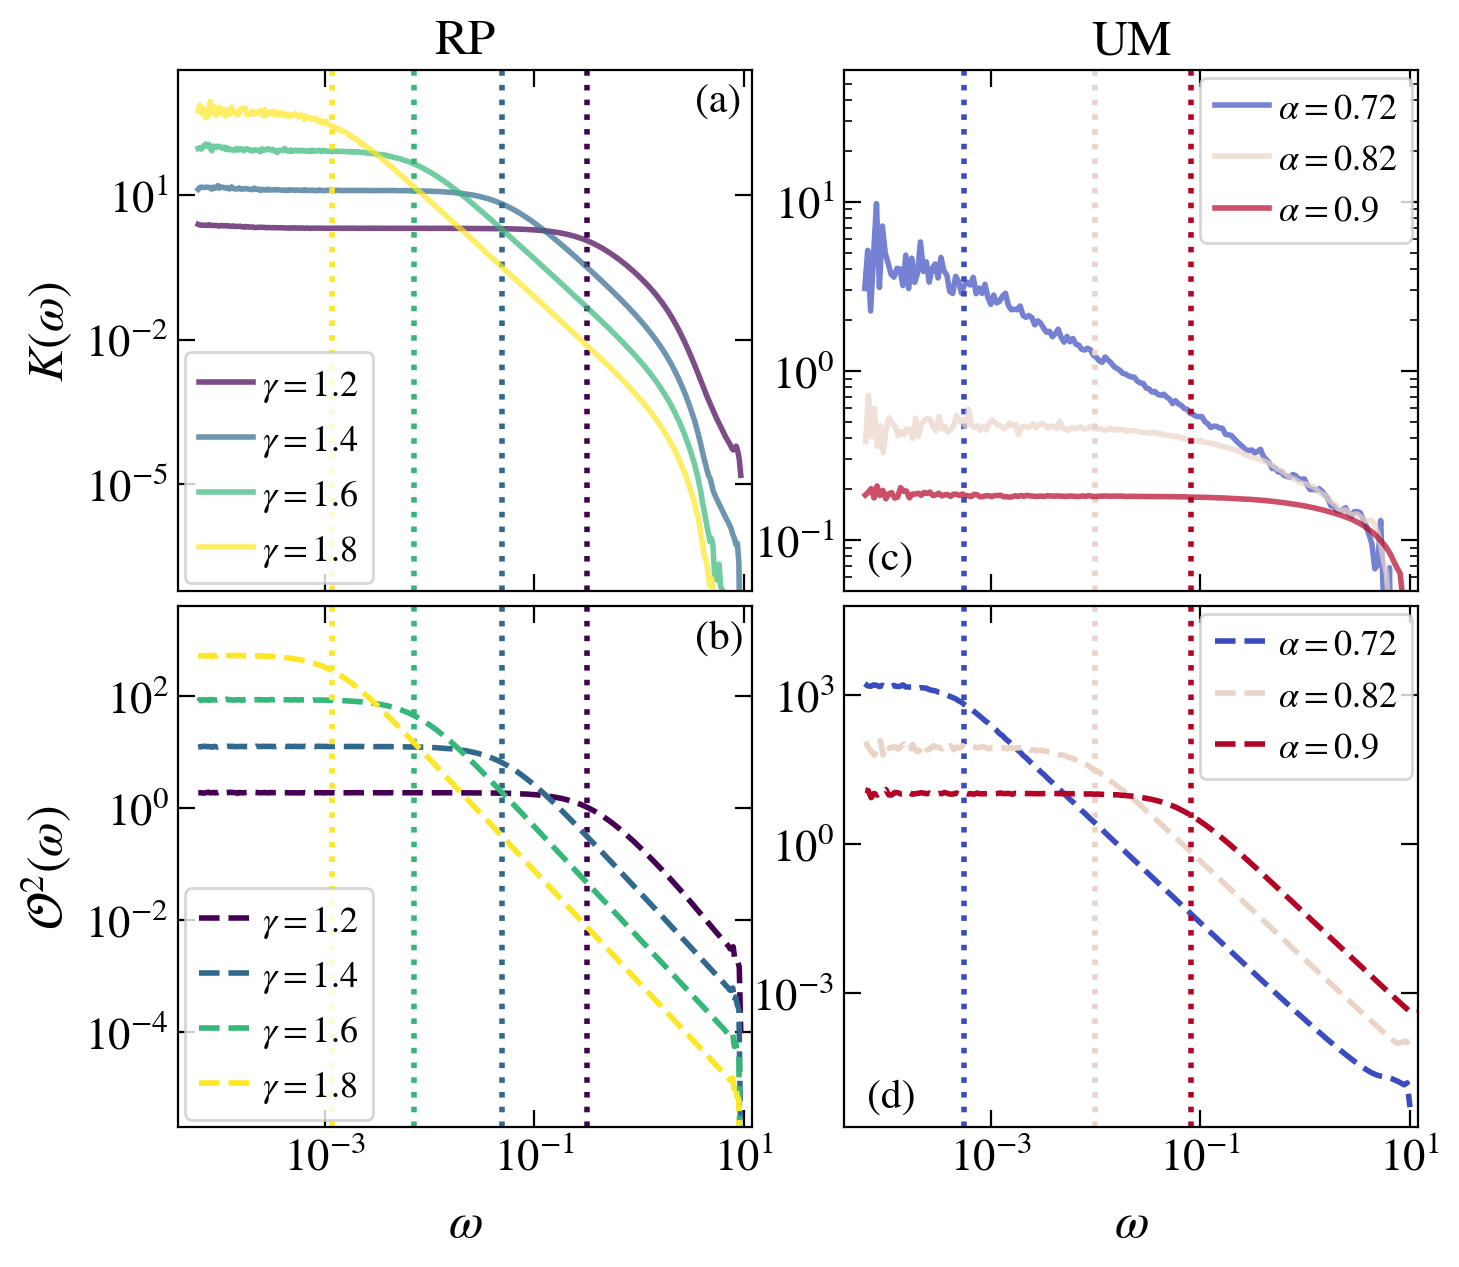

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(1.2, 1.81, 0.2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(8,7), dpi = 200, sharex='col', sharey=False)
# axis = axes[0]
# axis2 = axes[1]
axis = np.transpose(axis)

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])

gx = 1.5

L = 14

window = 50

def lorenz(x, A, G1):
    return A / ( (x / G1)**2 + 1)

handles = []
for gx in gammas:
    col = s_m.to_rgba(gx)
    dim = 2**L
    name_out = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - 0.5))
            wH = np.array(file.get('wH'))[-2]
            DOS = np.array(file.get('DOS'))
            
            omegax = np.array(file.get('omegas'))[10:-20]
            omegax = np.sqrt(omegax[1:] * omegax[:-1])
            spec_fun = np.array(file.get('spec_fun'))[idx, 10:-20]
            X = np.array(file.get('wH_typ_density'))[idx]
            cut = X
            
            xx = omegax
            yy = spec_fun
            xx = xx[~np.isnan(yy)]
            yy = yy[~np.isnan(yy)]
            yy_int = integrate.cumulative_trapezoid(yy, xx)
            yy_int = (yy_int - yy_int[0]) / (yy_int[-1] - yy_int[0])
            idxG = np.argmin( np.abs(yy_int - 0.5) )
            G = xx[idxG]
    else:
        print(name_out)
    name_out = base_dir(model=modello, d=DIM) + 'GOE/K_EOA/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            Ex = np.array(file.get('energy_density'))[0]
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - 0.5))
            omegax = np.array(file.get('omegax'))[0][10:-20]
            omegax = np.sqrt(omegax[1:] * omegax[:-1])
            
            K_EOA = np.array(file.get('K_EOA_all'))[0][10:-20]
            # K_EOA = np.array(file.get('K_EOA'))[idx][100:-20]
            element_count = np.array(file.get('element_count_all'))[0][10:-20]
            
            omegax = omegax[~np.isnan(spec_fun)]
            K_EOA = K_EOA[~np.isnan(spec_fun)]
            spec_fun = spec_fun[~np.isnan(spec_fun)]
            
            omegax = omegax[~np.isnan(K_EOA)]
            spec_fun = spec_fun[~np.isnan(K_EOA)]
            K_EOA = K_EOA[~np.isnan(K_EOA)]
            
            spec_fun = spec_fun[omegax > 1/dim]
            K_EOA = K_EOA[omegax > 1/dim]
            omegax = omegax[omegax > 1/dim]
            
            # yy = K_EOA * spec_fun
            inte = np.trapz(K_EOA, omegax)
            K_EOA = K_EOA/inte
            axis[0][0].plot(omegax, K_EOA, color=col, ls='-', alpha=0.7, lw=2, label = r'$\gamma=%g$'%gx)
            
            inte = np.trapz(spec_fun, omegax)
            spec_fun = spec_fun/inte
            axis[0][1].plot(omegax, spec_fun, color=col, ls='--', lw=2, label = r'$\gamma=%g$'%gx)
            
            axis[0][0].axvline(x=G, lw=2, ls=':', color=col)
            axis[0][1].axvline(x=G, lw=2, ls=':', color=col)
    else:
        print(name_out)

fig_help.set_plot_elements(axis[0,0], ylabel=r"${K}(\omega)$", xlabel=r"", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_legend(axis[0,0], fontsize=13, loc='lower left', columnspacing=0.4, ncol=1, frameon=True)
fig_help.set_plot_elements(axis[0,1], ylabel=r"${\mathcal{O}^2}(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_legend(axis[0,1], fontsize=13, loc='lower left', columnspacing=0.4, ncol=1, frameon=True)

# cbar_ax = axis[0,0].inset_axes([0.1, 1.03, 0.8, 0.03])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
# cbar.set_label(r"$\gamma$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')


# prefix = './UM results/processed/'
prefix = './UM results/AA/uniform_01_08_um/'
sizes = np.arange(8, 14, 1)
# alfas = [0.68, 0.74, 0.8, 0.86]
alfas = [0.72, 0.82, 0.9]

s_m = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=matplotlib.colors.Normalize(
        vmin=min(alfas),
        vmax=max(alfas)))
s_m.set_array([])

# L = 12
dim = 2**L
handles = []
for iia, alfa in enumerate(alfas):
    
    dim = 2**L
    col = s_m.to_rgba(alfa)
    name_out = prefix + "alpha_%.2f_ns_%d_n_1.h5"%(alfa,L)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            
            wH = np.array(file.get('stat/mean_lvl'))
            # sig  = np.sqrt( np.array(file.get('stat/var')) )
            dE  = ( np.array(file.get('stat/bw')) )
            G  = ( np.array(file.get('stat/gamma_th')) )
            
            axis[1][0].axvline(x=G, lw=2, ls=':', color=col)
            axis[1][1].axvline(x=G, lw=2, ls=':', color=col)
            
            omegax = np.array(file.get('O2/omegas'))[1:]
            # omegax = np.sqrt(omegax[1:] * omegax[:-1])
            spec_fun = np.array(file.get('O2/av/raw'))[1:]
            K_EOA = np.array(file.get('k/base'))
            
            omegax = omegax[~np.isnan(spec_fun)]
            K_EOA = K_EOA[~np.isnan(spec_fun)]
            spec_fun = spec_fun[~np.isnan(spec_fun)]
            
            spec_fun = spec_fun[omegax > 1/dim]
            K_EOA = K_EOA[omegax > 1/dim]
            omegax = omegax[omegax > 1/dim]
            
            yy = K_EOA# * spec_fun
            freq = omegax
            # yy = np.array(file.get('fft/s'))# / inte
            # freq = np.array(file.get('fft/om'))
            inte = np.trapz(yy, freq)
            yy = yy/inte
            axis[1][0].plot(freq, yy, color=col, ls='-', alpha=0.7, lw=2, label = r'$\alpha=%g$'%alfa)
            
            inte = np.trapz(spec_fun, omegax)
            spec_fun = spec_fun/inte
            axis[1][1].plot(omegax, spec_fun, color=col, ls='--', lw=2, label = r'$\alpha=%g$'%alfa)
    else:
        print(name_out)

# sc = axis.scatter(np.nan, np.nan, color='k', s=2, label = r'Eq. (22)', alpha=0.4)
# line, = axis.plot(np.nan, np.nan, color='k', ls='--', label = r'$K(\omega)\mathcal{O}^2(E_{\rm av},\omega)$')

# handles.append(sc)
# handles.append(line)

fig_help.set_plot_elements(axis[1,0], ylabel=r"", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_legend(axis[1,0], fontsize=13, loc='upper right', columnspacing=0.4, ncol=1, frameon=True)
fig_help.set_plot_elements(axis[1,1], ylabel=r"", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_legend(axis[1,1], fontsize=13, loc='upper right', columnspacing=0.4, ncol=1, frameon=True)


axis[0,0].set_ylim(6e-8, 4e3)
axis[0,1].set_ylim(2e-6, 4e3)
axis[1,0].set_ylim(5e-2, 6e1)
axis[1,1].set_ylim(2e-6, 6e4)

axis[0,0].annotate(r"(a)", fontsize=15, xy=(0.9, 0.92), xycoords='axes fraction')
axis[0,1].annotate(r"(b)", fontsize=15, xy=(0.9, 0.92), xycoords='axes fraction')
axis[1,0].annotate(r"(c)", fontsize=15, xy=(0.04, 0.04), xycoords='axes fraction')
axis[1,1].annotate(r"(d)", fontsize=15, xy=(0.04, 0.04), xycoords='axes fraction')

axis[0,0].set_xlim(4e-5, 12)
axis[1,1].set_xlim(4e-5, 12)

# z = np.logspace(-5, 2, 1000)
# axis[1,0].plot(z, 2e-1/(z)**0.5, ls='-.', color='k')
# cbar_ax = axis.inset_axes([1.01, 0.0, 0.02, 1])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
# cbar.set_label(r"$\alpha$", fontsize=16)

# cbar_ax = axis[1,0].inset_axes([0.1, 1.03, 0.8, 0.03])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
# cbar.set_label(r"$\alpha$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

axis[0,0].set_title(r"RPM", fontsize=18)
axis[1,0].set_title(r"UM", fontsize=18)

fig.subplots_adjust(wspace = 0.16, hspace=0.03)
fig.savefig("PLOTS_FADING/ANOMALOUS/FigA1.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [76]:
536870910 * 8 / 1e9

4.29496728

1474.108472600179 1603.0533518931627 |||| 6.090950635737901 5.849411552357573


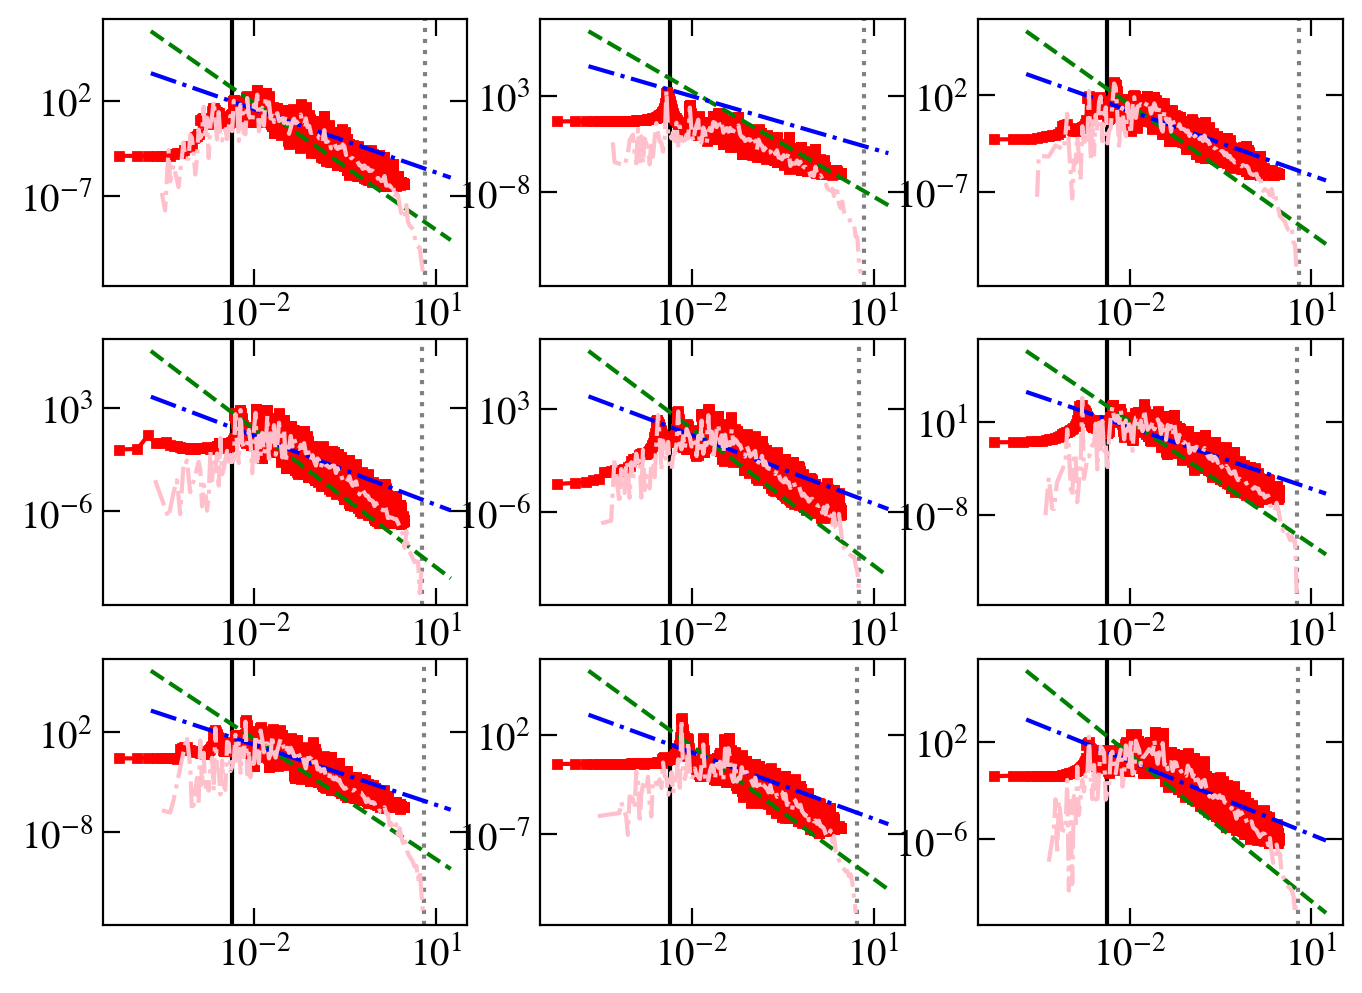

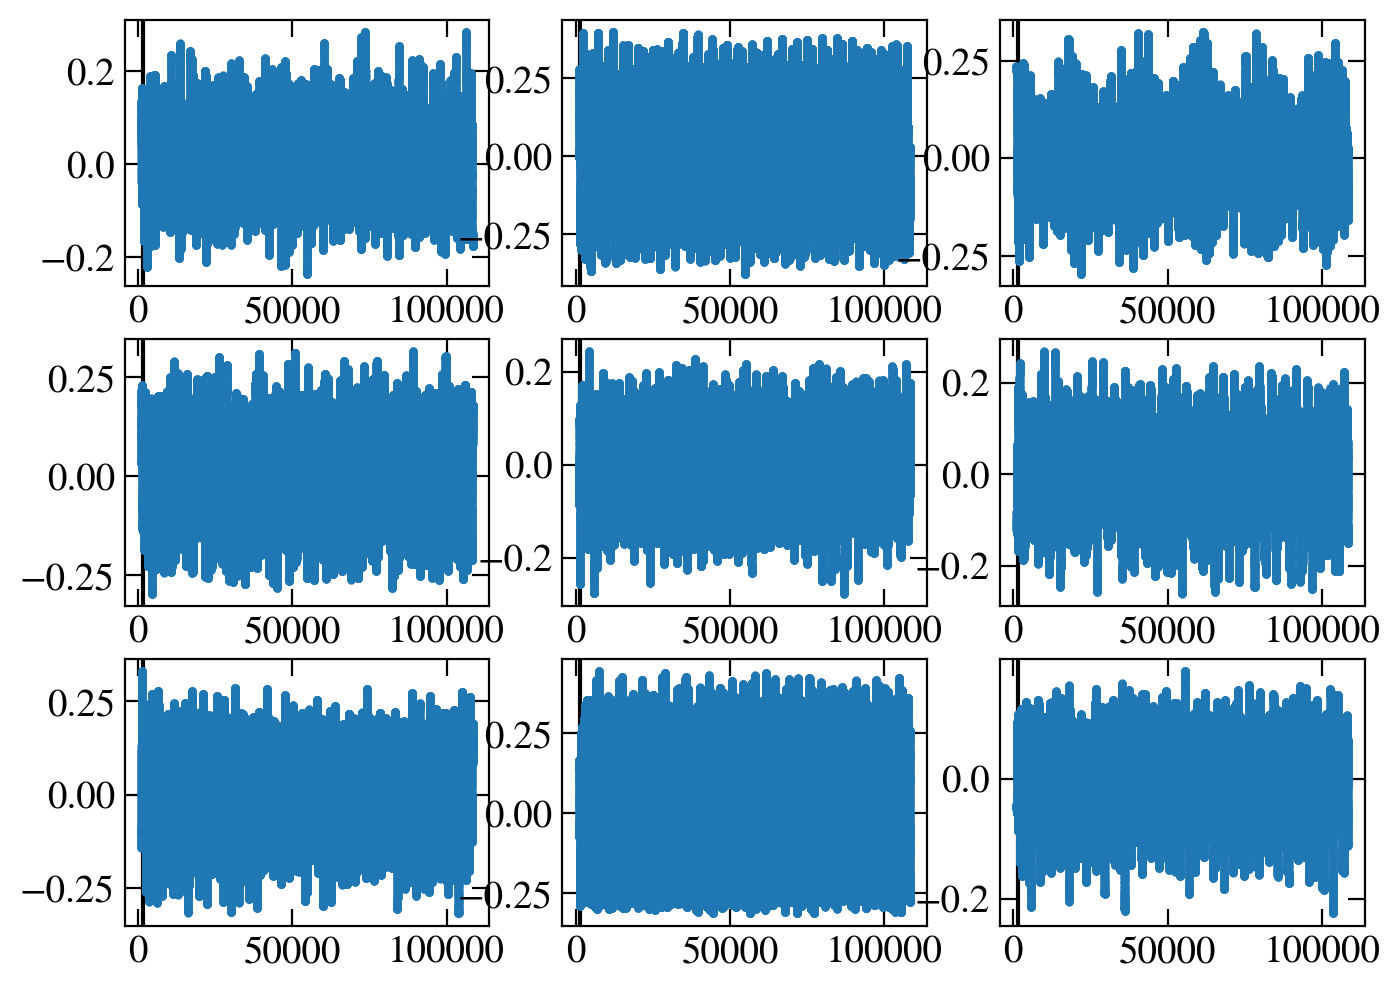

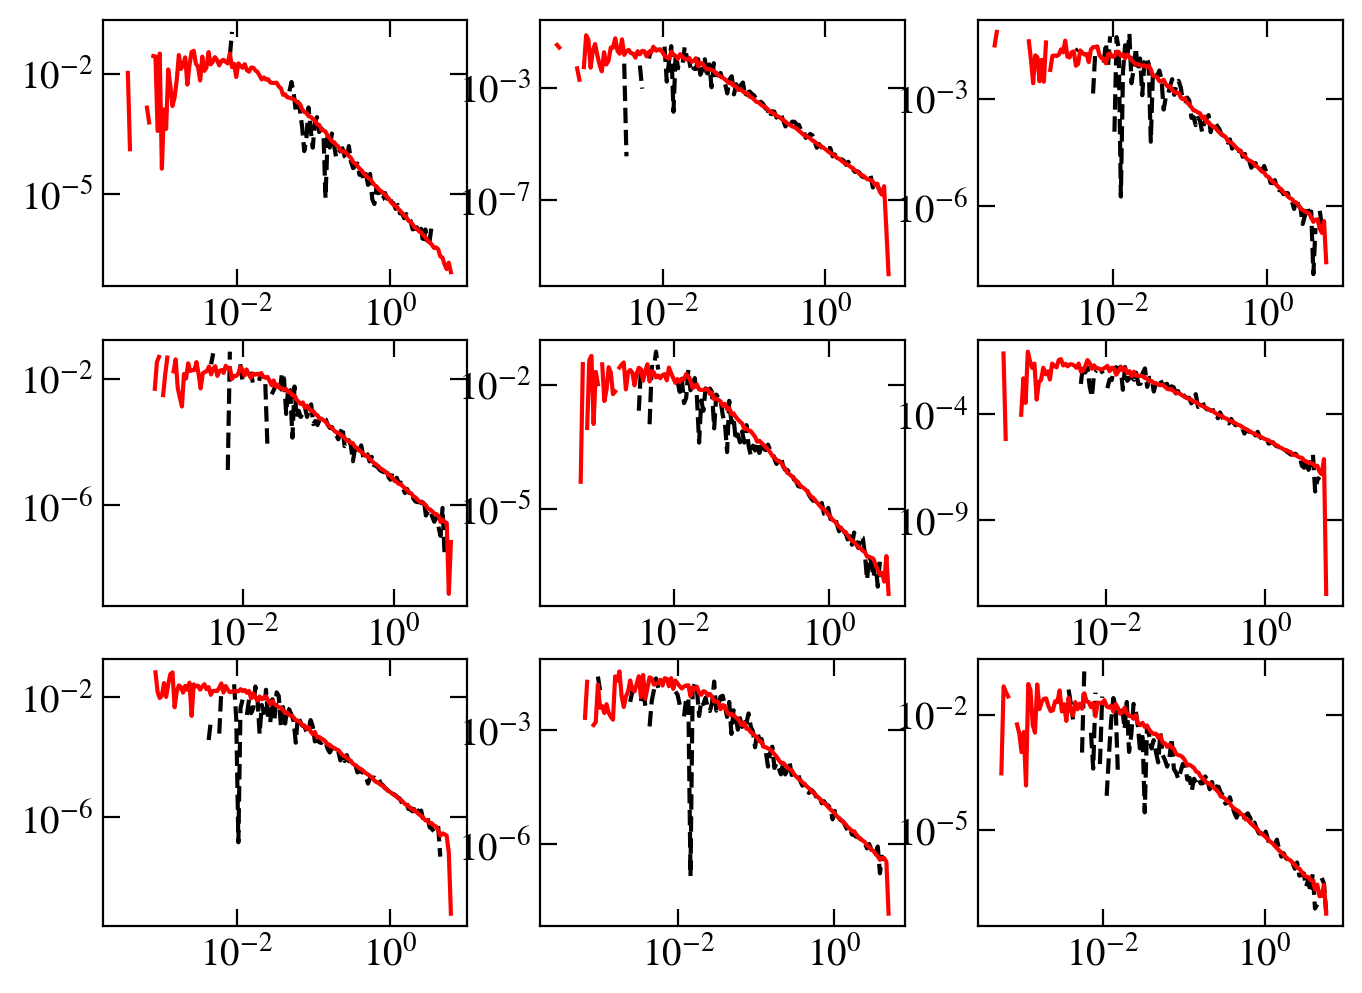

In [62]:
colors_ls_cyc = itertools.cycle(colors_ls)
from scipy import signal
from numpy.fft import *


L = 13
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'GOE/Quench/Fourier/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(1.0, 2.9, 0.2)
# from scipy.signal.windows import blackman
# w = blackman(N)

DIM = 1

nrows = 3
fig, axis = plt.subplots( nrows=nrows, ncols=3, figsize=(8,2*nrows), dpi = 200)
axis = axis.flatten()

fig_raw, axis_raw = plt.subplots( nrows=nrows, ncols=3, figsize=(8,2*nrows), dpi = 200)
axis_raw = axis_raw.flatten()

fig_spec, axis_spec = plt.subplots( nrows=nrows, ncols=3, figsize=(8,2*nrows), dpi = 200)
axis_spec = axis_spec.flatten()

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])

gx = 1.8
L = 9
dim = 2**L
name_out = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        dE = np.mean( np.array(file.get('bandwidth')) )
        wH = np.array(file.get('wH_typ'))[-2]
        tH = 2 * np.pi / wH
        
        e_max = e_max = ( np.sqrt(2 * np.log(dim)) - np.log(np.log(dim) * 4 * np.pi) / np.sqrt(2*np.log(dim)) / 2 ) * (np.sqrt(1 + dim**(1-gx)))
        dE_analytical = 2 * e_max if gx >= 1 else (4 * np.sqrt(1 + dim**(1-gx)))
        print(tH, 2 * np.pi * dim / (np.sqrt(1 + dim**(1-gx))) / 2, "||||", dE, dE_analytical)
else:
    print(name_out)
for ii, ax in enumerate(axis_raw):
    ax.axvline(x=tH, ls='-', color='k')
    axis[ii].axvline(x=wH, ls='-', color='k')
    

for ii, ax in enumerate(axis_raw):
    name_out = base_dir(model=modello, d=DIM) + 'GOE/Quench/Fourier/realisation=%d/'%ii + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            E  = np.array(file.get('E'))[0]
            axis[ii].axvline(x=E[-1] - E[0], ls=':', color='gray')
            
            times  = np.array(file.get('times'))[0]
            t_idx = times.size#np.argmin(np.abs(times - 2*np.pi / wH))
            times = times[:t_idx]
            T = times[1] - times[0]
            N = times.size
            # Cn  = np.array(file.get('coefficients'))[0]
            # diag_mat  = np.array(file.get('diag_mat_elem'))[0]
            # Q_DE = np.sum(np.abs(Cn)**2 * diag_mat)
            
            Q_raw  = np.array(file.get('quench'))[0][:t_idx]
            Q_DE = np.mean(Q_raw[-10000:])
            Q_raw = Q_raw - Q_DE
            
            omegas  = np.array(file.get('omegax'))[0]
            ax.plot(times, Q_raw, lw=1, marker='o', markersize=2)
            
            xf = 2 * np.pi * fftfreq(N, T)[1:N//2]
            yf = np.abs( 2 / np.sqrt(N) * np.abs(fft(Q_raw)[1:N//2]) )**2
            # xf, yf = signal.welch(Q_raw[ii], 1/T, scaling='spectrum', average='median')

            # print(T, times[-1] - times[0], np.min(xf))
            yf = tools.remove_fluctuations(yf, 6)
            inte = np.trapz(yf, xf)
            yf = yf / inte
            axis[ii].plot(xf, yf, color='red', marker='s', markersize=3)
            
            # axis[ii].plot(xf, _resc_(xf, 1/xf**2, yf), ls='--', color='k')
            # axis[ii].plot(xf, _resc_(1/xf**1), ls=':', color='blue')
            # pow_spec = np.zeros(omegas.shape)
            # for iiw, w in enumerate(omegas):
            #     pow_spec[iiw] = np.trapz( np.exp(1j * w * times) * (Q_raw), times)
            # pow_spec = np.abs(pow_spec)**2
             
            # pow_spec = tools.remove_fluctuations(pow_spec, 4)
            # inte = np.trapz(pow_spec, omegas)
            # axis[ii].plot(omegas, pow_spec / inte, color='k', marker='o', markersize=2)
            
            yy = 1/omegas**4
            idx = omegas.size//5*2
            axis[ii].plot(omegas, yy / yy[idx] * yf[idx], color='green', ls='--')
            
            yy = 1/omegas**2
            idx = omegas.size//5*2
            axis[ii].plot(omegas, yy / yy[idx] * yf[idx], color='blue', ls='-.')
            
            Ex  = np.array(file.get('energy_density'))[0]
            idx_E = np.argmin(np.abs(Ex - 0.5))
            omegas  = np.array(file.get('omegax'))[0]
            omegas = (omegas[1:] + omegas[:-1])/2
            _spectral_fun_eps  = np.array(file.get('_spectral_fun_eps'))[idx_E]
            _element_count_eps  = np.array(file.get('_element_count_eps'))[idx_E]
            _spectral_fun  = np.array(file.get('_spectral_fun'))[0]
            _element_count  = np.array(file.get('_element_count'))[0]
            
            axis_spec[ii].plot(omegas, _spectral_fun_eps / _element_count_eps, color='k', ls='--')
            axis_spec[ii].plot(omegas, _spectral_fun / _element_count, color='red', ls='-')
            
            _power_spec  = np.array(file.get('power_spectrum'))[0] / _element_count
            
            omegas = omegas[~np.isnan(_power_spec)]
            _power_spec = _power_spec[~np.isnan(_power_spec)]
            inte = np.trapz(_power_spec, omegas)
            axis[ii].plot(omegas, _power_spec / inte, color='pink', ls='-.')
            
    else:
        print(name_out)    
for ii, ax in enumerate(axis_raw):
    fig_help.set_plot_elements(ax, ylabel=r"", xlabel=r"", font_size=14, set_legend=0, xscale='linear', yscale='linear')
    fig_help.set_plot_elements(axis[ii], ylabel=r"", xlabel=r"", font_size=14, set_legend=0, xscale='log', yscale='log')
    fig_help.set_plot_elements(axis_spec[ii], ylabel=r"", xlabel=r"", font_size=14, set_legend=0, xscale='log', yscale='log')
# fig_help.set_plot_elements(axis, ylabel=r"$f(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

1474.108472600179 1603.0533518931627 |||| 6.090950635737901 5.849411552357573


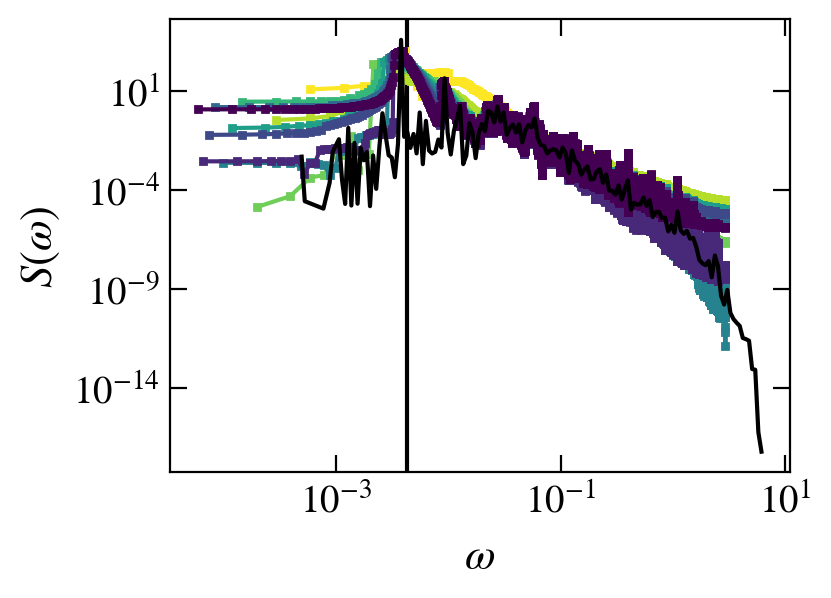

In [61]:
colors_ls_cyc = itertools.cycle(colors_ls)
# from scipy import signal
# from numpy.fft import *
from numpy.fft import rfft as fft
from numpy.fft import rfftfreq as fftfreq

L = 13
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'GOE/Quench/Fourier/realisation=1/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(1.0, 2.9, 0.2)
# from scipy.signal.windows import blackman
# w = blackman(N)

DIM = 1

nrows = 5
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200)

nmin=1
nmax=10
s_m = matplotlib.cm.ScalarMappable(cmap='viridis_r', norm=matplotlib.colors.Normalize(
        vmin=(nmin),
        vmax=(nmax)))
s_m.set_array([])

gx = 1.8
L = 9
dim = 2**L
name_out = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        dE = np.mean( np.array(file.get('bandwidth')) )
        wH = np.array(file.get('wH_typ'))[-2]
        tH = 2 * np.pi / wH
        
        e_max = e_max = ( np.sqrt(2 * np.log(dim)) - np.log(np.log(dim) * 4 * np.pi) / np.sqrt(2*np.log(dim)) / 2 ) * (np.sqrt(1 + dim**(1-gx)))
        dE_analytical = 2 * e_max if gx >= 1 else (4 * np.sqrt(1 + dim**(1-gx)))
        print(tH, 2 * np.pi * dim / (np.sqrt(1 + dim**(1-gx))) / 2, "||||", dE, dE_analytical)
else:
    print(name_out)

axis.axvline(x=wH, ls='-', color='k')
    
    
name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        
        for n in np.arange(nmin, nmax+1, 1):
            times  = np.array(file.get('times'))[0]
            T = times[1] - times[0]
            N = times.size
            
            times = times[:int(n / nmax * N)]
            Q_raw  = np.array(file.get('quench'))[0][:int(n / nmax * N)]
            N = times.size
            # T = times[1] - times[0]
            
            xf = 2 * np.pi * fftfreq(N, T)[1:]
            yf = np.abs( 2 / np.sqrt(N) * np.abs(fft(Q_raw))[1:] )**2
            inte = np.trapz(yf, xf)
            yf = tools.remove_fluctuations(yf, 20)
            axis.plot(xf, yf / inte, color=s_m.to_rgba(n), marker='s', markersize=2)
        
        omegax = np.array(file.get('omegax'))[0]
        omegax = np.sqrt(omegax[1:] * omegax[:-1])
        _element_count  = np.array(file.get('_element_count'))[0]
            
        _power_spec  = np.array(file.get('power_spectrum'))[0] / _element_count
        
        omegax = omegax[~np.isnan(_power_spec)]
        _power_spec = _power_spec[~np.isnan(_power_spec)]
        inte = np.trapz(_power_spec, omegax)
        axis.plot(omegax, _power_spec / inte, color='k')
else:
    print(name_out)     
fig_help.set_plot_elements(axis, ylabel=r"$S(\omega)$", xlabel=r"$\omega$", font_size=14, set_legend=0, xscale='log', yscale='log')
# fig_help.set_plot_elements(axis, ylabel=r"$f(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

## DISTRIBUTION OF LONG-TIME VALUES

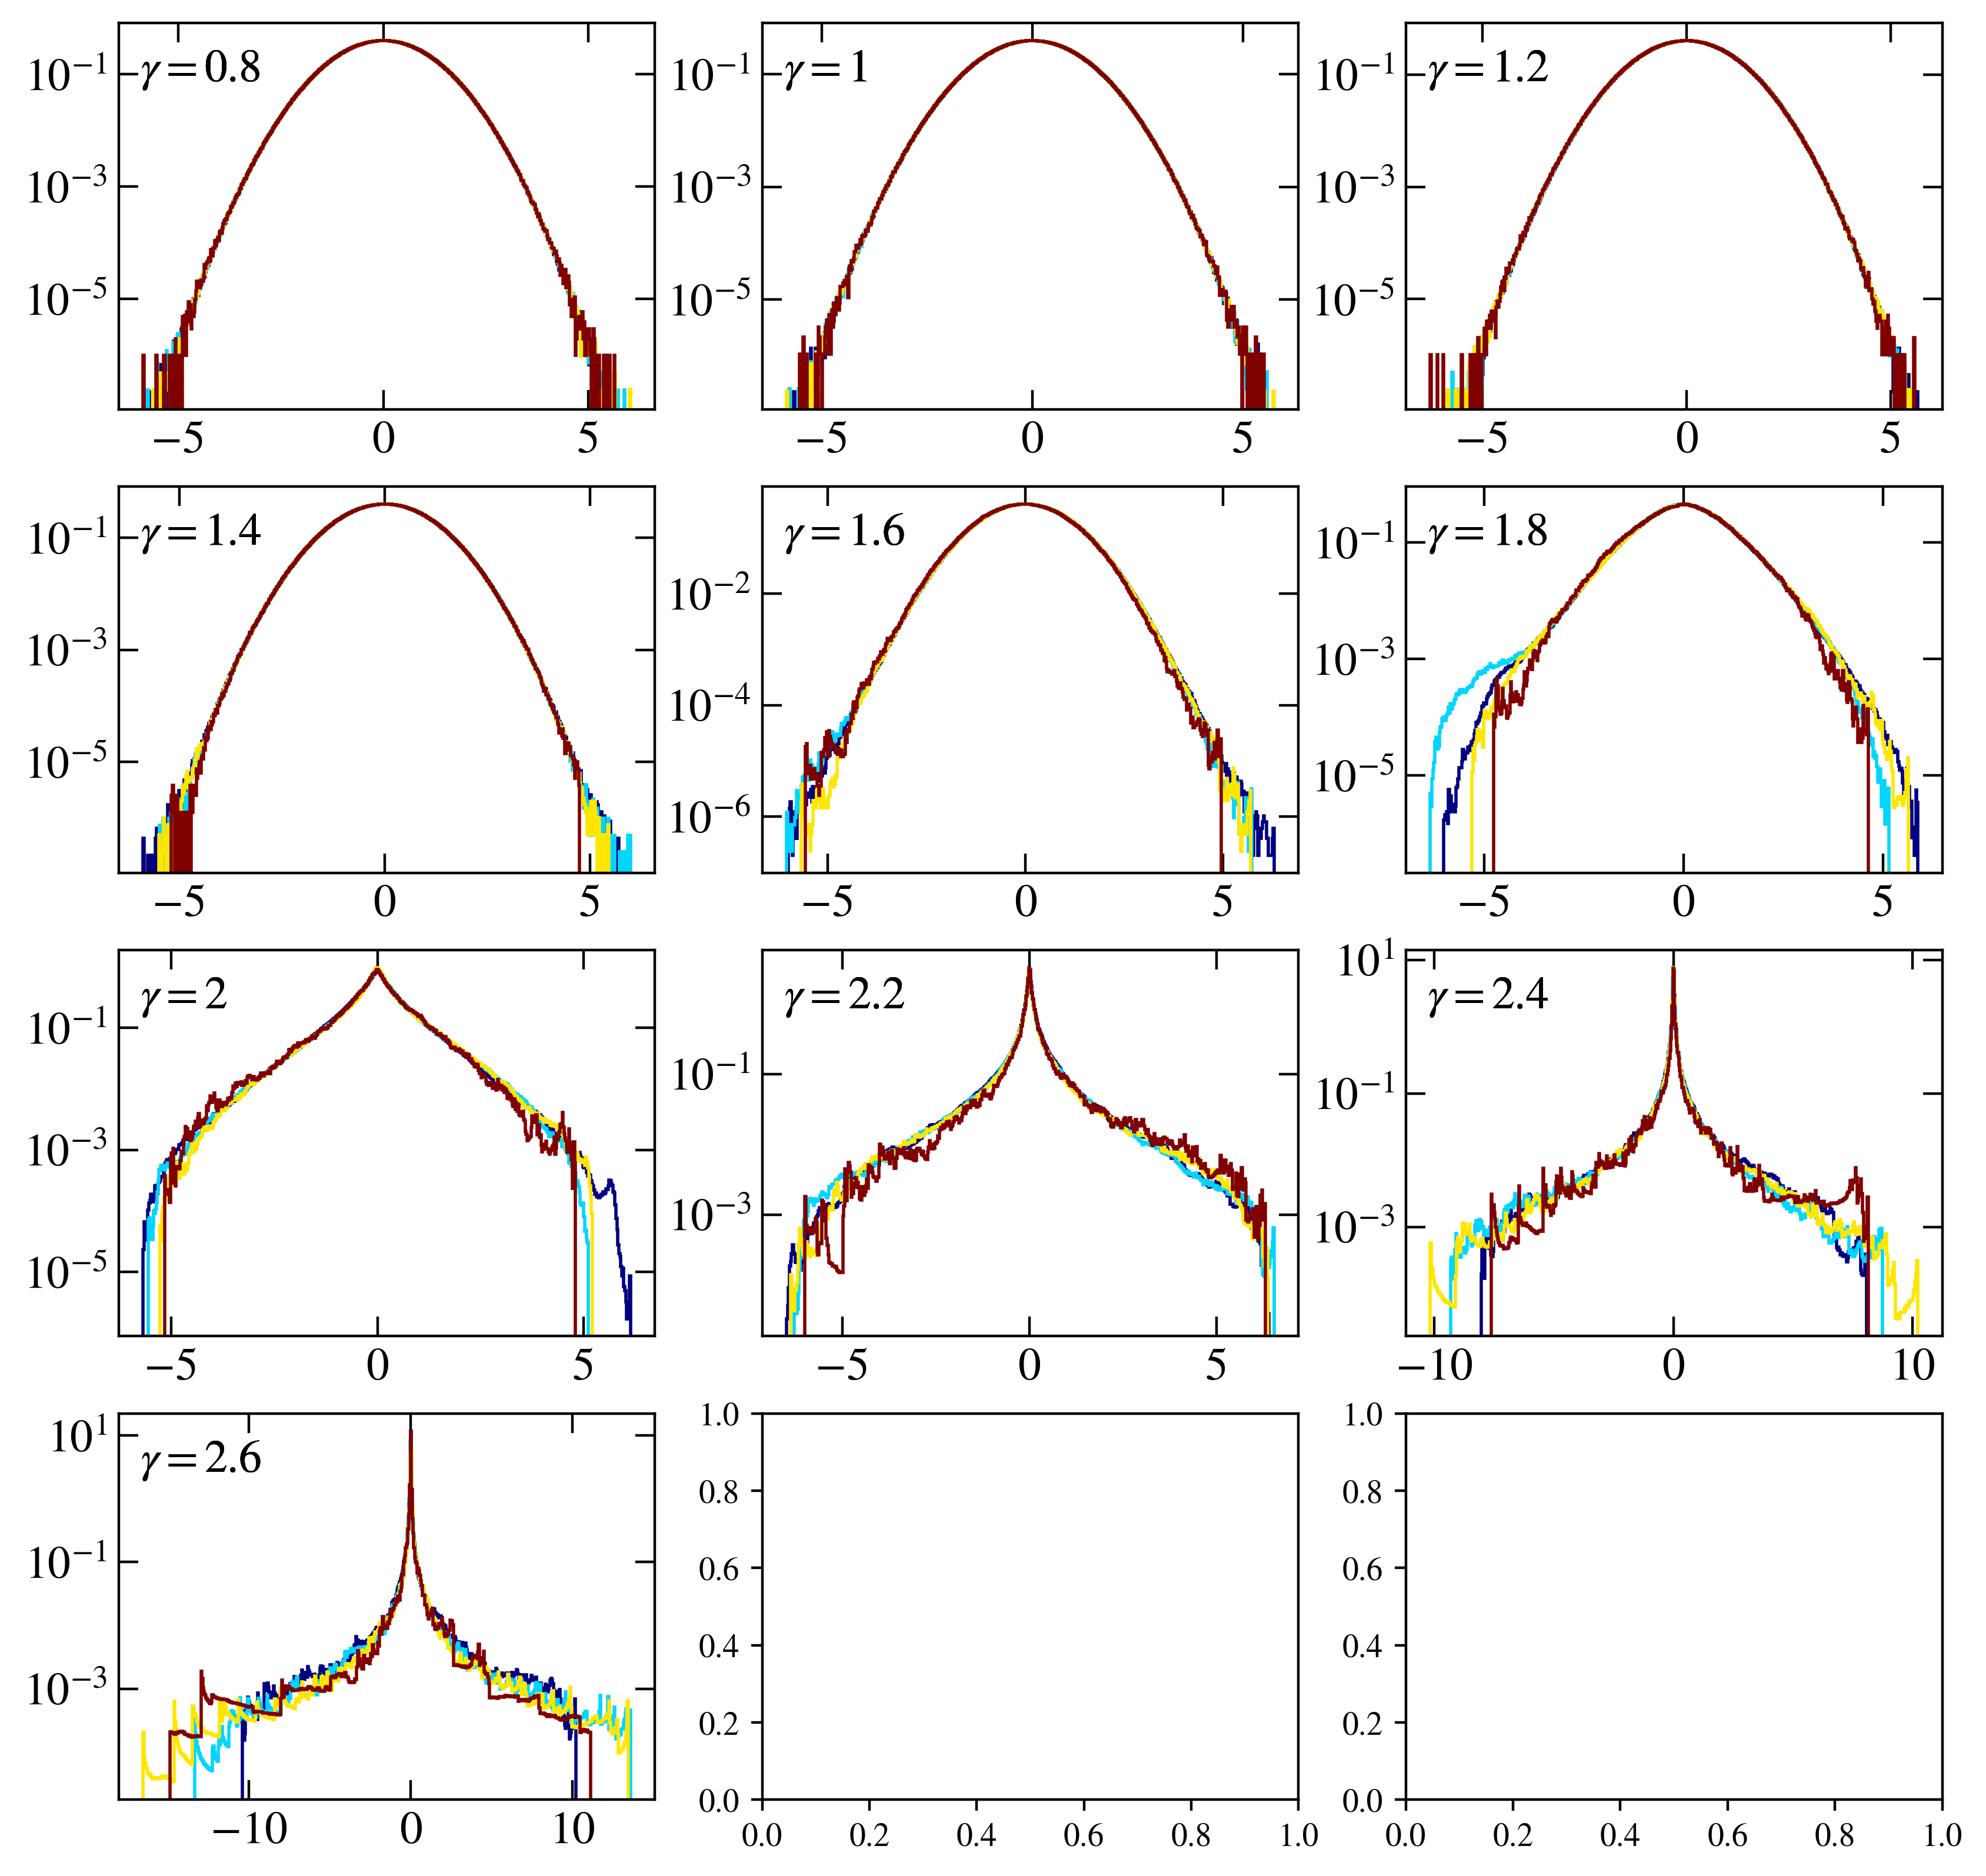

In [137]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 12
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'GOE/Quench/Fourier_test2/'

sizes = np.arange(10, 14, 1)
gammas = np.arange(2., 2.9, 0.1)

DIM = 1
gammas = np.arange(0.8, 2.7, 0.2)
fig, axis = plt.subplots( nrows=4, ncols=3, figsize=(10,10), dpi = 400, sharex=False, sharey=False)
axis = axis.flatten()
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes)))
s_m.set_array([])


for iig, gx in enumerate(gammas):
    d2 = 1 if gx <= 1 else 2 - gx
    for L in sizes:
        col = s_m.to_rgba(L)
        dim = 2**L
        name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                sec_mom = np.sqrt(np.array(file.get('second_moment')) - np.array(file.get('first_moment'))**2)
                bins  = np.array(file.get('fluct_bins')) / (sec_mom)
                dist  = np.array(file.get('fluct_hist')) * sec_mom
                axis[iig].stairs(dist, bins, color=col)
        else:
            print(name_out)
        
        # name_out = base_dir(model=modello, d=DIM) + 'Quench/' +  "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
        # if exists(name_out):
        #     with h5py.File(name_out, "r") as file:
        #         sec_mom = np.sqrt(np.array(file.get('LTVALS/L=%d/second_moment'%L)) - np.array(file.get('LTVALS/L=%d/first_moment'%L))**2)
        #         bins = np.array(file.get('LTVALS/L=%d/bins'%L))# / sec_mom
        #         hist = np.array(file.get('LTVALS/L=%d/hist'%L))# * sec_mom
        #         axis[iig].stairs(hist, bins, color=col)
                
        axis[iig].annotate(r" $\gamma=%g$"%gx, fontsize=14, xy=(0.02, 0.85), xycoords='axes fraction')
    # axis[iig].plot(bins, np.exp(-bins**2) / np.sqrt(np.pi), color='k', ls='--')
    fig_help.set_plot_elements(axis[iig], ylabel=r"", xlabel=r"", font_size=14, set_legend=0, xscale='linear', yscale='log')
    # axis[iig].set_xlim(-4, None)

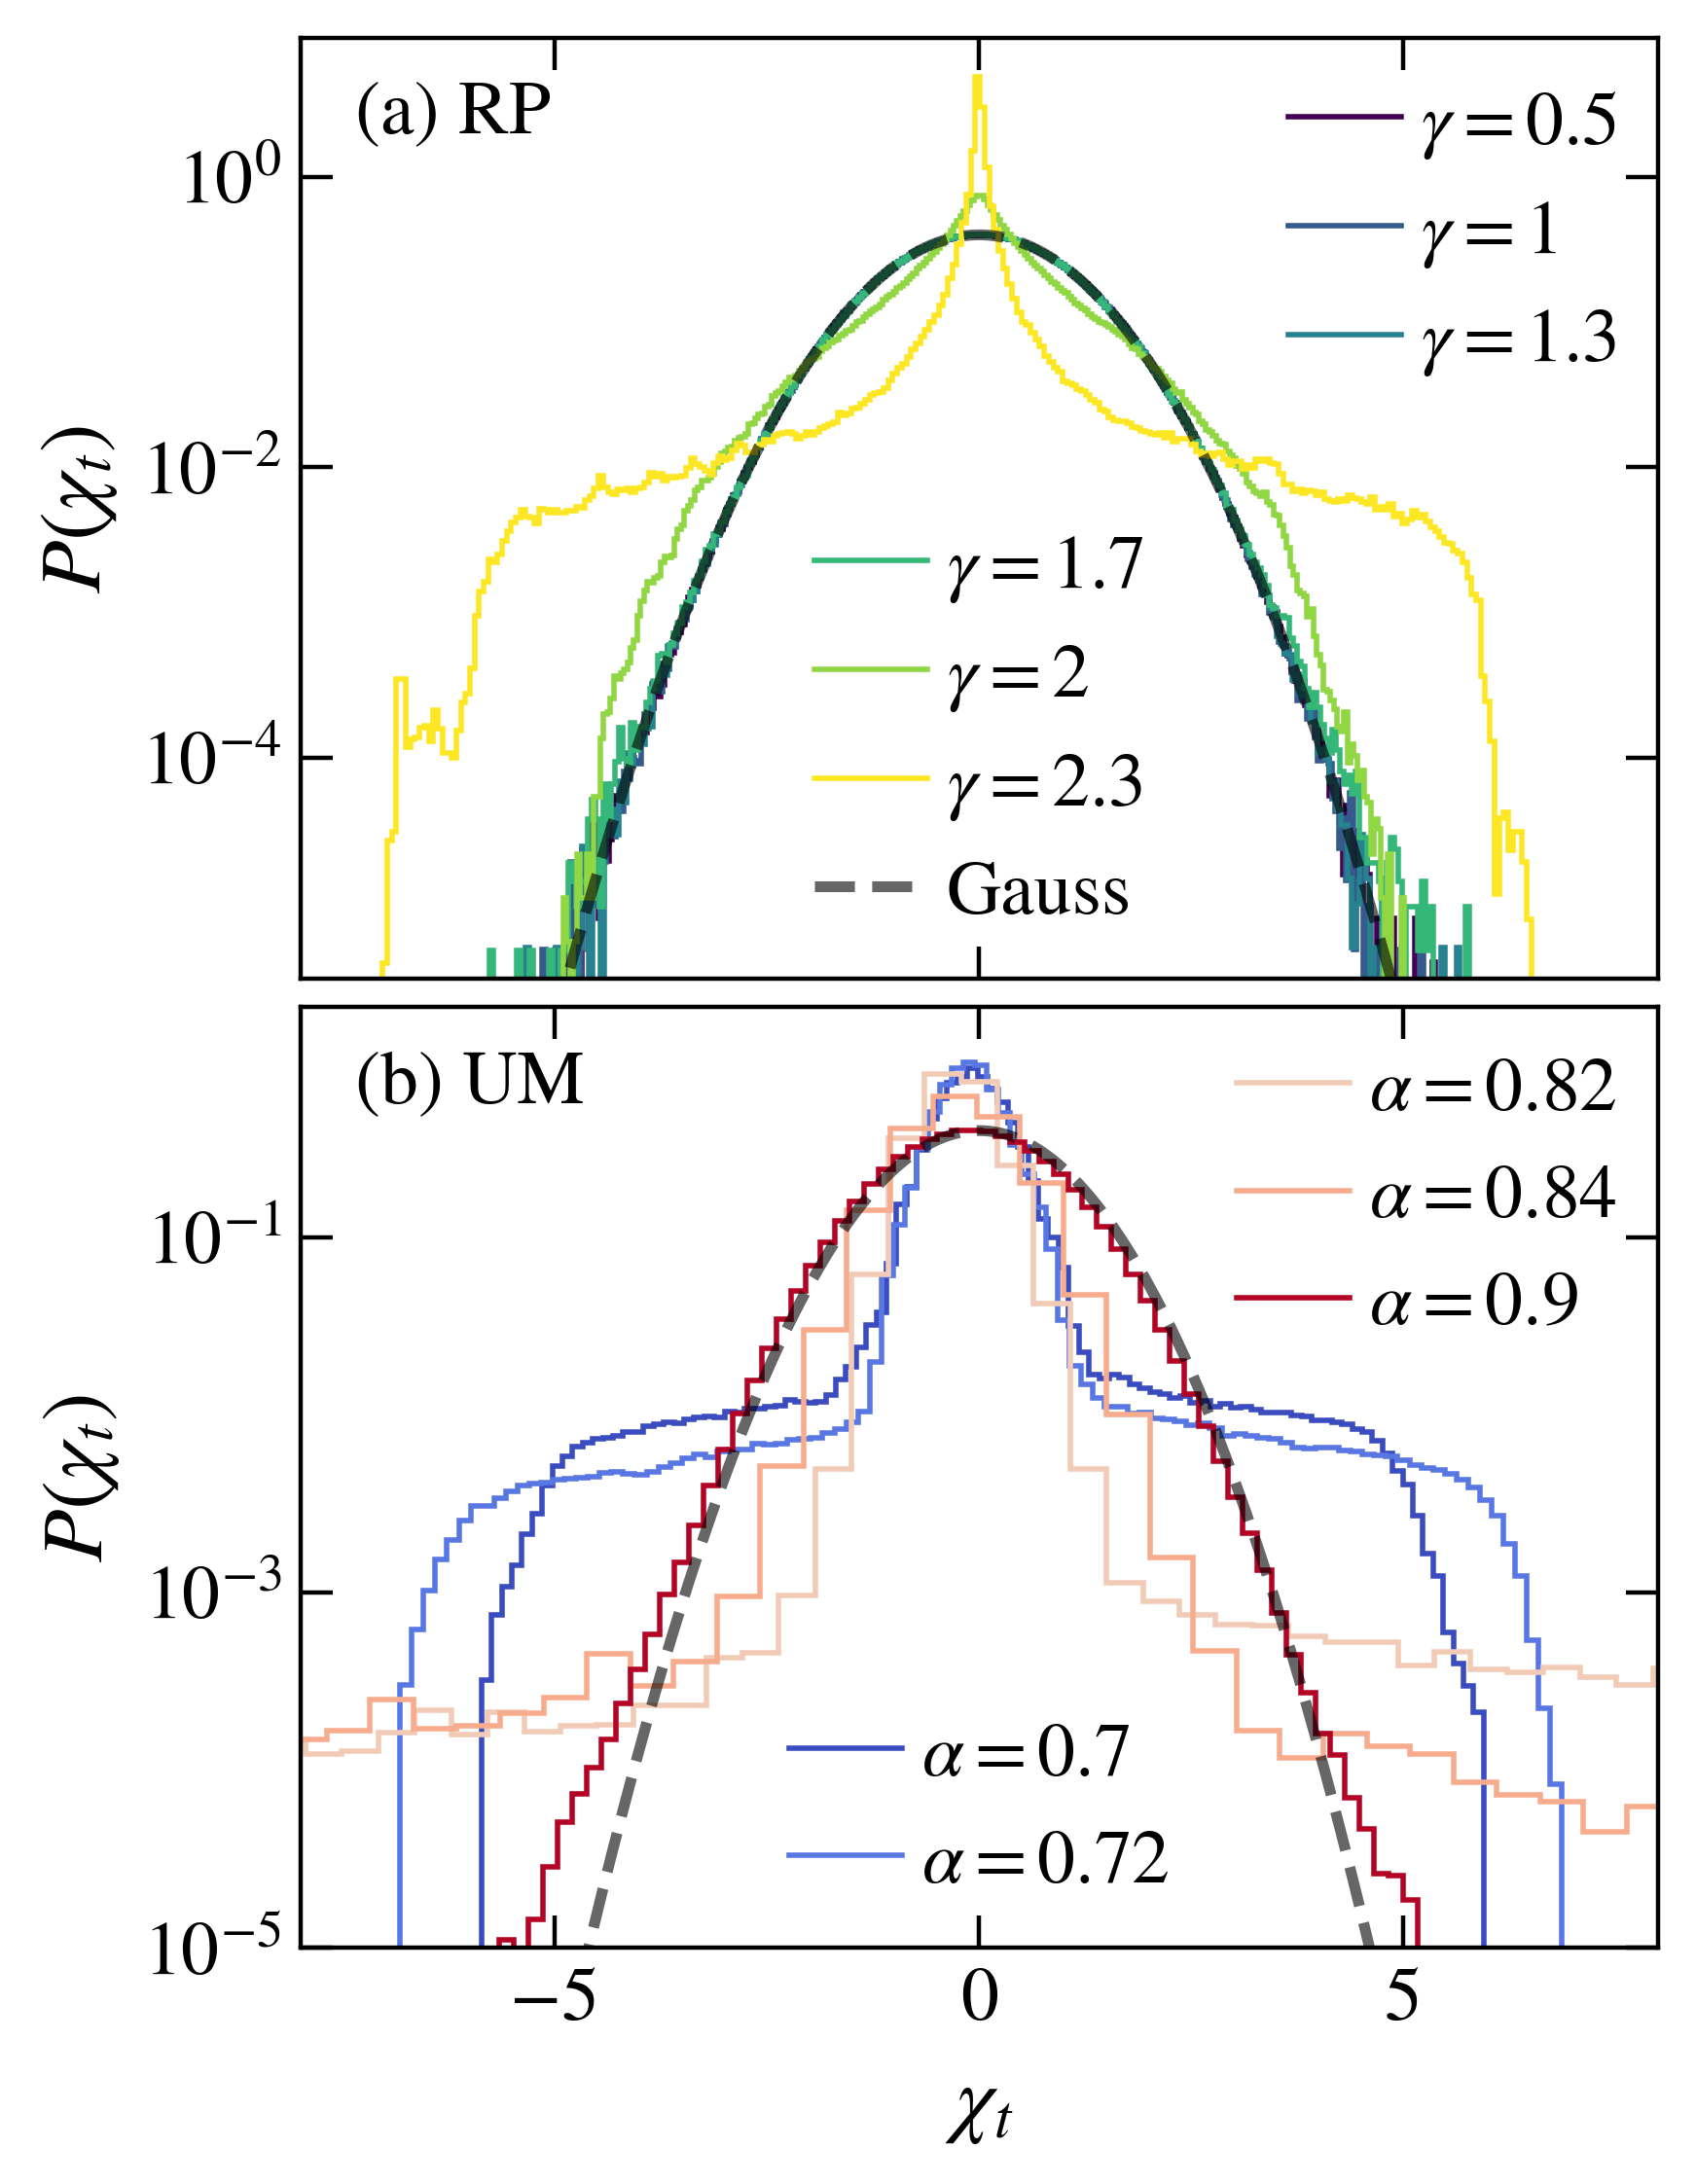

In [79]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 14
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 17, 1)
gammas = np.arange(2., 2.9, 0.1)

DIM = 1
gammas = np.arange(0.4, 2.1, 0.2)
fig, axes = plt.subplots( nrows=2, ncols=1, figsize=(4.5,6.5), dpi = 400, sharex=True, sharey=False)
axis = axes[0]
ax = axes[1]

gammas = [0.5, 1.0, 1.3, 1.7, 2.0, 2.3]
# gammas = [2.0, 2.4, 2.6, 3.0, 3.2, 3.5]
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])

handles = []
for iig, gx in enumerate(gammas):
    d2 = 1 if gx <= 1 else 2 - gx
    col = s_m.to_rgba(gx)
    dim = 2**L
    # name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    # if exists(name_out):
    #     with h5py.File(name_out, "r") as file:
    #         sec_mom = np.sqrt(np.array(file.get('second_moment')) - np.array(file.get('first_moment'))**2)
    #         bins  = np.array(file.get('fluct_bins')) / sec_mom#np.sqrt(2 * dim**d2)
    #         hist  = np.array(file.get('fluct_hist')) * sec_mom#np.sqrt(2 * dim**d2)
    #         line = axis.stairs(hist, bins, color=col, label=r"$\gamma=%g$"%gx)
    #         handles.append(line)
    # else:
    #     print(name_out)
    
    name_out = base_dir(model=modello, d=DIM) + 'Quench/' +  "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            try:
                sec_mom = np.sqrt(np.array(file.get('LTVALS/L=%d/second_moment'%L)) - np.array(file.get('LTVALS/L=%d/first_moment'%L))**2)
                bins = np.array(file.get('LTVALS/L=%d/bins'%L))# / sec_mom
                hist = np.array(file.get('LTVALS/L=%d/hist'%L))# * sec_mom
                line = axis.stairs(hist, bins, color=col, label=r"$\gamma=%g$"%gx)
                handles.append(line)
            except TypeError:
                print(name_out)

x = np.linspace(-5, 5, 1000)
line, = axis.plot(x, np.exp(-x**2/2) / np.sqrt(2*np.pi), ls='--', color='k', lw=2, alpha=0.6, label='Gauss')
ax.plot(x, np.exp(-x**2/2) / np.sqrt(2*np.pi), ls='--', color='k', lw=2, alpha=0.6)
handles.append(line)

axis.set_ylim(3e-6, 9)
axis.set_xlim(-8, 8)

fig_help.set_plot_elements(axis, ylabel=r"$P(\chi_t)$", xlabel=r"", font_size=14, set_legend=0, xscale='linear', yscale='log')
leg = fig_help.set_legend(axis, fontsize=14, loc='lower center', handles = handles[3:])
fig_help.set_legend(axis, fontsize=14, loc='upper right', handles = handles[:3])
fig.add_artist(leg)

# alfas = [0.68, 0.74, 0.8, 0.86, 0.92]
alfas = [0.7, 0.72, 0.82, 0.84, 0.9]
s_m = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=matplotlib.colors.Normalize(
        vmin=min(alfas),
        vmax=max(alfas)))
s_m.set_array([])

handles = []
for iia, alfa in enumerate(alfas):
    col = s_m.to_rgba(alfa)
    dim = 2**L
    # name_out = "./UM results/processed/alpha_%.2f_ns_%d_n_1.h5"%(alfa,L)
    name_out = "./UM results/AA/uniform_01_08_um/alpha_%.2f_ns_%d_n_1.h5"%(alfa,L)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            try:
                # vals = np.array(file.get('evo/moving_av_rm'))
                # sec_mom = np.sqrt( np.mean(vals**2) - np.mean(vals)**2 )
                # hist, bins = np.histogram(vals, bins=100, density=True)
                # print(np.array(file.get('evo/dist/de/mom'))[1].size)
                sec_mom = np.sqrt( np.mean(np.array(file.get('evo/dist/de/mom'))[1]) - np.mean(np.array(file.get('evo/dist/de/mom'))[0])**2)
                bins = np.array(file.get('evo/dist/de/bins')) / sec_mom
                hist = np.array(file.get('evo/dist/de/vals'))[1:] * sec_mom
                line = ax.stairs(hist, bins, color=col, label=r"$\alpha=%g$"%alfa)
                handles.append(line)
            except TypeError:
                print("FAILED:", name_out)
    else:
        print(name_out)

fig_help.set_plot_elements(ax, ylabel=r"$P(\chi_t)$", xlabel=r"$\chi_t$", font_size=14, set_legend=0, xscale='linear', yscale='log')
leg = fig_help.set_legend(ax, fontsize=14, loc='lower center', handles = handles[:2])
fig_help.set_legend(ax, fontsize=14, loc='upper right', handles = handles[2:])
fig.add_artist(leg)
ax.set_ylim(1e-5, None)


axis.annotate(r"(a) RP", fontsize=14, xy=(0.04, 0.9), xycoords='axes fraction')
ax.annotate(r"(b) UM", fontsize=14, xy=(0.04, 0.9), xycoords='axes fraction')

fig.subplots_adjust(wspace = 0.03, hspace=0.03)
fig.savefig("PLOTS_FADING/ANOMALOUS/Fig4.pdf", bbox_inches = 'tight', pad_inches=0.02)

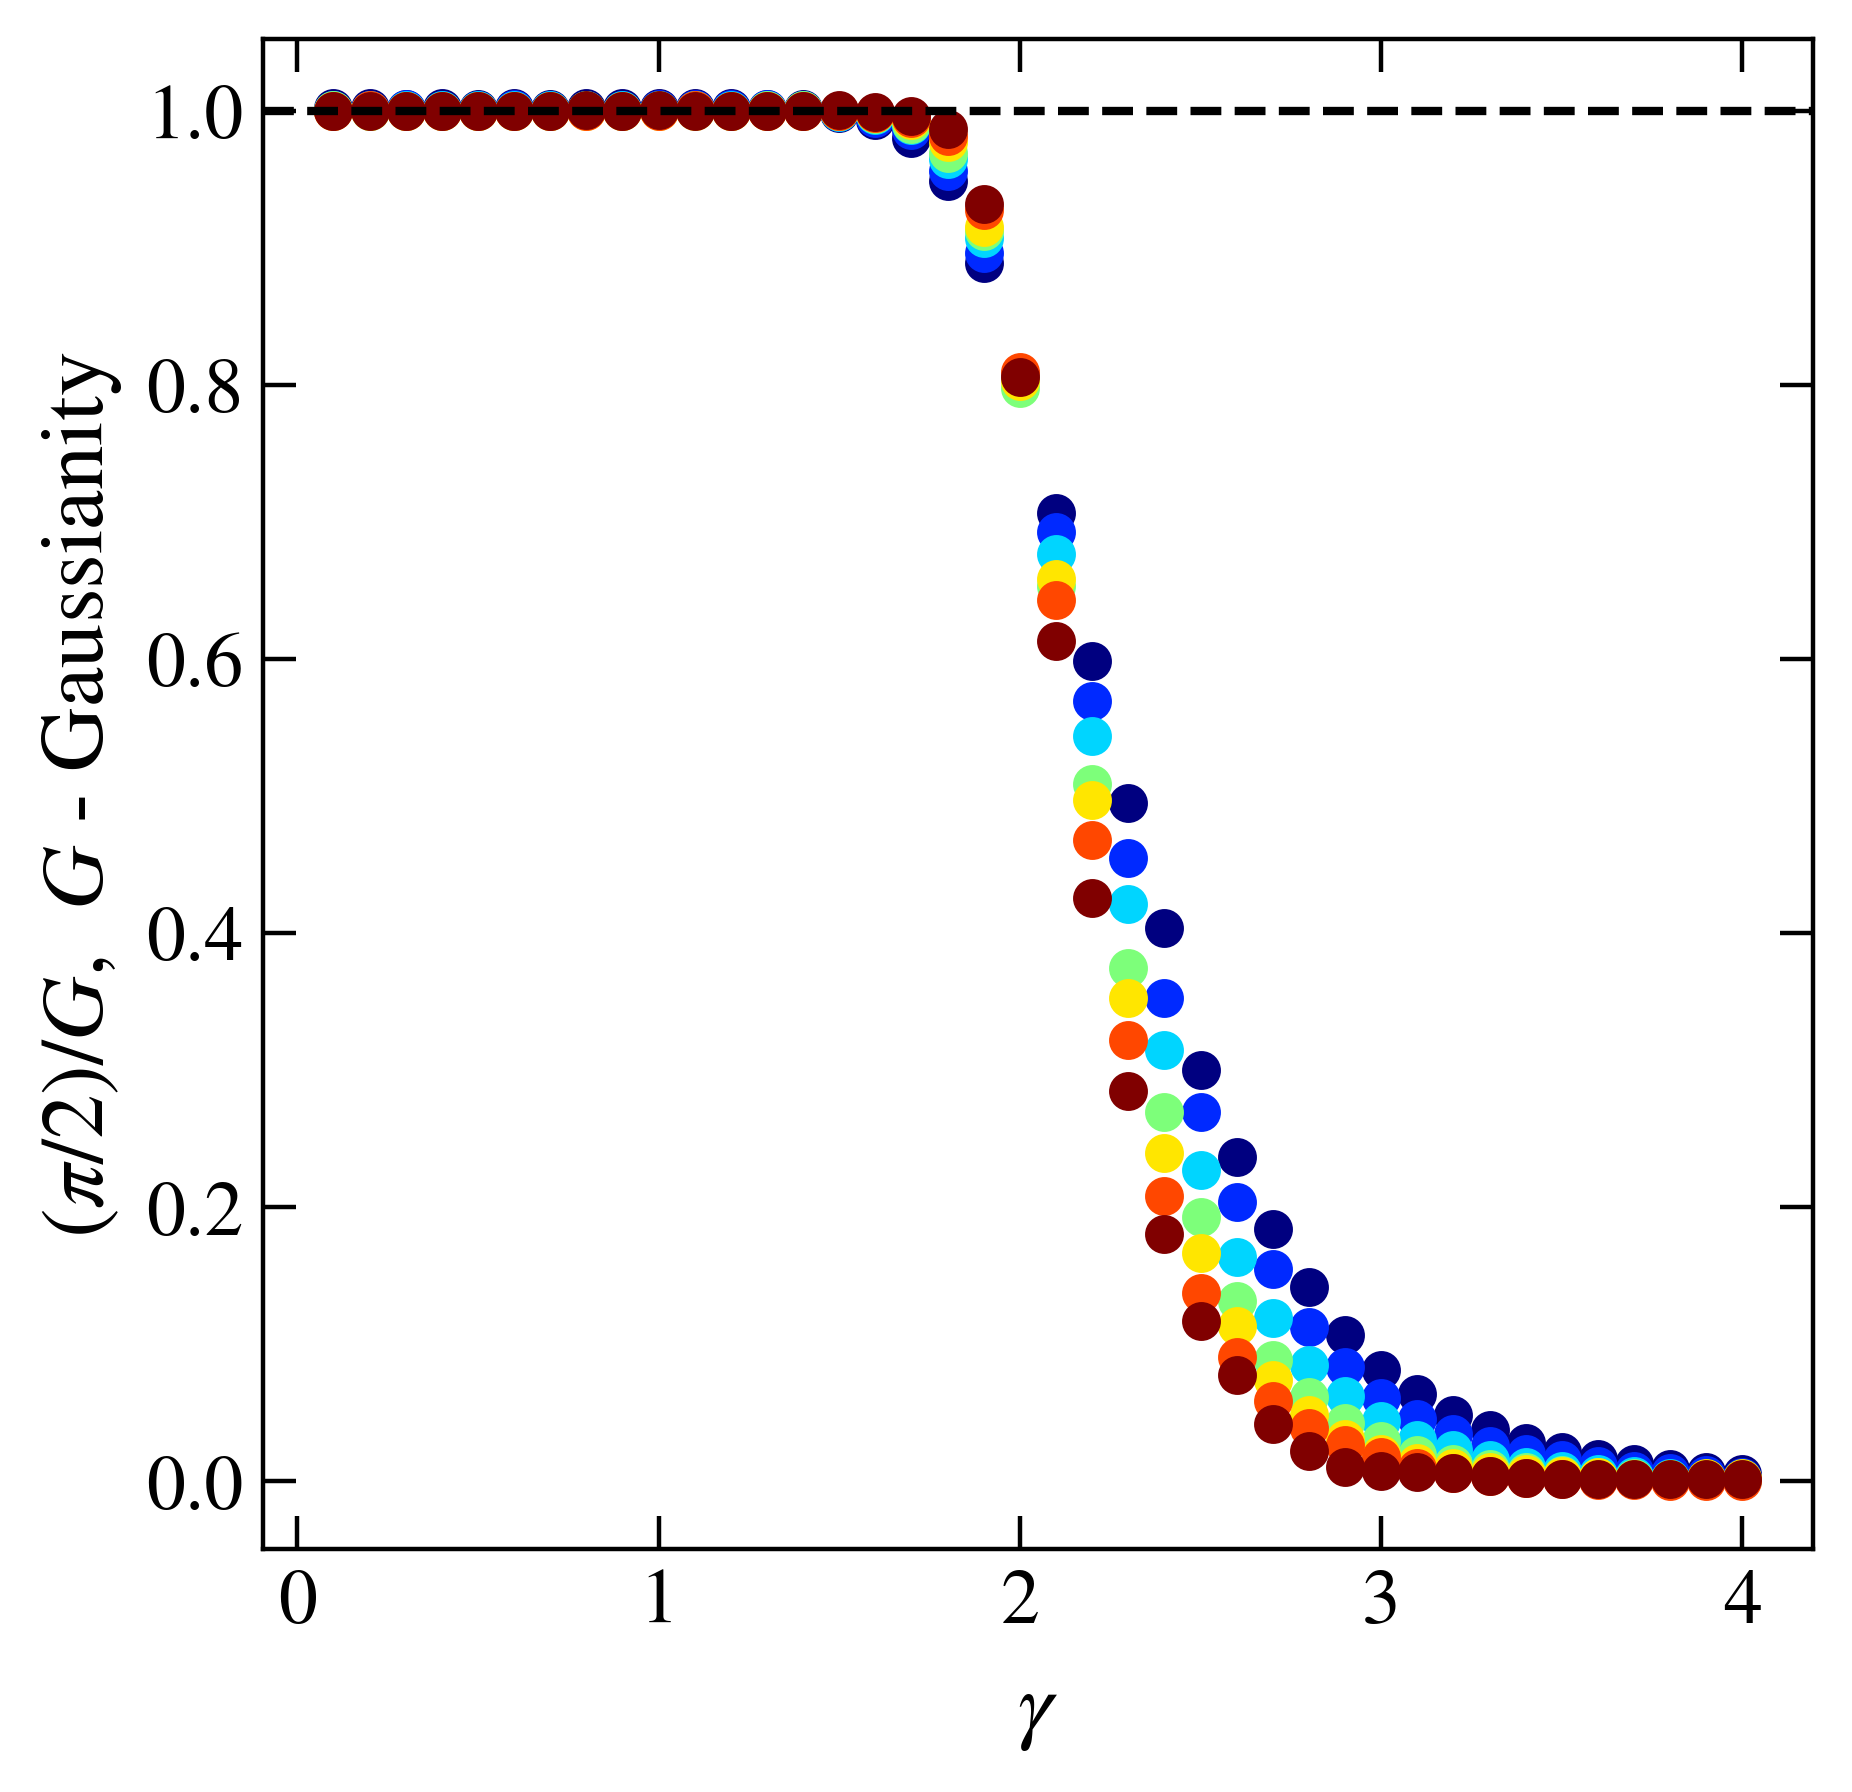

In [173]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 12
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(8, 15, 1)

DIM = 1
gammas = np.arange(0.1, 4.01, 0.1)
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 400, sharex=False, sharey=False)

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes)))
s_m.set_array([])


for L in sizes:
    col = s_m.to_rgba(L)
    gauss = np.zeros(gammas.shape);gauss.fill(np.nan)
    for iig, gx in enumerate(gammas):
        dim = 2**L
        # name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        name_out = prefix + "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                try:
                    gauss[iig] = np.array(file.get('LTVALS/L=%d/gauss'%L))
                except TypeError:
                    aadsada=1
        else:
            print(name_out)
    axis.scatter(gammas, np.pi/2/gauss, color=col)
    # axis.scatter(gammas, np.abs( gauss - np.pi/2 ), color=col)
axis.axhline(y=1, ls='--', color='k')
fig_help.set_plot_elements(axis, ylabel=r"$(\pi/2)/G$,  $G$ - Gaussianity", xlabel=r"$\gamma$", font_size=14, set_legend=0, xscale='linear', yscale='linear')

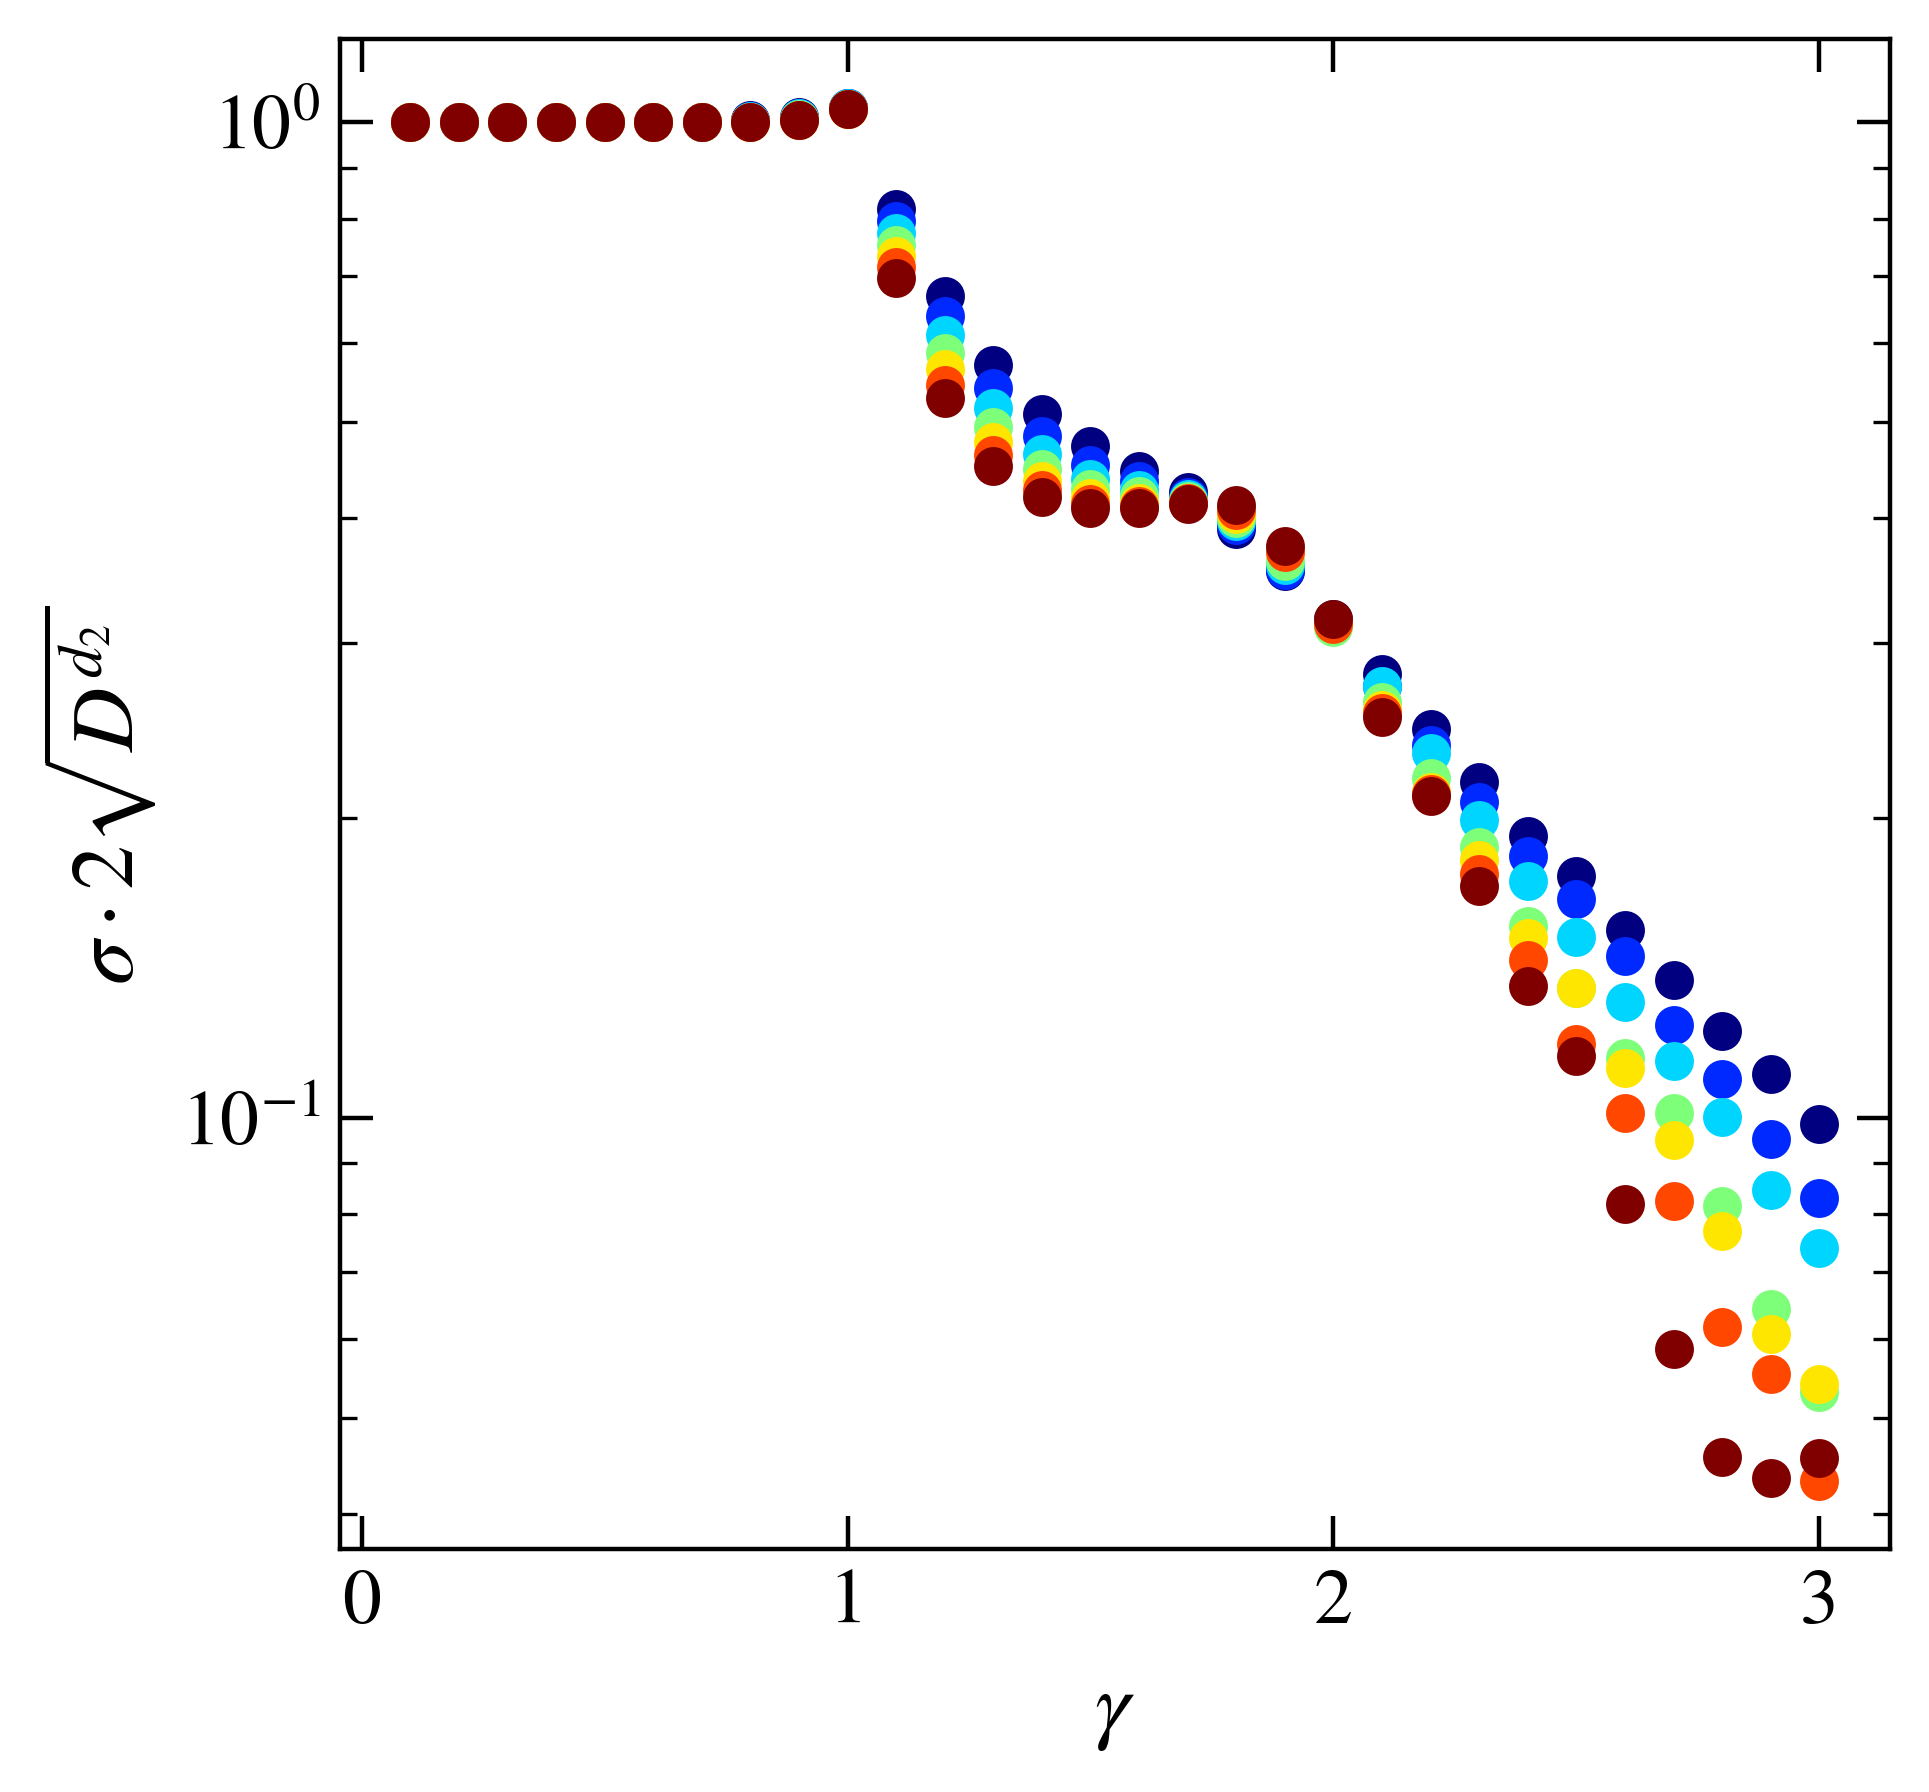

In [1657]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 12
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(2., 2.9, 0.1)

DIM = 1
gammas = np.arange(0.1, 3.1, 0.1)
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 400, sharex=False, sharey=False)

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes)))
s_m.set_array([])


for L in sizes:
    col = s_m.to_rgba(L)
    vari = np.zeros(gammas.shape);gauss.fill(np.nan)
    for iig, gx in enumerate(gammas):
        d2 = 1 if gx <= 1 else 2-gx
        # if gx > 2: d2 = gx-2
        dim = 2**L
        name_out = prefix + "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                try:
                    vari[iig] = np.sqrt(np.array(file.get('LTVALS/L=%d/second_moment'%L)) - np.array(file.get('LTVALS/L=%d/first_moment'%L))**2) * 2 * np.sqrt(1 + dim**d2)
                except TypeError:
                    aadsada=1
        else:
            print(name_out)
    axis.scatter(gammas, vari, color=col)

fig_help.set_plot_elements(axis, ylabel=r"$\sigma\cdot 2\sqrt{D^{d_2}}$", xlabel=r"$\gamma$", font_size=14, set_legend=0, xscale='linear', yscale='log')